# 02. CRM Analytics

**Project:** analysis of the CRM data for an online coding school.
All data was pre-cleaned and prepared in the corresponding notebooks:
* 'calls': 01_data_prepare_calls.ipynb -> 'calls_cleaned.pkl'
* 'deals': 01_data_prepare_deals.ipynb -> 'deals_cleaned.pkl'
* 'contacts': 01_data_prepare_contacts.ipynb -> 'contacts_cleaned.pkl'
* 'spend': 01_data_prepare_spend.ipynb -> 'spend_cleaned.pkl'

## Metric Glossary

All unit-economics metrics in this project use one set of definitions. 

| Metric | Definition | Value (Jul 2023 - May 2024) |
| :--- | :--- | ---: |
| **Clicks** | Paid ad clicks (`spend.clicks`), top of the marketing funnel | 468,577 |
| **UA** | Unique potential clients (`contact_id` in contacts) | 17,250 |
| **Leads** | CRM deals (applications). Used in channel- and manager-level tables, because campaign, source and manager are stored on the deal | 18,250 |
| **B** | Unique paying students: `contact_id` with stage = Payment Done and months_of_study > 0 | 802 |
| **T** | Transactions = total paid months of study of paying students | 4,540 |
| **Rev** | Revenue = sum of `Ri` (accumulated revenue per student) | 3,347,317.73 EUR |
| **AC** | Marketing budget = sum of `spend` | 138,152.50 EUR |
| **C1** | B / UA (portfolio level); B / Leads (channel and manager tables) | 4.65% |
| **CPA** | AC / UA, cost per potential client. CPL = AC / Leads is its channel-level equivalent | 8.01 EUR |
| **CAC** | AC / B, cost per paying student | 172.26 EUR |
| **AOV** | Rev / T, average revenue per paid month | 737.29 EUR |
| **APC** | T / B, paid months per student | 5.66 |
| **CLTV** | AOV x APC = Rev / B. COGS is not available in the data (COGS = 0), so CLTV is revenue-based | 4,173.71 EUR |
| **LTV** | CLTV x C1, value of one potential client | 194.05 EUR |
| **CM** | UA x (LTV - CPA) = Rev - AC (COGS = 0) | 3,209,165.23 EUR |
| **ROMI** | (Rev - AC) / AC | 2,323% |

Reading notes:
* Funnel used in this notebook: **Clicks -> Leads (CRM deals) -> B (unique paying students)**.
* B in group-level tables (campaign, source, manager, product) is the number of unique students inside the group. A client who bought through two groups is counted in both, so group totals can exceed 802 by a few clients.
* Ratios such as LTV / CAC must be built from metrics in the same unit: **CLTV / CAC** (per student) or **LTV / CPA** (per potential client). Both equal 24.2.

---
# 1. Imports & Setup

In [1]:
import os
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns

from datetime import datetime
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.datasets import get_rdataset
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import dash
from dash import dcc, html, callback
from dash.dependencies import Input, Output
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

import helpers as h

In [2]:
# Visualization settings
sns.set_style('whitegrid')
sns.set_palette('deep')

# Pandas settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format) # 

# Paths (notebook lives in notebooks/, data lives in data/)
PROJECT_ROOT = Path().resolve().parent
# RAW          = PROJECT_ROOT / 'data' / 'raw'
PROCESSED    = PROJECT_ROOT / 'data' / 'processed'
# BACKUP       = PROJECT_ROOT / 'data' / 'processed' / 'backup'
IMAGES       = PROJECT_ROOT / 'images'
REPORTS       = PROJECT_ROOT / 'report'

# # Create the backup folder if it doesn't exist yet
# BACKUP.mkdir(parents=True, exist_ok=True)

In [3]:
# Delimiter strings for formatted output:

string_delimiter = f"{'-':-^79}"
print(string_delimiter)
string_delimiter1 = f"{'=':=^79}"
print(string_delimiter1)

-------------------------------------------------------------------------------


---
# 2. Loading Data

In [4]:
# Dictionary of cleaned datasets to load:
datasets = {'deals': 'deals_cleaned.pkl',
            'contacts': 'contacts_cleaned.pkl',
            'calls': 'calls_cleaned.pkl',
            'spend': 'spend_cleaned.pkl'
            }

In [5]:
# Load each dataset by filename:
loaded_data = {}

for name, filename in datasets.items():
    filepath = PROCESSED / filename  
  
    # Determine format from the file extension
    if filepath.suffix == '.pkl':
        df = pd.read_pickle(filepath)
    else:
        raise ValueError(f"Unsupported file format: {filepath.suffix}")
    
    loaded_data[name] = df # for accessing the loaded data
    
    print(f"Loaded: {filename}")
    print(f"{name}: {df.shape}\n")

Loaded: deals_cleaned.pkl
deals: (19817, 27)

Loaded: contacts_cleaned.pkl
contacts: (18548, 5)

Loaded: calls_cleaned.pkl
calls: (92617, 11)

Loaded: spend_cleaned.pkl
spend: (19862, 8)



In [6]:
# Access the loaded datasets
contacts = loaded_data['contacts']
deals = loaded_data['deals']
calls = loaded_data['calls']
spend = loaded_data['spend']

In [7]:
# Type check
print(type(contacts))
print(type(deals))
print(type(calls))
print(type(spend))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [8]:
# Print column names and dtypes for the datasets in use (DEALS & CALLS)
for name, df in {
    'deals': deals,
    'calls': calls,
    'contacts': contacts,
    'spend': spend
}.items():
    print(f"\n{'='*15} {name.upper()} {'='*15}")
    print(df.dtypes)


=============== DEALS ===============
deals_id                string[python]
deal_owner_name                 object
closing_date            datetime64[ns]
quality                       category
stage                         category
lost_reason                   category
page                          category
campaign                        object
sla                    timedelta64[ns]
ad                              object
ad_group                        object
source                          object
payment_type                  category
product                       category
education_type                category
created_time            datetime64[ns]
course_duration                  Int64
months_of_study                  Int64
initial_amount_paid            float64
offer_total_amount             float64
contact_id              string[python]
city                            object
created_date            datetime64[ns]
is_paid                           bool
level_of_deutsch         

### 2.1. Full Technical Audit of All Date/Time Fields

In [9]:
# Technical audit of all date/time fields
def get_date_bounds(df, columns):
    res = {}
    for col in columns:
        if col in df.columns:
            temp_dt = pd.to_datetime(df[col], errors='coerce')
            res[col] = (temp_dt.min(), temp_dt.max())
    return res

audit_data = {
    'CONTACTS': get_date_bounds(contacts, ['created_time', 'created_date', 'modified_time']),
    'CALLS':    get_date_bounds(calls, ['call_start_time', 'call_start_date']),
    'DEALS':    get_date_bounds(deals, ['created_time', 'created_date', 'closing_date']),
    'SPEND':    get_date_bounds(spend, ['spend_date'])
}

print(f"{'Dataset':<12} | {'Field':<18} | {'Start':<12} | {'End':<12}")
print(string_delimiter1)

for ds_name, cols in audit_data.items():
    for col_name, (d_min, d_max) in cols.items():
        print(f"{ds_name:<12} | {col_name:<18} | {str(d_min.date()):<12} | {str(d_max.date()):<12}")
    print(string_delimiter1)

Dataset      | Field              | Start        | End         
CONTACTS     | created_time       | 2023-06-27   | 2024-06-21  
CONTACTS     | created_date       | 2023-06-27   | 2024-06-21  
CONTACTS     | modified_time      | 2023-07-06   | 2024-06-21  
CALLS        | call_start_time    | 2023-06-30   | 2024-06-21  
CALLS        | call_start_date    | 2023-06-30   | 2024-06-21  
DEALS        | created_time       | 2023-07-03   | 2024-06-21  
DEALS        | created_date       | 2023-07-03   | 2024-06-21  
DEALS        | closing_date       | 2023-07-05   | 2024-12-11  
SPEND        | spend_date         | 2023-07-03   | 2024-06-21  


**Synchronizing the time window:**     
I audited the data and found a technical gap for the first 2 days of July 2023, which fall on a weekend in the deals and ad-spend exports. To keep the July financial data representative, I decided to keep July in the analysis, since the resulting lead-volume error is under 1%.

For the end of the reporting period, the last date is 21.06.2024 — this is removed from the analysis because the month is incomplete across all datasets.

DECISION:   
`Selected period`: 2023-07-01 — 2024-05-31

### 2.2. Synchronizing the Time Window

##### Synchronizing the Time Window (FINANCIAL PRIORITY)

In [10]:
# Set the bounds based on Spend and common sense
# SPEND from 2023-07-03 (01-02.07.2023 are weekend days), since this is financial data and banks often process payments only on the first business day after a weekend.
# SYNC_START = pd.Timestamp('2023-06-01')
# SYNC_END   = pd.Timestamp('2024-12-11')
SYNC_START = pd.Timestamp('2023-07-01')
SYNC_END   = pd.Timestamp('2024-05-31')

print(f"DECISION:")
print(f"Selected period: {SYNC_START.date()} — {SYNC_END.date()}")
print(f"Rationale: ")
print("""Bounds set based on Spend, Deals and common sense:
Spend, Deals from 2023-07-03 (01-02.07.2023 are weekend days), since this is financial data and banks often process payments only on the first business day after a weekend.""")
print(string_delimiter1)

# Record sizes before filtering
before_sync = {'Deals': len(deals), 'Calls': len(calls), 'Spend': len(spend), 'Contacts': len(contacts)}

# Apply the filter (using each dataset's main date column)
deals = deals[(deals['created_date'] >= SYNC_START) & (deals['created_date'] <= SYNC_END)].copy()
calls = calls[(calls['call_start_date'] >= SYNC_START) & (calls['call_start_date'] <= SYNC_END)].copy()
spend = spend[(spend['spend_date'] >= SYNC_START) & (spend['spend_date'] <= SYNC_END)].copy()
contacts = contacts[(contacts['created_time'] >= SYNC_START) & (contacts['created_time'] <= SYNC_END)].copy()

DECISION:
Selected period: 2023-07-01 — 2024-05-31
Rationale: 
Bounds set based on Spend, Deals and common sense:
Spend, Deals from 2023-07-03 (01-02.07.2023 are weekend days), since this is financial data and banks often process payments only on the first business day after a weekend.


#### Sync Result

In [11]:
# Report
print(f"{'Dataset':<12} | {'Before':<8} | {'After':<8} | {'Removed':<8} | {'% kept'}")
for name, df_new in {'Deals': deals, 'Calls': calls, 'Spend': spend, 'Contacts': contacts}.items():
    b = before_sync[name]
    a = len(df_new)
    print(f"{name:<12} | {b:<8} | {a:<8} | {b-a:<8} | {(a/b*100):.1f}%")

Dataset      | Before   | After    | Removed  | % kept
Deals        | 19817    | 18250    | 1567     | 92.1%
Calls        | 92617    | 84561    | 8056     | 91.3%
Spend        | 19862    | 18452    | 1410     | 92.9%
Contacts     | 18548    | 17250    | 1298     | 93.0%


### 2.3 Data Preprocessing Block

In [12]:
# 1. Convert dates to datetime
deals['created_date'] = pd.to_datetime(deals['created_date'], errors='coerce')
deals['closing_date'] = pd.to_datetime(deals['closing_date'], errors='coerce')

# 2. Calculate deal duration in days
# Done here so this column is available for every following section
deals['deal_duration_days'] = (deals['closing_date'] - deals['created_date']).dt.total_seconds() / (24 * 3600)

# Base counters (core variables)
calls_count = len(calls['calls_id']) # number of calls
deals_count = len(deals['deals_id']) # number of deals
contacts_count = len(contacts['contact_id']) # number of contacts

# Derived metrics
activity_ratio = deals_count / calls_count if calls_count > 0 else 0

# payment flag: deal reached the 'payment done' status in the system
deals['is_paid'] = deals['stage'] == 'Payment Done'

# payment flag [target]: successful deal with confirmed study = student 
is_real_student = (deals['is_paid'] == 1) & (deals['months_of_study'] > 0)

# (T) Transactions = total paid months of study (Payment Done + Study > 0) 
T = deals[(
    deals['is_paid'] == 1) & (deals['months_of_study'] > 0)
    ]['months_of_study'].sum()

# (B) Unique paying students (Payment Done + Study > 0)

B = deals.loc[deals['is_real_student'] == True, 'contact_id'].nunique()
# Lead-to-student conversion on a deal basis (B / deals); portfolio C1 = B / UA is printed in the next cell

conv_leed = (B / deals_count) * 100 

# 3. Basic error filtering (duration cannot be negative)
# Replace any such cases with NaN so they don't distort the average
deals.loc[deals['deal_duration_days'] < 0, 'deal_duration_days'] = np.nan

In [13]:
calls['contact_id'].nunique()

14189

In [14]:
print(f"Unique clients UA from 'contacts' dataset: {contacts['contact_id'].nunique():_}")
print(f"Unique clients UA from 'calls' dataset: {calls['contact_id'].nunique():_}")
print(f"Unique clients UA from 'deals' dataset: {deals['contact_id'].nunique():_}")
print(f"Total marketing spend AC from 'spend' dataset: {spend['spend'].sum():_.2f}")


print(string_delimiter)
UA = max(contacts['contact_id'].nunique(), calls['contact_id'].nunique(), deals['contact_id'].nunique())
AC = spend['spend'].sum()

print(string_delimiter1)
print(f"Unique clients UA: {UA:_}")
print(f"Marketing budget AC: {AC:2f}")

print(string_delimiter)
print(f"1. Total calls: {calls_count:_}")
print(f"2. Total deals (Lead): {deals_count:_}")
print(f"3. Activity ratio (Deals/Calls): {activity_ratio:.1%}\n")
print(f"4. Deals in 'Payment Done' status (is_paid): {len(deals[deals['is_paid'] == 1]):_}")
print(f"5. (T) Transactions = paid months of study: {T:_}")
print(f"6. (B) Unique paying students (Payment Done + Study > 0): {B:_}")
print(f"7. Lead-to-student conversion on deals (B / deals): {conv_leed:.2f}%")
print(f"8. Portfolio C1 = B / UA: {B / UA * 100:.2f}%")

Unique clients UA from 'contacts' dataset: 17_250
Unique clients UA from 'calls' dataset: 14_189
Unique clients UA from 'deals' dataset: 15_891
Total marketing spend AC from 'spend' dataset: 138_152.50
-------------------------------------------------------------------------------
Unique clients UA: 17_250
Marketing budget AC: 138152.500000
-------------------------------------------------------------------------------
1. Total calls: 84_561
2. Total deals (Lead): 18_250
3. Activity ratio (Deals/Calls): 21.6%

4. Deals in 'Payment Done' status (is_paid): 832
5. (T) Transactions = paid months of study: 4_540
6. (B) Unique paying students (Payment Done + Study > 0): 802
7. Lead-to-student conversion on deals (B / deals): 4.39%
8. Portfolio C1 = B / UA: 4.65%


In [15]:
# # PREPARING DEALS
# # 1. Apply the Ri calculation (overwrite the column to avoid duplicates)
# deals['Ri'] = df.apply(calculate_revenue_ri, axis=1)
# # spend_fixed = h.clean_marketing_hierarchy(spend, "SPEND_FINAL")

# # 2. Build a clean slice using the criteria below: 
# IMPORTANT: for monthly dynamics and to only count complete months
actual_sales_clean_deals = deals[
    (deals['created_date'] >= SYNC_START ) & 
    (deals['created_date'] <= SYNC_END ) & 
    (deals['is_real_student'] == True)
].copy()

# # 3. Sanity check before aggregation
# total_ri_check = actual_sales_clean['Ri'].sum()
# total_count_check = len(actual_sales_clean_deals)

# print(f"Clean revenue Ri: {total_ri_check:_.2f} €")
# print(f"Number of deals: {total_count_check:_}")
# actual_sales_clean

In [16]:
# Save the updated dataset to xlsx
sufix = 'real_student'

dataset_path = PROCESSED / f"deals_{sufix}.xlsx"

# # If the file already exists - back it up before overwriting
# if dataset_path.exists():
#     timestamp = datetime.now().strftime('%Y%m%d_%H%M')
#     backup_path = BACKUP / f"{dataset_config['name']}_{sufix}_{timestamp}.xlsx"
#     dataset_path.rename(backup_path)
#     print(f"Previous file -> backed up as: {backup_path.name}")

# Save the cleaned dataset
actual_sales_clean_deals.to_excel(dataset_path, index=False)
print(f"Dataset saved:  {dataset_path.relative_to(PROJECT_ROOT)}")
print(f"Size:            {actual_sales_clean_deals.shape[0]:_} rows × {actual_sales_clean_deals.shape[1]} columns")

Dataset saved:  data\processed\deals_real_student.xlsx
Size:            814 rows × 28 columns


### Data Preprocessing

In [17]:
# # --- PREPROCESSING FOR UNIT ECONOMICS ---

# # 1. Set the successful-student flag (base filter)
# deals['is_real_student'] = ((deals['is_paid'] == 1) & (deals['months_of_study'] > 0)).fillna(False).astype(bool)

# # 2. Calculate accumulated revenue (Ri)
# # (Using the AOVi, Ri function)
# def apply_ri(row):
#     if not row['is_real_student']: return 0
#     Total = row['offer_total_amount'] if pd.notna(row['offer_total_amount']) else 0
#     Initial = row['initial_amount_paid'] if pd.notna(row['initial_amount_paid']) else 0
#     StudyMonths = row['months_of_study'] if pd.notna(row['months_of_study']) else 0
#     FullDuration = row['course_duration'] if pd.notna(row['course_duration']) else 1
    
#     try:
#         if (Total - Initial) > 0:
#             denominator = (FullDuration - 1) if FullDuration > 1 else 1
#             aov_i = ((StudyMonths - 1) * (Total - Initial) / denominator + Initial) / StudyMonths
#         else:
#             aov_i = Total / FullDuration if FullDuration > 0 else Total
#         return aov_i * StudyMonths
#     except:
#         return 0

# deals['Ri'] = deals.apply(apply_ri, axis=1)

# # 3. Calculate the honest monthly ticket (AOVi)
# deals['AOVi'] = 0.0
# mask = deals['months_of_study'] > 0
# deals.loc[mask, 'AOVi'] = deals.loc[mask, 'Ri'] / deals.loc[mask, 'months_of_study']

# # 4. Final name cleanup (avoid duplicate 'UX/UI' and 'UX/UI ')
# deals['product'] = deals['product'].str.strip()
# deals['education_type'] = deals['education_type'].str.strip().fillna('Unknown')

# print("Ri and AOVi integrated at input. Notebook ready for analysis.")

### 2.4 Function for Saving Plots (Matplotlib/Seaborn)

In [18]:
# Function for saving plots (Matplotlib/Seaborn)
def save_plot(filename, col_name, save_list):
    if col_name in save_list:
        plt.savefig(IMAGES / f"02_{filename}_{col_name}.png", dpi=150, bbox_inches='tight')

---
# 3. Time Series Analysis

Tasks:   
`Time series analysis:`
1. Analyze the trend in deal creation over time and its relationship with calls.   
2. Study the distribution of deal-closing time and the duration from deal creation to closing.

## 3.1 Trend in Deal Creation Over Time and Its Relationship with Calls

Analyze the trend in deal creation over time and its relationship with calls.

### 3.1.1 Time Series (D - Days, W - Week, ME - Months)

##### Helper function plot_time_series_decomposition

In [19]:
def plot_time_series_decomposition(
    df,
    date_col,
    value_col,    
    freq = 'D',   # D - Days, W - Week, ME - Months
    periods = 30, # D = 30, W = 7, ME = 12
    title_prefix = ''
):
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    
    # Prepare the time series and print the time bounds
    ind_ = df.set_index(date_col)
    
    # Print the dataframe's time bounds
    ind_min = df[date_col].min()
    ind_max = df[date_col].max()

    # Aggregate over time
    ts = (
        ind_.resample(freq)
        .agg({value_col: 'count'})
        .rename(columns={value_col:'count'})
        )  
    print(f"Size {title_prefix}: {len(df)}, Period: {ind_min} - {ind_max}")
    print(f"Time series shape: {ts.shape}")
    # display(ts.head())

    # Time series decomposition
    decomposition_add = seasonal_decompose(
        ts['count'],
        model='additive',
        period=periods
        )

    trend_add = decomposition_add.trend
    seasonal_add = decomposition_add.seasonal
    residual_add = decomposition_add.resid

    # Plotting
    plt.figure(figsize=(12, 8))
    
    plt.subplot(411)
    plt.plot(ts['count'], label='Original',linewidth=0.7, alpha=0.8)
    plt.title(f"{title_prefix} |  freq = {freq}", fontsize=14)
    plt.legend(loc='best')
    plt.grid(alpha=0.2)
    
    plt.subplot(412)
    plt.plot(trend_add, label='Trend (Additive)',linewidth=0.7, alpha=0.8)
    plt.legend(loc='best')
    plt.grid(alpha=0.2)
    
    plt.subplot(413)
    plt.plot(seasonal_add, label='Seasonality (Additive)',linewidth=0.7, alpha=0.8)
    plt.ylabel(f"{title_prefix}_count")
    plt.legend(loc='best')
    plt.grid(alpha=0.2)
    
    plt.subplot(414)
    plt.plot(residual_add, label='Residuals (Additive)',linewidth=0.7, alpha=0.8)
    plt.legend(loc='best')
    plt.xlabel(f'Date: {date_col}')
    plt.grid(alpha=0.2)
    
    plt.tight_layout()
    plt.show()

    return ts

#### D - Days / Deal Creation Trend

##### D - Days / Deal Creation Trend (Deals)

Size Deals: 18250, Period: 2023-07-03 20:17:00 - 2024-05-31 23:50:00
Time series shape: (334, 1)


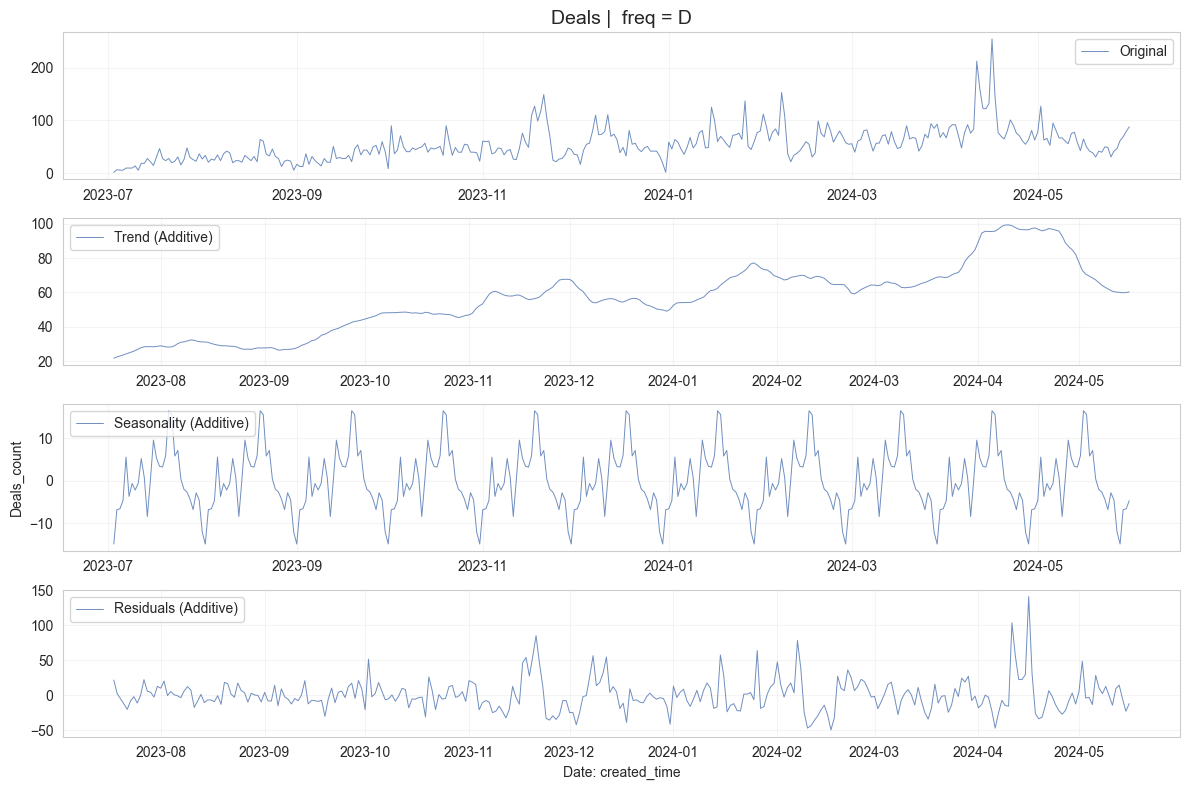

created_time,2023-07-03,2023-07-04,2023-07-05,2023-07-06,2023-07-07,2023-07-08,2023-07-09,2023-07-10,2023-07-11,2023-07-12,2023-07-13,2023-07-14,2023-07-15,2023-07-16,2023-07-17
count,2,7,6,6,10,10,10,14,6,19,19,28,22,15,31


In [20]:
# Deals / Days
plot_time_series_decomposition(
    deals,
    value_col = 'deals_id',
    date_col = 'created_time',
    freq = "D",   # D - Days, W - Week, ME - Months
    periods = 30, # D = 30, W = 7, ME = 12
    title_prefix = 'Deals'
).head(15).T    

`Notes:`   
Seasonality is visible.  
Upward trend.   
High variance in the noise on the chart.

##### D - Days / Deal Creation Trend (Calls)

Size Calls: 84561, Period: 2023-07-03 13:06:00 - 2024-05-31 20:52:00
Time series shape: (334, 1)


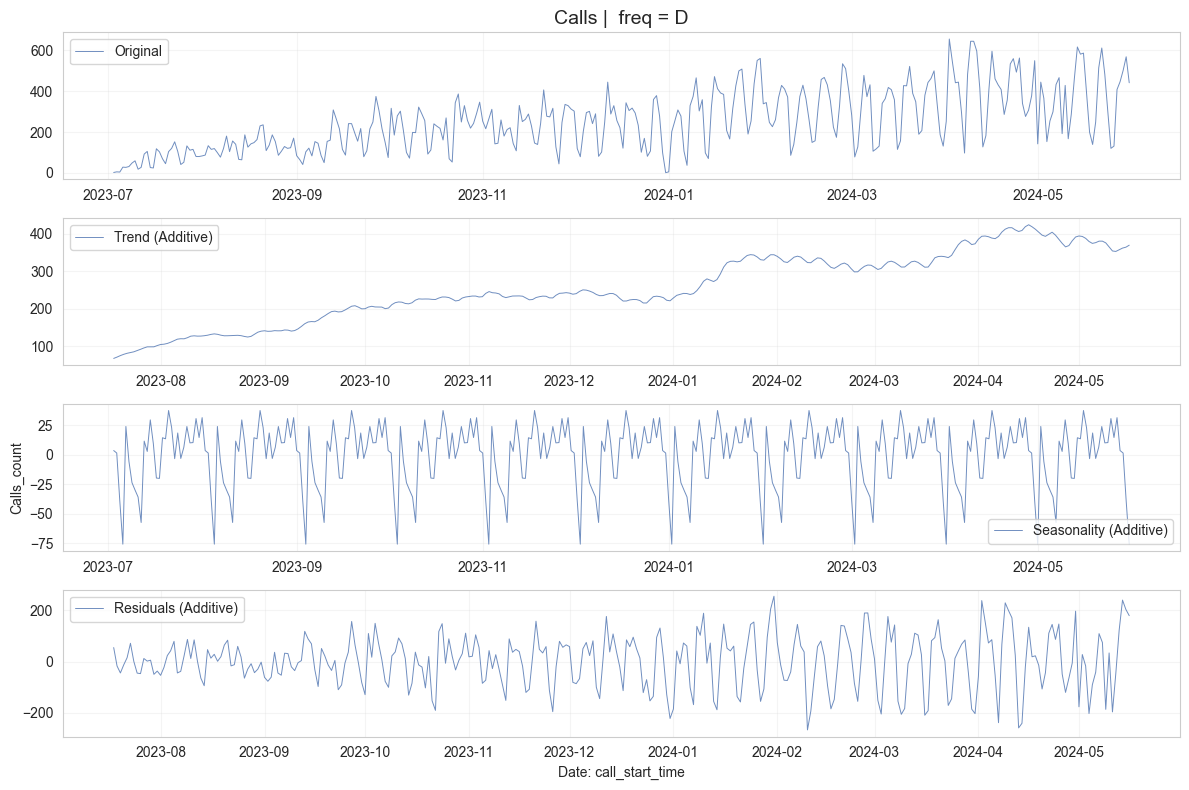

call_start_time,2023-07-03,2023-07-04,2023-07-05,2023-07-06,2023-07-07,2023-07-08,2023-07-09,2023-07-10,2023-07-11,2023-07-12,2023-07-13,2023-07-14,2023-07-15,2023-07-16,2023-07-17
count,2,5,4,28,27,31,48,59,18,27,92,105,26,24,118


In [21]:
# Calls / Months
plot_time_series_decomposition(
    calls,
    value_col = 'calls_id',
    date_col = 'call_start_time',
    freq = "D",   # D - Days, W - Week, ME - Months
    periods = 30, # D = 30, W = 7, ME = 12
    title_prefix = 'Calls'
).head(15).T

`Notes:`   
Seasonality is visible.  
Upward trend.   
Similarly high variance in the noise, with an even wider spread.

#### W - Week / Deal Creation Trend (Deals vs Calls)

In [22]:
# 1. Group deals and calls by date (weekly, 'W')
deals_week = deals.resample('W', on='created_date')['deals_id'].count().reset_index()
calls_week = calls.resample('W', on='call_start_date')['calls_id'].count().reset_index()

# 2. Merge into one dataframe for correlation analysis
df_trends = pd.merge(deals_week, calls_week, 
                     left_on='created_date', right_on='call_start_date', 
                     how='inner').drop(columns=['call_start_date'])
df_trends.columns = ['date', 'deals_count', 'calls_count']

# 3. SECTION VARIABLES
corr_val = df_trends['deals_count'].corr(df_trends['calls_count'])
avg_deals_week = df_trends['deals_count'].mean()
avg_calls_week = df_trends['calls_count'].mean()

print(f"Average deals per week: {avg_deals_week:.1f}")
print(f"Average calls per week: {avg_calls_week:.1f}")
print(f"Correlation coefficient: {corr_val:.2f}")

Average deals per week: 380.2
Average calls per week: 1761.7
Correlation coefficient: 0.82


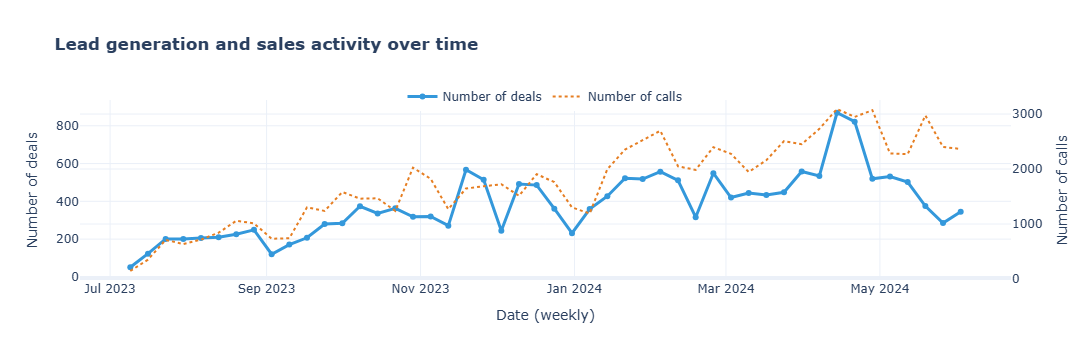

In [23]:
fig_trends = go.Figure()

# Deals line
fig_trends.add_trace(go.Scatter(
    x=df_trends['date'], y=df_trends['deals_count'],
    name="Number of deals", mode='lines+markers', line=dict(color='#3498db', width=3)
))

# Calls line (on the second axis)
fig_trends.add_trace(go.Scatter(
    x=df_trends['date'], y=df_trends['calls_count'],
    name="Number of calls", mode='lines', line=dict(color='#e67e22', width=2, dash='dot'),
    yaxis="y2"
))

fig_trends.update_layout(
    title='<b>Lead generation and sales activity over time</b>',
    xaxis_title="Date (weekly)",
    yaxis_title="Number of deals",
    yaxis2=dict(title="Number of calls", overlaying="y", side="right"),
    template='plotly_white',
    legend=dict(orientation="h", y=1.1, x=0.5, xanchor='center')
)

fig_trends.show()

#### M - Months / Deal Creation Trend (Deals vs Calls)

In [24]:
# 1. Aggregate deals by month, Deals vs Calls
deals_monthly = deals.resample('MS', on='created_date').size().reset_index(name='deals_count')
deals_monthly['month'] = deals_monthly['created_date'].dt.to_period('M').astype(str)

# 2. Aggregate calls by month
# Using call_start_date since it's already in datetime format (dtypes)
calls_monthly = calls.resample('MS', on='call_start_date').size().reset_index(name='calls_count')
calls_monthly['month'] = calls_monthly['call_start_date'].dt.to_period('M').astype(str)

# 3. Merge data for the chart
df_dash = pd.merge(deals_monthly[['month', 'deals_count']], 
                calls_monthly[['month', 'calls_count']], 
                on='month', how='outer').fillna(0).sort_values('month')

# 4. Calculate the activity ratio
df_dash['activity_ratio'] = df_dash['calls_count'] / df_dash['deals_count']

# Deals vs Calls. Merged time series
display(df_dash.T)

,0,1,2,3,4,5,6,7,8,9,10
month,2023-07,2023-08,2023-09,2023-10,2023-11,2023-12,2024-01,2024-02,2024-03,2024-04,2024-05
deals_count,612,931,976,1462,1766,1658,2043,1979,2041,2888,1894
calls_count,1923,4090,4978,6903,7009,6983,9609,9374,9556,12767,11369
activity_ratio,3.14,4.39,5.10,4.72,3.97,4.21,4.70,4.74,4.68,4.42,6.00


***

### 3.1.2 Visualization: M - Months / Sales Cycle (Static & Interactive)

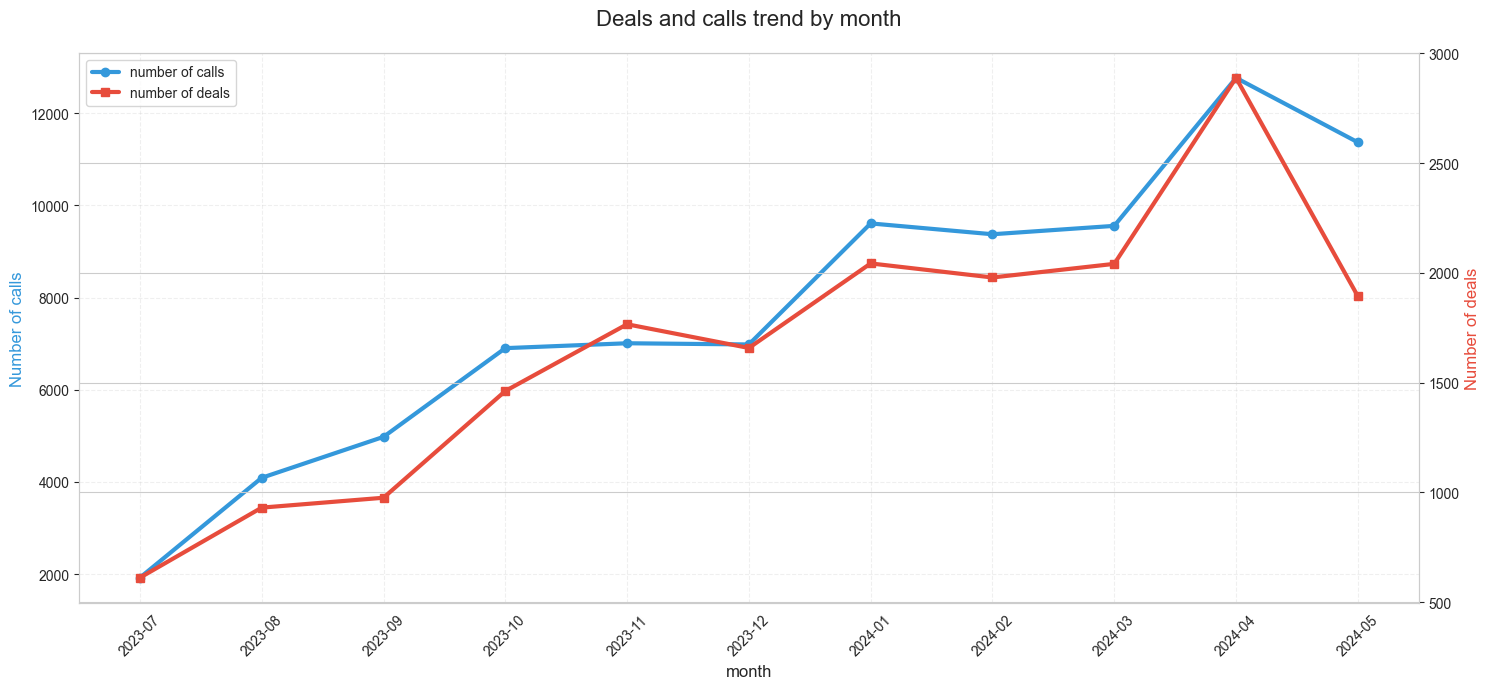

In [25]:
# Activity and efficiency trend analysis 

# 2. Visualization
fig, ax1 = plt.subplots(figsize=(15, 7))

# Calls line (left)
l1 = ax1.plot(df_dash['month'], df_dash['calls_count'], marker='o', color='#3498db', linewidth=3, label='number of calls')
ax1.set_ylabel('Number of calls', fontsize=12, color='#3498db')

# Deals line (right)
ax2 = ax1.twinx()
l2 = ax2.plot(df_dash['month'], df_dash['deals_count'], marker='s', color='#e74c3c', linewidth=3, label='number of deals')
ax2.set_ylabel('Number of deals', fontsize=12, color='#e74c3c')

# Merge legends into one
lns = l1 + l2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper left', frameon=True)

# Styling
plt.title('Deals and calls trend by month', fontsize=16, pad=20)
ax1.set_xlabel('month', fontsize=12)
ax1.set_xticks(range(len(df_dash['month'])))
ax1.set_xticklabels(df_dash['month'], rotation=45)
ax1.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
# === Analytical conclusion ===
# Find peak values
peak_deals_row = df_dash.loc[df_dash['deals_count'].idxmax()]
peak_month = peak_deals_row['month']
peak_deals_val = int(peak_deals_row['deals_count'])
peak_ratio = peak_deals_row['activity_ratio']

print(string_delimiter1)
print("Efficiency analysis report")
print(string_delimiter1)

correlation = df_dash['deals_count'].corr(df_dash['calls_count'])
avg_ratio = df_dash['activity_ratio'].mean()
last_month = df_dash.iloc[-1]
prev_month = df_dash.iloc[-2]

print(f"• Peak period: {peak_month} ({peak_deals_val} deals).")
print(f"• Peak intensity: {peak_ratio:.1f} calls per deal (average: {avg_ratio:.1f}).")
print(f"• Correlation between calls and deals: {correlation:.2f}")

if correlation > 0.8:
    print("   • CONCLUSION: Direct dependency. Call volume growth is strongly tied to deal volume.")
elif correlation > 0.5:
    print("   • CONCLUSION: Moderate dependency. There is some processing lag or nonlinear load.")
else:
    print("   • CONCLUSION: Weak dependency. The relationship between deal closures in the current period is not clearly pronounced.")

print(f"• Latest month's trend ({last_month['month']}):")
print(f"  - deal growth rate: {(last_month['deals_count']/prev_month['deals_count'] - 1)*100:.1f}%")
print(f"  - current load: {last_month['calls_count']/last_month['deals_count']:.1f} calls per deal")
print(string_delimiter1)

Efficiency analysis report
• Peak period: 2024-04 (2888 deals).
• Peak intensity: 4.4 calls per deal (average: 4.6).
• Correlation between calls and deals: 0.95
   • CONCLUSION: Direct dependency. Call volume growth is strongly tied to deal volume.
• Latest month's trend (2024-05):
  - deal growth rate: -34.4%
  - current load: 6.0 calls per deal


#### Correlation

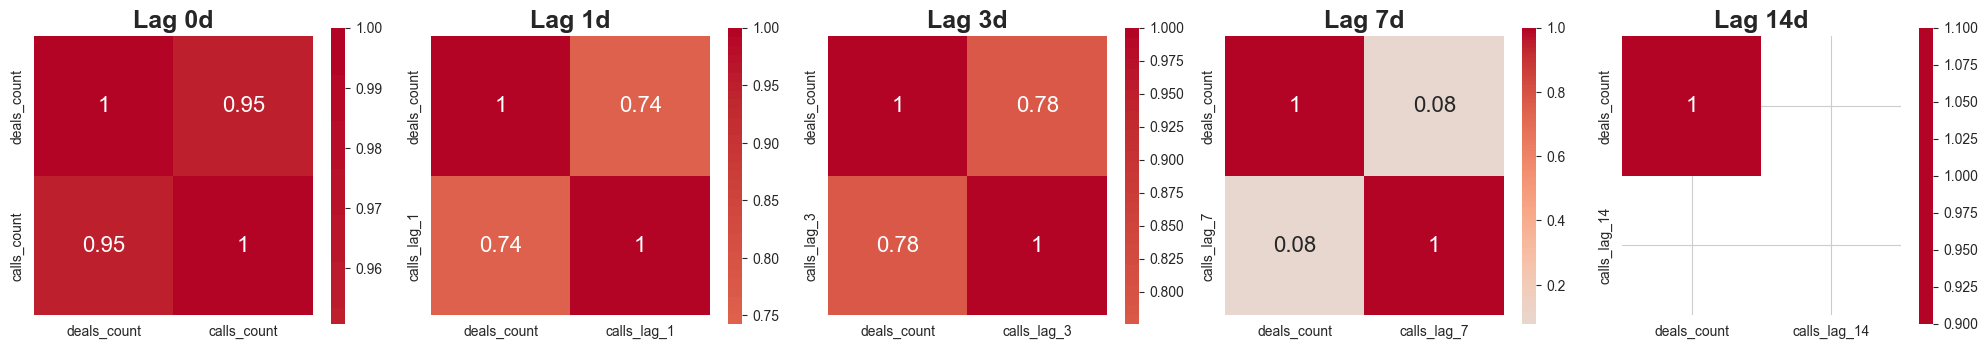

In [27]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, lag in enumerate([0, 1, 3, 7, 14]):
    df_lag = df_dash.copy()
    lag_col = f'calls_lag_{lag}' if lag else 'calls_count'
    if lag:
        df_lag[lag_col] = df_lag['calls_count'].shift(lag)
    
    corr = df_lag[['deals_count', lag_col]].corr()
    sns.heatmap(corr, annot=True, annot_kws={'size': 16}, cmap='coolwarm', center=0, 
                square=True, ax=axes[i], cbar_kws={'shrink': 0.8})
    axes[i].set_title(f'Lag {lag}d', fontweight='bold', fontsize=18)
plt.tight_layout()
plt.show()

In [28]:
#  denoised (smoothed)
df_dash['deals_mooth'] = df_dash['deals_count'].rolling(7).mean()
df_dash['calls_mooth'] = df_dash['calls_count'].rolling(7).mean()

for lag in [1, 3, 5]:
    corr = df_dash['deals_mooth'].corr(df_dash['calls_mooth'].shift(lag))
    print(f'smoothed lag {lag}: {corr:.3f}')

smoothed lag 1: 0.961
smoothed lag 3: 1.000
smoothed lag 5: nan


### 3.1.3 Analytical Conclusion
Reporting period: `2023-07-01 - 2024-05-31`

The datasets originally covered different date ranges, so I first identified the common period with complete monthly data. This avoids trend distortion and misreading of peak activity. Section 3.1 compares the monthly trend of created deals and calls to see how closely marketing and sales activity move together and where gaps appear in the funnel.

**Findings on deal and call trends**

*1. What happened?*   
From July 2023 to April 2024 the number of calls and deals grew in tandem, peaking in April (12,767 calls, 2,888 deals). In May both dropped: 11,369 calls and 1,894 deals (-34% deals versus April).

*2. Why?*   
Calls and deals are tightly linked (correlation 0.95 between monthly calls and deals): more calls go with more deals. The data in this section cannot explain the May drop. Candidates are seasonality, a lower ad budget or lower traffic quality; the first check is monthly ad spend against monthly leads.

*3. What happens if nothing changes?*   
If the May level persists, the pipeline stays about one third smaller than in April, and the number of new students falls roughly in proportion at the same conversion.

*4. What needs to be done?*   
* Identify the cause of the May decline (seasonality, spend, traffic quality)
* Keep call activity at or above the Jan-May 2024 level (9.4-12.8K calls per month)
* Test whether the deals-per-call ratio (21.6% overall) can be raised through faster first contact (see sections 3.2 and 4.2)

## 3.2 Distribution of Deal-Closing Time and Duration from Creation to Closing (Sales Cycle)

Study the distribution of deal-closing time and the duration from deal creation to closing.

### 3.2.1 Sales Cycle (time from creation to closing)

Status 'Payment Done' means the deal was paid.   
'Lost' means the customer declined the purchase.

#### Deals vs Calls. Variables

#### Deal Duration Analysis

In [29]:
# SECTION 3.2: DEAL DURATION ANALYSIS (Static + Interactive)

# Base counters (core variables)
calls_count = len(calls['calls_id'])
deals_count = len(deals['deals_id'])

# Derived metrics
activity_ratio = deals_count / calls_count if calls_count > 0 else 0
corr = df_dash['deals_mooth'].corr(df_dash['calls_mooth'].shift(0))

# Filtering: keep only closed deals (success or loss)
# A deal counts as successful when it's paid AND has months of study, i.e. the customer became a student:
# 'is_paid' == 1 (flag based on 'stage' == 'Payment Done')
deals['is_real_student'] = (deals['is_paid'] == 1) & (deals['months_of_study'] > 0)
# Deals that generated money and enrollment (success)
B = deals.loc[deals['is_real_student'], 'contact_id'].nunique()  # B: unique paying students
conv_leed = (B / deals_count) * 100

# For the analysis we take either successful (studying) or lost deals
# these have a clear, final outcome and aren't still open with an unknown result.
target_stages = ['Payment Done', 'Lost']

# Deals in a final stage (analytical sample)
closed_deals = deals[deals['stage_simplified'].isin(target_stages)].copy()
closed_deals_count = len(closed_deals)

# Calculate duration in days
closed_deals['created_date'] = pd.to_datetime(closed_deals['created_date'], errors='coerce')
closed_deals['closing_date'] = pd.to_datetime(closed_deals['closing_date'], errors='coerce')
closed_deals = closed_deals.dropna(subset=['created_date', 'closing_date']) #

closed_deals['deal_duration_days'] = (closed_deals['closing_date'] - closed_deals['created_date']).dt.total_seconds() / (24 * 3600)
closed_deals = closed_deals[closed_deals['deal_duration_days'] >= 0] # drop negative values

# Duration categories (binning)
bins = [0, 1, 3, 7, 14, 30, 90, 1000]
labels = ['<1 day', '1-3 days', '4-7 days', '1-2 weeks', '2-4 weeks', '1-3 months', '>3 months']
closed_deals['duration_category'] = pd.cut(closed_deals['deal_duration_days'], bins=bins, labels=labels)

# Calculate SLA in hours from the deals' native column (base deals 'sla')
closed_deals['sla_hours'] = closed_deals['sla'].dt.total_seconds() / 3600

# Collect success-rate statistics
duration_stats = closed_deals.groupby('duration_category', observed=True).agg(
    total_deals=('deals_id', 'count'),
    successful_deals=('is_real_student', 'sum') 
).reset_index()

duration_stats['conversion_rate'] = (duration_stats['successful_deals'] / duration_stats['total_deals']) * 100

In [30]:
# 2. Print statistics (in a consistent order)
print(f"--- OVERALL PERIOD STATISTICS ---")
print(string_delimiter)
print(f"1. Total calls: {calls_count:_}")
print(f"2. Total deals (Lead): {deals_count:_}")
print(f"3. Activity ratio (Deals/Calls): {activity_ratio:.1%}")
print(string_delimiter)
print(f"--- SALES FUNNEL ---")
print(f"4. Deals in a final stage (Payment Done / Lost): {closed_deals_count:_}")
print(f"5. Deals in 'Payment Done' status (is_paid): {len(deals[deals['is_paid'] == 1]):_}")
print(f"6. (B) Unique paying students (Payment Done + Study > 0): {B:_}")
print(f"7. Lead-to-student conversion on deals (B / deals): {conv_leed:.2f}%")

print(f"8. Correlation (Calls vs Deals): {corr:.3}")

--- OVERALL PERIOD STATISTICS ---
-------------------------------------------------------------------------------
1. Total calls: 84_561
2. Total deals (Lead): 18_250
3. Activity ratio (Deals/Calls): 21.6%
-------------------------------------------------------------------------------
--- SALES FUNNEL ---
4. Deals in a final stage (Payment Done / Lost): 14_246
5. Deals in 'Payment Done' status (is_paid): 832
6. (B) Unique paying students (Payment Done + Study > 0): 802
7. Lead-to-student conversion on deals (B / deals): 4.39%
8. Correlation (Calls vs Deals): 0.996


In [31]:
duration_stats

,duration_category,total_deals,successful_deals,conversion_rate
0,<1 day,1433,18,1.26
1,1-3 days,1774,34,1.92
2,4-7 days,2354,64,2.72
3,1-2 weeks,1533,83,5.41
4,2-4 weeks,1156,104,9.00
5,1-3 months,1274,127,9.97
6,>3 months,555,49,8.83


In [32]:
# Column summary table 
h.descr_df(duration_stats)

,Column name,Dtype,Value count,Missing (NaN),Unique values,Min,Q1,Mean,Q2 Median,Q3,Max,Range,IQR
0,total_deals,int64,7,0,7,555.00,1215.00,1439.86,1433.00,1653.50,2354.00,1799.00,438.50
1,successful_deals,Int64,7,0,7,18.00,41.50,68.43,64.00,93.50,127.00,109.00,52.00
2,conversion_rate,Float64,7,0,7,1.26,2.32,5.59,5.41,8.91,9.97,8.71,6.60


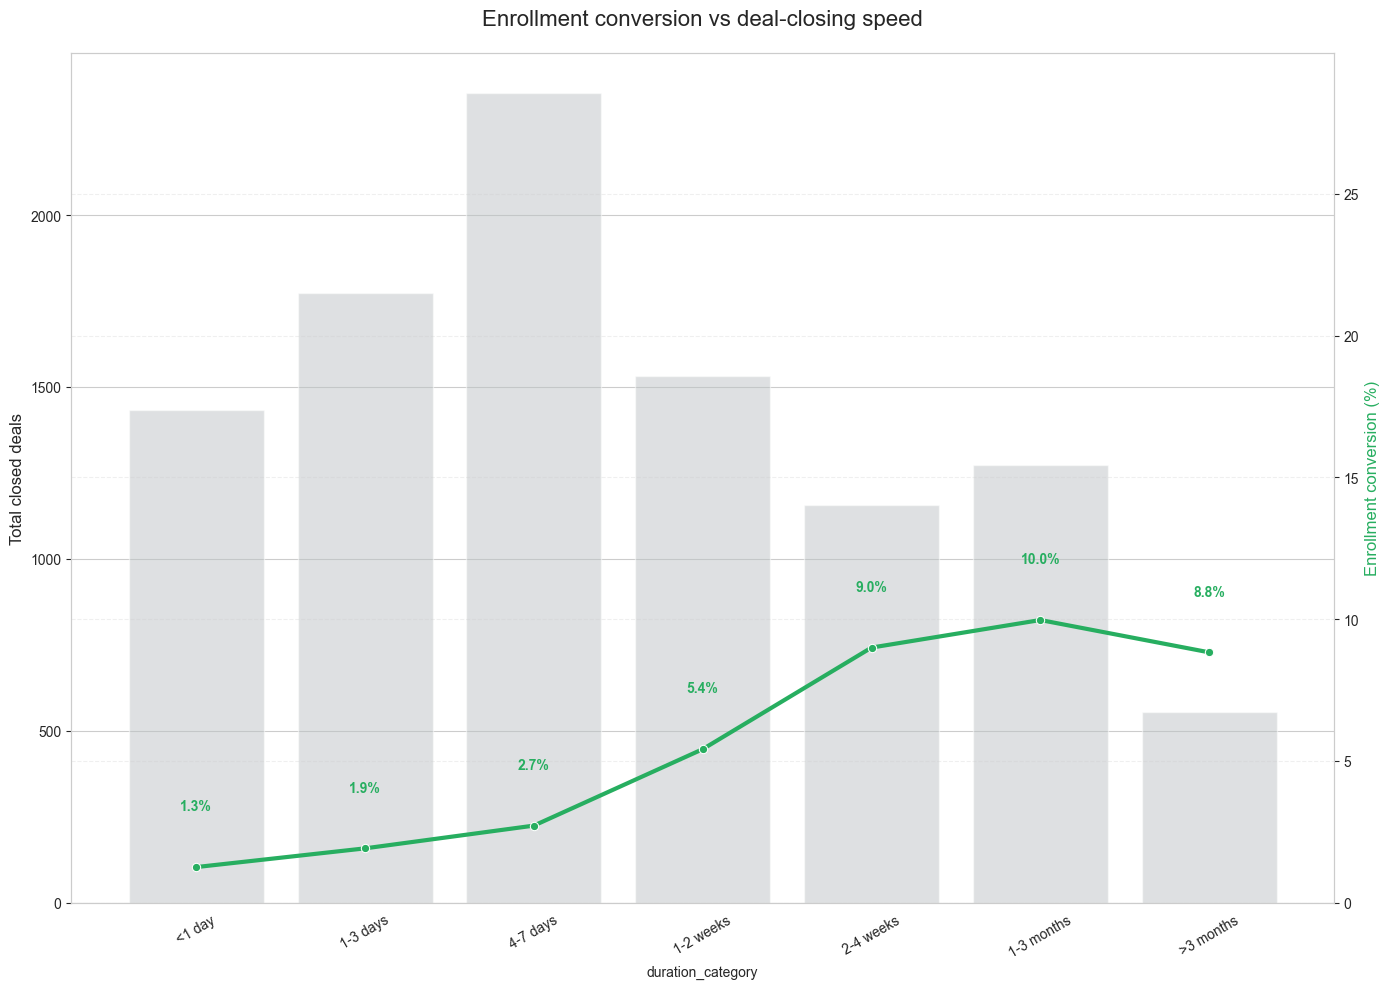

Analytical insights on the deal cycle:
• Median time from application to start of study: 17.5 days.
• 75% of customers start studying within 43.0 days.
• Conclusion: Customers need time to consider and compare other offers. A follow-up touchpoint sequence is needed after the first week.


<Figure size 640x480 with 0 Axes>

In [33]:
# 5. Visualization
fig, ax1 = plt.subplots(figsize=(14, 10))

# Bar chart: total deal volume
sns.barplot(data=duration_stats, x='duration_category', y='total_deals', color='#bdc3c7', alpha=0.5, ax=ax1)
ax1.set_ylabel('Total closed deals', fontsize=12)

# Conversion line
ax2 = ax1.twinx()
sns.lineplot(data=duration_stats, x='duration_category', y='conversion_rate', marker='o', color='#27ae60', linewidth=3, ax=ax2)
ax2.set_ylabel('Enrollment conversion (%)', fontsize=12, color='#27ae60')
ax2.set_ylim(0, duration_stats['conversion_rate'].max() + 20)

# Data labels
for i, val in enumerate(duration_stats['conversion_rate']):
    ax2.text(i, val + 2, f'{val:.1f}%', color='#27ae60', ha='center', fontweight='bold')

plt.title('Enrollment conversion vs deal-closing speed', fontsize=16, pad=20)
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels, rotation=30)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Analytical conclusion
print(string_delimiter1)
print("Analytical insights on the deal cycle:")
print(string_delimiter1)
success_only = closed_deals[closed_deals['is_real_student'] == True]['deal_duration_days']

if not success_only.empty:
    median_time = success_only.median()
    q75_time = success_only.quantile(0.75)
    print(f"• Median time from application to start of study: {median_time:.1f} days.")
    print(f"• 75% of customers start studying within {q75_time:.1f} days.")
    
    if median_time < 7:
        print("• Conclusion: The product has a short decision cycle. Focus should be on the speed of the first call.")
    else:
        print("• Conclusion: Customers need time to consider and compare other offers. A follow-up touchpoint sequence is needed after the first week.")
print(string_delimiter1)

# Save
filename = "02_marketing_ua_duration_stats" # name
config_path = IMAGES / f"{filename}.png"
plt.savefig(config_path, dpi=150, bbox_inches='tight')

In [34]:
# Conversion vs deal-closing speed
def create_conversion_speed_chart(duration_stats):
    # Create a figure with two Y axes
    fig = make_subplots(specs=[[{"secondary_y": True}]])

    # 1. Bar chart (number of deals)
    fig.add_trace(
        go.Bar(
            x=duration_stats['duration_category'],
            y=duration_stats['total_deals'],
            name="Number of deals",
            marker_color='#bdc3c7',
            opacity=0.5
        ),
        secondary_y=False,
    )

    # 2. Line (conversion)
    fig.add_trace(
        go.Scatter(
            x=duration_stats['duration_category'],
            y=duration_stats['conversion_rate'],
            name="Conversion %",
            mode='lines+markers+text',
            text=[f"{val:.1f}%" for val in duration_stats['conversion_rate']],
            textposition="top center",
            line=dict(color='#27ae60', width=4),
            marker=dict(size=10)
        ),
        secondary_y=True,
    )

    # Axis and layout settings
    fig.update_layout(
        title_text='<b>Conversion vs deal-closing speed</b>',        
        title_x=0.5,
        hovermode="x unified",
        plot_bgcolor='white',
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )

    fig.update_yaxes(title_text="Number of deals", secondary_y=False)
    fig.update_yaxes(title_text="Conversion (%)", secondary_y=True, range=[0, 100])

    return fig
# Display
plt.tight_layout()
create_conversion_speed_chart(duration_stats)

# Save
filename = "02_marketing_ua_duration_stats.png" # name
plt.savefig(IMAGES / f"02_{filename}", dpi=150, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

#### Dashboard (Dash + Plotly) / Engineering Block

In [35]:
# Stop-server button, to avoid port-lock issues
def add_stop_button(app):
    from dash import html, Input, Output
    import os

    # add the button to the layout
    app.layout.children.append(html.Button("Stop server", id="__stop"))

    @app.callback(Output("__stop", "children"),
                  Input("__stop", "n_clicks"),
                  prevent_initial_call=True)
    def _stop(_):
        os._exit(0)

In [36]:
# --- PRECOMPUTED VALUES ---
total_calls = df_dash['calls_count'].sum()
total_deals = df_dash['deals_count'].sum()
peak_row = df_dash.loc[df_dash['deals_count'].idxmax()]
start_date = df_dash['month'].min()
end_date = df_dash['month'].max()

# --- 1. FIGURE: TOP CHART (DEALS AND CALLS) ---
fig_activity = go.Figure()

fig_activity.add_trace(go.Scatter(
    x=df_dash['month'], y=df_dash['calls_count'],
    name="Number of calls", mode='lines+markers',
    line=dict(color='#3498db', width=3), yaxis="y1"
))

fig_activity.add_trace(go.Scatter(
    x=df_dash['month'], y=df_dash['deals_count'],
    name="Number of deals", mode='lines+markers',
    line=dict(color='#e74c3c', width=3), yaxis="y2"
))

fig_activity.update_layout(
    template="plotly_white",
    title=f"<b>Sales team activity over time</b><br><span style='font-size:12px; color:gray;'>Monitoring period: {start_date} — {end_date}</span>",
    xaxis=dict(title="Month", tickangle=45, type='category', tickmode='linear'),
    yaxis=dict(title=dict(text="Calls", font=dict(color="#3498db")), tickfont=dict(color="#3498db")),
    yaxis2=dict(title=dict(text="Deals", font=dict(color="#e74c3c")), tickfont=dict(color="#e74c3c"), overlaying="y", side="right"),
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.1, xanchor="right", x=1)
)

# --- 2. INITIALIZE DASH ---
app = dash.Dash(__name__)

# --- 3. LAYOUT (PAGE STRUCTURE) ---
app.layout = html.Div(
    style={'fontFamily': 'Arial, sans-serif', 'padding': '20px', 'maxWidth': '1200px', 'margin': '0 auto'},
    children=[
        # Header
        html.Header(html.H1('CRM Analysis - Online Coding School', style={'textAlign': 'center', 'color': '#2c3e50'})),
        
        # TOP CHART
        dcc.Graph(id='activity-graph', figure=fig_activity),

        # KPI BLOCK (ENHANCED)
        html.Div([
            # Headline numbers
            html.Div([
                html.Div([
                    html.H4("Total calls", style={'color': '#7f8c8d', 'fontSize': '14px'}),
                    html.P(f"{total_calls:,}", style={'fontSize': '22px', 'fontWeight': 'bold', 'color': '#3498db'})
                ], style={'display': 'inline-block', 'width': '25%', 'textAlign': 'center'}),
                
                html.Div([
                    html.H4("Total deals", style={'color': '#7f8c8d', 'fontSize': '14px'}),
                    html.P(f"{total_deals:,}", style={'fontSize': '22px', 'fontWeight': 'bold', 'color': '#e74c3c'})
                ], style={'display': 'inline-block', 'width': '25%', 'textAlign': 'center'}),

                html.Div([
                    html.H4("Correlation", style={'color': '#7f8c8d', 'fontSize': '14px'}),
                    html.P(f"{df_dash['deals_count'].corr(df_dash['calls_count']):.2f}", style={'fontSize': '22px', 'fontWeight': 'bold'})
                ], style={'display': 'inline-block', 'width': '25%', 'textAlign': 'center'}),
                
                html.Div([
                    html.H4("Calls/Deal", style={'color': '#7f8c8d', 'fontSize': '14px'}),
                    html.P(f"{df_dash['activity_ratio'].mean():.1f}", style={'fontSize': '22px', 'fontWeight': 'bold'})
                ], style={'display': 'inline-block', 'width': '25%', 'textAlign': 'center'}),
            ], style={'marginBottom': '15px', 'borderBottom': '1px solid #dee2e6', 'paddingBottom': '15px'}),

            # Small peak-month summary
            html.Div([
                html.P([
                    html.B("Peak month: "), f"{peak_row['month']}",
                    html.Span(f" | Deals: {peak_row['deals_count']}", style={'marginLeft': '15px'}),
                    html.Span(f" | Calls: {peak_row['calls_count']}", style={'marginLeft': '15px'}),
                    # Additional metrics can be added here if present in df_dash:
                    # f" | Payments: {peak_row['payments_count']}" 
                ], style={'textAlign': 'center', 'fontSize': '13px', 'color': '#34495e', 'margin': '0'})
            ])
        ], style={
            'backgroundColor': '#f8f9fa', 'padding': '20px', 'borderRadius': '12px', 
            'marginTop': '10px', 'boxShadow': '0 2px 4px rgba(0,0,0,0.05)'
        }),

        html.Hr(style={'marginTop': '30px', 'marginBottom': '30px', 'border': '0.5px solid #eee'}),

        # BOTTOM CHART (CONVERSION SPEED)
        # html.H3("Deal distribution by closing duration", style={'textAlign': 'center', 'color': '#2c3e50'}),
        dcc.Graph(
            id='conversion-speed-graph',
            figure=create_conversion_speed_chart(duration_stats)
        ),
    ]
)

# Run
add_stop_button(app)
if __name__ == '__main__':
    app.run(debug=False, port=8051)

**http://127.0.0.1:8051/**)  
Open this URL in a web browser to view and interact with the Dash app.

Median response time (SLA): 5.53 h.
Number of 'fast' responses (within 1 hour): 2_345
Share of fast responses: 19.1%


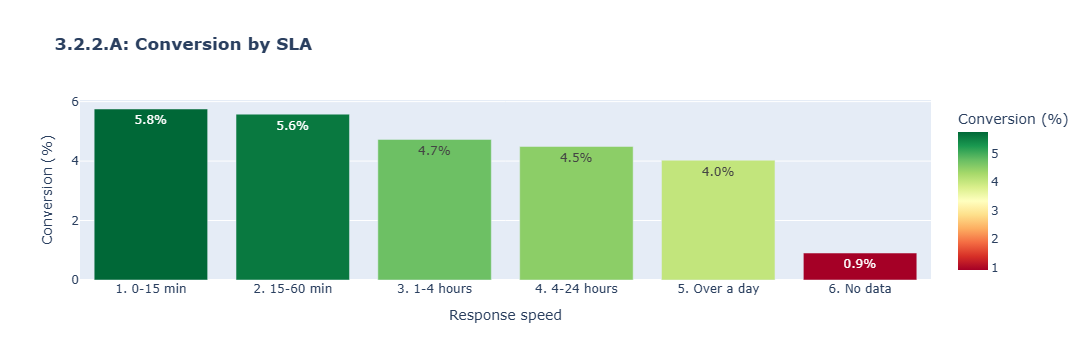

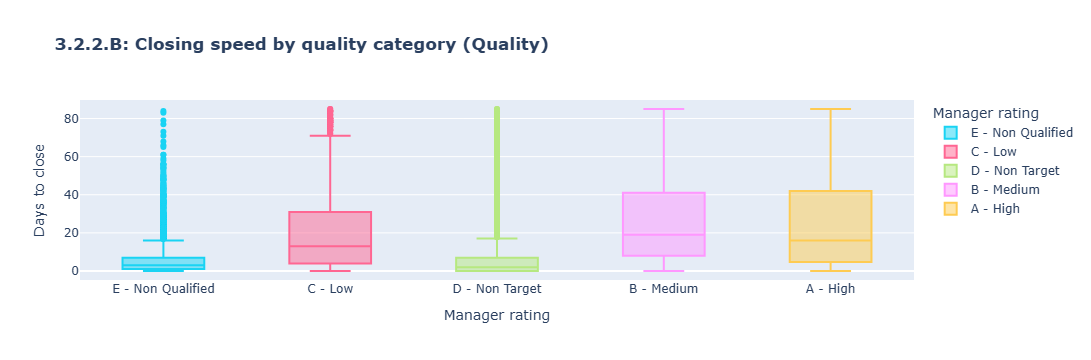

<Figure size 640x480 with 0 Axes>

In [37]:
# 1. SECTION VARIABLES 
# Calculate SLA in hours from the deals' native column
closed_deals['sla_hours'] = closed_deals['sla'].dt.total_seconds() / 3600

# Group for KPIs
fast_response_count = len(closed_deals[closed_deals['sla_hours'] <= 1])
avg_sla_hours = closed_deals['sla_hours'].median()

print(f"Median response time (SLA): {avg_sla_hours:.2f} h.")
print(f"Number of 'fast' responses (within 1 hour): {fast_response_count:_}")
print(f"Share of fast responses: {fast_response_count / len(closed_deals):.1%}")

#  2. SLA CATEGORIZATION 
def get_sla_category(h):
    if pd.isna(h) or h < 0: return '6. No data'
    if h <= 0.25:  return '1. 0-15 min'
    if h <= 1:     return '2. 15-60 min'
    if h <= 4:     return '3. 1-4 hours'
    if h <= 24:    return '4. 4-24 hours'
    return '5. Over a day'

closed_deals['sla_category'] = closed_deals['sla_hours'].apply(get_sla_category)

#  3. VISUALIZATION (PLOTLY) 

# Group data for the chart
sla_analysis = closed_deals.groupby('sla_category').agg(
    conversion=('is_real_student', 'mean'),
    total_deals=('deals_id', 'count')
).reset_index()
sla_analysis['conversion'] *= 100

fig_sla = px.bar(
    sla_analysis, x='sla_category', y='conversion',
    color='conversion',
    text=sla_analysis['conversion'].apply(lambda x: f'{x:.1f}%'),
    title='<b>3.2.2.A: Conversion by SLA</b>',
    labels={'conversion': 'Conversion (%)', 'sla_category': 'Response speed'},
    color_continuous_scale='RdYlGn'
)

# Lead-quality chart (Quality)
fig_quality = px.box(
    closed_deals[closed_deals['deal_duration_days'] <= closed_deals['deal_duration_days'].quantile(0.95)],
    x='quality', y='deal_duration_days', color='quality',
    title='<b>3.2.2.B: Closing speed by quality category (Quality)</b>',
    category_orders={"quality": ["A", "B", "C", "D", "E"]},
    labels={'deal_duration_days': 'Days to close', 'quality': 'Manager rating'}
)
plt.tight_layout()
fig_sla.show()
fig_quality.show()

### 3.2.2 Impact of SLA and Lead Quality on Conversion

`SLA and Quality analysis`:

*1. What happened?*   
* Conversion to a successful deal peaks when the first call happens within 15-60 minutes (about 5.8%) and falls to about 4% when the lead is handled after more than 24 hours.
* Response is slow: the median first-response time (SLA) is 5.5 hours and only 19.1% of closed deals were contacted within one hour.
* Google Ads produces the most noise: 43.6% of its deals are rejected within 3 days (Youtube Ads 36.3%, Telegram posts 33.5%, Tiktok Ads 29.0%, Facebook Ads 26.3%).
* Paying students decide slowly: the median time from deal creation to payment is 17.5 days (75% of students pay within 43 days), while rejections come fast (median 4.0 days).

*2. Why?*   
Quality reflects lead pre-qualification (experience, readiness); SLA reflects the manager's response speed. Both appear to matter, but observational data cannot separate them. That is why notebook 03 proposes a randomized SLA test.

*3. What happens if nothing changes?*   
About 72% of leads stay outside quality grades A-C and keep absorbing manager time, while warm leads wait. C1 stays near its current 4.4-4.7%.

*4. What needs to be done? (hypotheses to test)*   
* Filter low-quality leads at the traffic stage (qualifying fields in Google Ads forms)
* Automated SLA alerts (Telegram/Slack for managers when SLA > 12h)
* Prioritize high-quality leads with SLA < 12h in the CRM queue

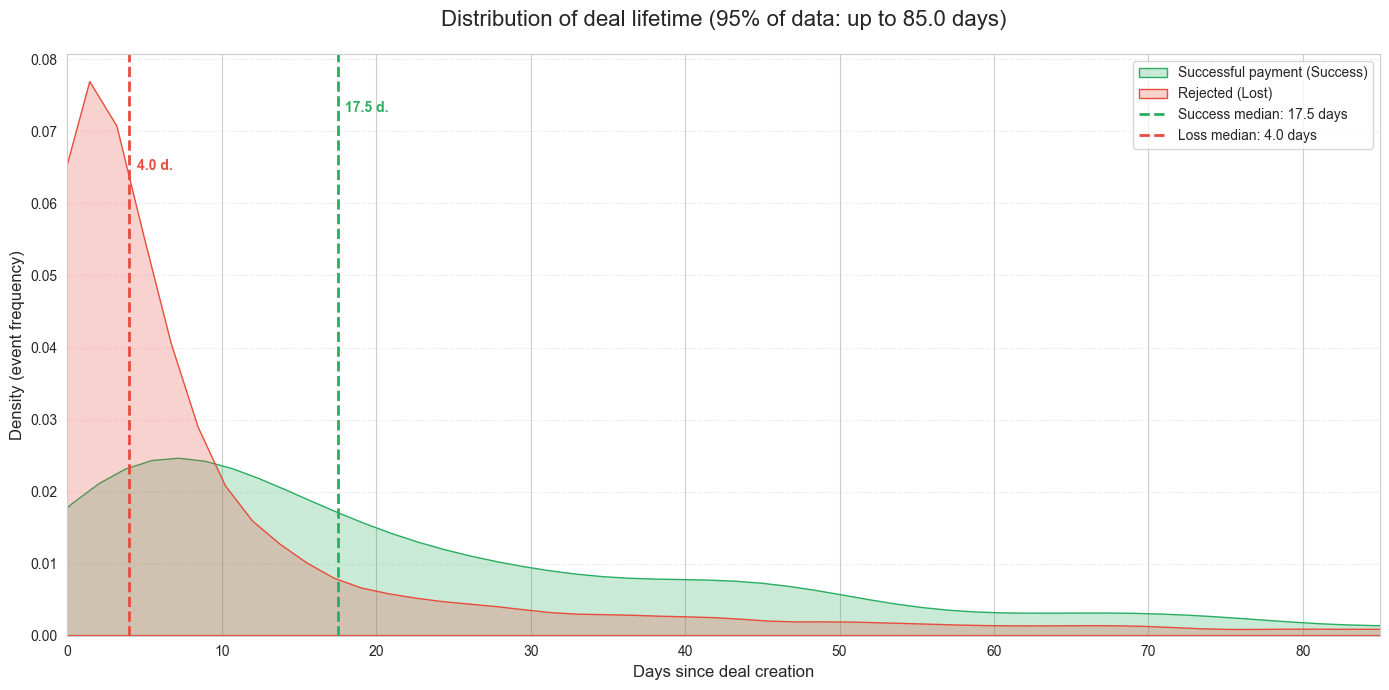

In [38]:
# COMPARING SUCCESS AND LOSS LIFETIMES 

# 1. Split closed deals into two groups
success_group = closed_deals[closed_deals['is_real_student'] == True].copy()
lost_group = closed_deals[closed_deals['stage_simplified'] == 'Lost'].copy()

# 2. Calculate the cutoff (95% of data) and medians
upper_limit = closed_deals['deal_duration_days'].quantile(0.95)
median_success = closed_deals[closed_deals['is_real_student'] == True]['deal_duration_days'].median()
median_lost = closed_deals[closed_deals['is_real_student'] == False]['deal_duration_days'].median()

# 3. Axis and plot settings (cap at 95% for clarity, since that's where most of the data is)
plt.figure(figsize=(14, 7))
sns.kdeplot(data=success_group['deal_duration_days'], fill=True, color='#27ae60', label='Successful payment (Success)', bw_adjust=0.5)
sns.kdeplot(data=lost_group['deal_duration_days'], fill=True, color='#e74c3c', label='Rejected (Lost)', bw_adjust=0.5)

# 4. Add vertical median lines
plt.axvline(median_success, color='#27ae60', linestyle='--', linewidth=2, 
            label=f'Success median: {median_success:.1f} days')
plt.axvline(median_lost, color='#e74c3c', linestyle='--', linewidth=2, 
            label=f'Loss median: {median_lost:.1f} days')

# 5. Styling
plt.xlim(0, upper_limit)
plt.title(f'Distribution of deal lifetime (95% of data: up to {upper_limit:.1f} days)', fontsize=16, pad=20)
plt.xlabel('Days since deal creation', fontsize=12)
plt.ylabel('Density (event frequency)', fontsize=12)

# Add text labels above the lines for readability
plt.text(median_success + 0.5, plt.ylim()[1]*0.9, f'{median_success:.1f} d.', color='#27ae60', fontweight='bold')
plt.text(median_lost + 0.5, plt.ylim()[1]*0.8, f'{median_lost:.1f} d.', color='#e74c3c', fontweight='bold')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
# Group analytics
print(string_delimiter)
print("Deal-cycle comparison:")
print(string_delimiter)

s_med = success_group['deal_duration_days'].median()
l_med = lost_group['deal_duration_days'].median()

print(f"• Median time to payment: {s_med:.1f} days")
print(f"• Median time to rejection: {l_med:.1f} days")

if s_med < l_med:
    diff = l_med - s_med
    print(f"\nConclusion: Customers decide to buy {diff:.1f} days faster than they walk away.")
    print(f"Recommendation: If a deal has been open for more than {success_group['deal_duration_days'].quantile(0.8):.0f} days, ")
    print(f"the probability of payment drops below 20%. That's a signal to change the manager's approach.")
print(string_delimiter)

-------------------------------------------------------------------------------
Deal-cycle comparison:
-------------------------------------------------------------------------------
• Median time to payment: 17.5 days
• Median time to rejection: 4.0 days
-------------------------------------------------------------------------------


A lot of rejections happen in the very first days (median 4 days), which means the system is receiving a lot of "noise" leads (wrong number, spam) that managers close instantly.    

Incoming traffic quality (Lead Quality):
Managers quickly qualify these leads as "not a target customer." This can be caused by:
- Overly broad ad targeting (clicks for the sake of clicks).
- Bots clicking through the ad budget.
- Errors in the lead-capture forms (people leave contact info by accident or just for a free lead magnet, with no intention to study).

Sales team efficiency:
The fact that managers close these deals "instantly" is actually good - they aren't wasting weeks calling junk. However, the high load of qualifying junk takes time away from working "warm" customers.

In [40]:
# Sources with fast rejections
# 1. Isolate fast rejections (within 3 days)
fast_lost = lost_group[lost_group['deal_duration_days'] <= 3]

# 2. Calculate the share of fast rejections per source
source_lost_stats = fast_lost.groupby('source').size().reset_index(name='fast_lost_count')
total_source_deals = deals.groupby('source').size().reset_index(name='total_deals_count')

# 3. Merge and calculate the % of "noise"
trash_report = pd.merge(source_lost_stats, total_source_deals, on='source')
trash_report['trash_rate'] = (trash_report['fast_lost_count'] / trash_report['total_deals_count']) * 100

# Print the top 5 "noisiest" sources
print("Sources with the highest share of fast rejections (noise):")
display(trash_report.sort_values('trash_rate', ascending=False).head(5))
print(f"\n 'fast_lost' - fast rejections (within 3 days)")
print(f'  "Noise" %')

Sources with the highest share of fast rejections (noise):


,source,fast_lost_count,total_deals_count,trash_rate
3,Google Ads,1693,3879,43.65
11,Youtube Ads,550,1514,36.33
7,Telegram posts,318,950,33.47
9,Tiktok Ads,521,1795,29.03
2,Facebook Ads,1158,4409,26.26



 'fast_lost' - fast rejections (within 3 days)
  "Noise" %


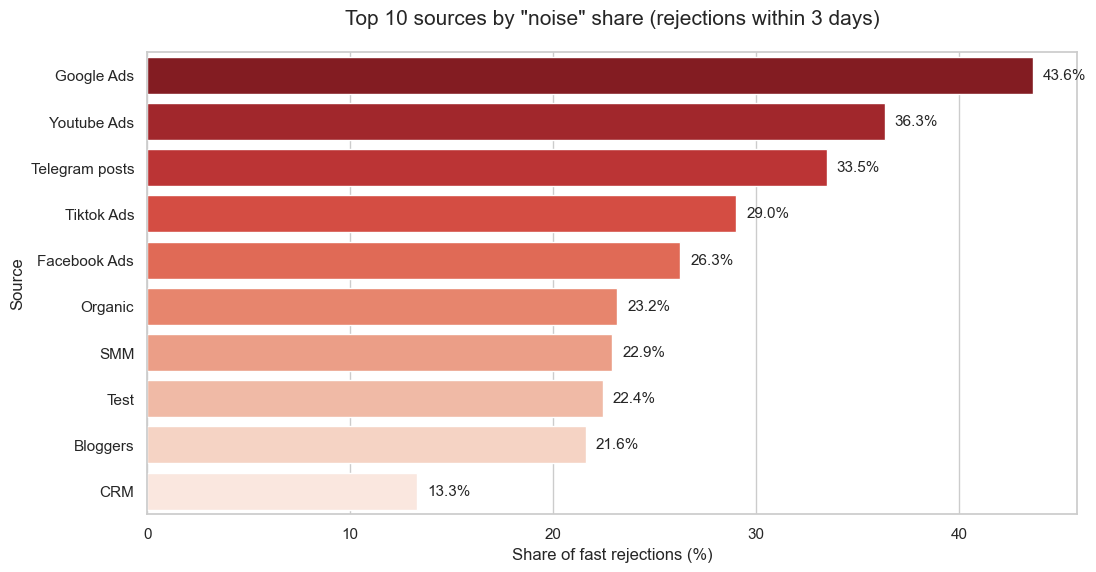

In [41]:
# Visualization
# Style setup
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Sort data for the chart
plot_data = trash_report.sort_values('trash_rate', ascending=False).head(10)

# Build the chart
ax = sns.barplot(
    x='trash_rate', 
    y='source', 
    data=plot_data, 
    hue='source',
    palette='Reds_r',
    legend=False
)

# Label formatting
plt.title('Top 10 sources by "noise" share (rejections within 3 days)', fontsize=15, pad=20)
plt.xlabel('Share of fast rejections (%)', fontsize=12)
plt.ylabel('Source', fontsize=12)

# Add the % values directly on the bars
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.5, p.get_y() + p.get_height()/2, 
            f'{width:.1f}%', va='center', fontsize=11)

# Save for the presentation
plt.savefig('trash_sources_report.png', dpi=300, bbox_inches='tight')
plt.show()

### 3.2.3 Analytical Conclusion
**Sales cycle and SLA insights**

1. What happened?
* The median time from deal creation to payment is 17.5 days (75% of paying students pay within 43 days). Rejected deals close much faster, with a median of 4.0 days.
* Many rejections happen in the first 3 days, which shows that noise traffic is filtered out quickly. This is most visible in Google Ads (43.6% of its deals).
* Response speed is a weak point: median SLA is 5.5 hours and only 19.1% of closed deals were contacted within an hour.

2. Why?
Good leads need a fast first contact, while low-quality leads clog the pipeline and take manager time. Both effects share the same manager capacity.

3. What happens if nothing changes?
Managers keep spending time on leads outside grades A-C (about 72% of the flow), and warm leads keep waiting.

4. What needs to be done?
* Automated SLA: notification when SLA > 12h, escalation at > 24h
* Quality filter: auto-close low-quality deals after 7 days of inactivity
* Follow-up sequence for deals open longer than 21 days (the paying students' typical window is up to 43 days, so nurture instead of closing blindly)

**Consequence for experiments:** a payment takes 17.5 days at the median, which is longer than a 2-week test window. Short tests must therefore rely on leading indicators (see notebook 03, Section 5).

---
# 4. Campaign & Source Analysis (Unit Economics & UA Efficiency)

Tasks:   
`Campaign efficiency analysis:`
1. Compare the efficiency of different campaigns in terms of lead generation
and conversion rate.
2. Evaluate the efficiency of different marketing sources (Source) at
generating quality leads.

## 4.1: Ad Campaign Efficiency Analysis
Compare the efficiency of different campaigns in terms of lead generation and conversion rate.

### 4.1.0 Function Setup and Metric Calculation

In [42]:
# # Input values:
# Total = 11000        # offer_total_amount — full contract amount (offer_total_amount)
# Initial = 1000       # initial_amount_paid — first payment (initial_amount_paid)
# StudyMonths = 10     # months_of_study — number of months studied (months_of_study)
# FullDuration = 11    # course_duration — full course duration (course_duration)

# # Calculate AOVi
# if (Total - Initial) > 0:
#     # Corrected formula: spread the remainder (Total - Initial) over (FullDuration - 1) months
#     denominator = (FullDuration - 1) if FullDuration > 1 else 1
    
#     # Numerator: (months excluding the first * cost per month) + first payment
#     numerator = (StudyMonths - 1) * (Total - Initial) / denominator + Initial
#     aov_i = numerator / StudyMonths
# else:
#     # If there's no additional payment, just divide the base by the duration
#     aov_i = Total / FullDuration if FullDuration > 0 else Total

# # Final revenue Ri
# ri = aov_i * StudyMonths

# print(f"With StudyMonths={StudyMonths}, Total={Total}, Initial={Initial}, FullDuration={FullDuration}:")
# print(f"Average monthly ticket (AOVi): {aov_i:.2f}")
# print(f"Total revenue (Ri): {ri:.2f}")

**What are we calculating?**
- Ri = accumulated revenue per student (AOV x paid months)
- Channel-level unit economics: CTR, CPC, CPL (= AC / Leads), CAC (= AC / B), C1 (= B / Leads), ROMI

**Funnel used in this section:** Clicks (paid traffic) -> Leads (CRM deals) -> B (unique paying students)

**Definitions** follow the glossary at the top of the notebook:
* **Clicks** = paid clicks from the spend dataset. At portfolio level the metrics tree uses UA = 17,250 unique potential clients; channel tables use Leads because campaign and source are stored on the deal.
* **B** = unique paying students (`contact_id`) from `actual_sales_clean`.
* **C1** (lead-to-student) = B / Leads x 100, the main indicator of lead-handling quality and traffic cleanliness.
* **AC** = sum of spend. **REV** = sum of Ri.

In [43]:
# # Metric calculation using the unit-economics formulas:

# # CTR (ad click-through rate)
# marketing_table['CTR'] = (marketing_table['clicks'] / marketing_table['impressions']) * 100

# # CPC (cost per click)
# marketing_table['CPC'] = marketing_table['spend'] / marketing_table['clicks']

# # Click_to_lead (click-to-application conversion)
# marketing_table['Click_to_lead'] = (marketing_table['leads'] / marketing_table['clicks']) * 100

# # CPL (cost per application/lead)
# marketing_table['CPL'] = marketing_table['spend'] / marketing_table['leads']

# # CPA (cost per closed deal/payment)
# marketing_table['CPA'] = marketing_table['spend'] / marketing_table['closed_leads']

# # conversion_leads (lead-to-payment conversion)
# marketing_table['conversion_leads'] = (marketing_table['closed_leads'] / marketing_table['leads']) * 100

# # ROMI (marketing payback - added for completeness)
# marketing_table['ROMI'] = ((marketing_table['revenue'] - marketing_table['spend']) / marketing_table['spend']) * 100

# # Clean up infinities (from division by 0)
# marketing_table.replace([np.inf, -np.inf], np.nan, inplace=True)

# # Print the final comparison table (Top 10 by spend)
# display(marketing_table.sort_values('spend', ascending=False).head(10))

### 4.1.1 Variables and Calculation Functions

In [44]:
# --- 4.1 VARIABLES AND FUNCTIONS ---

# 1. Function to calculate Ri (accumulated revenue over months of study)
#  is_real_student marks our students: (deals['is_paid'] == 1) & (deals['months_of_study'] > 0)
def calculate_revenue_ri(row):
    if pd.isna(row['is_real_student']) or not row['is_real_student']:
        return 0
    
    Total = row['offer_total_amount'] if pd.notna(row['offer_total_amount']) else 0
    Initial = row['initial_amount_paid'] if pd.notna(row['initial_amount_paid']) else 0
    StudyMonths = row['months_of_study'] if pd.notna(row['months_of_study']) else 0
    FullDuration = row['course_duration'] if pd.notna(row['course_duration']) else 1
        
    try:
        if (Total - Initial) > 0:
            denominator = (FullDuration - 1) if FullDuration > 1 else 1
            aov_i = ((StudyMonths - 1) * (Total - Initial) / denominator + Initial) / StudyMonths
        else:
            aov_i = Total / FullDuration if FullDuration > 0 else Total
        return aov_i * StudyMonths
    except:
        return 0

# # 2. Period filter parameters (identified and confirmed while loading/syncing datasets in Section 2.2)
# SYNC_START = '2023-07-01'
# SYNC_END   = '2024-05-31'

# 3. List of charts to export as PNG
plt_to_save_png = ['campaign', 'source']

### 4.1.2 Period Sync, Aggregation and Unit Economics Calculation (Campaign)

In [45]:
# PREPARING DEALS
# 1. Apply the Ri calculation (overwrite the column to avoid duplicates)
deals['Ri'] = deals.apply(calculate_revenue_ri, axis=1)
spend_fixed = h.clean_marketing_hierarchy(spend, "SPEND_FINAL")

# 2. Build a clean slice using the criteria below: 
# IMPORTANT: for monthly dynamics and to only count complete months
actual_sales_clean = deals[
    (deals['created_date'] >= SYNC_START ) & 
    (deals['created_date'] <= SYNC_END ) & 
    (deals['is_real_student'] == True)
].copy()

# 3. Sanity check before aggregation
total_ri_check = actual_sales_clean['Ri'].sum()
total_count_check = len(actual_sales_clean)

print(f"Clean revenue Ri: {total_ri_check:_.2f} €")
print(f"Number of deals: {total_count_check:_}")
actual_sales_clean.head()

=== Processing hierarchy: SPEND_FINAL ===
  [ad] by [ad_group]: recovered 0 values
  [ad_group] by [campaign]: recovered 0 values
  [campaign] by [source]: recovered 0 values
--- Done for SPEND_FINAL. Remaining missing values: 0 ---

Clean revenue Ri: 3_347_317.73 €
Number of deals: 814


,deals_id,deal_owner_name,closing_date,quality,stage,lost_reason,page,campaign,sla,ad,ad_group,source,payment_type,product,education_type,created_time,course_duration,months_of_study,initial_amount_paid,offer_total_amount,contact_id,city,created_date,is_paid,level_of_deutsch,is_real_student,stage_simplified,deal_duration_days,Ri
1704,5805028000052907070,Paula Underwood,2024-06-07,C - Low,Payment Done,NaN,/eng,12.07.2023wide_DE,0 days 14:01:57,bloggersvideo16com,wide,Tiktok Ads,One Payment,Digital Marketing,Morning,2024-05-31 20:56:00,11,2,2000.00,3000.00,5805028000052936024,Michelfeld,2024-05-31,True,Unclear,True,Payment Done,7.00,2100.00
1714,5805028000052825311,Eva Kent,2024-06-15,C - Low,Payment Done,NaN,/direct,blog2_DE,NaT,(no ad),30_05_2024,SMM,One Payment,UX/UI Design,Morning,2024-05-31 18:08:00,11,2,3500.00,3500.00,5805028000052833288,Novi Sad,2024-05-31,True,Unclear,True,Payment Done,15.00,636.36
1754,5805028000052799183,Eva Kent,2024-06-03,B - Medium,Payment Done,NaN,/eng,youtube_shorts_DE,0 days 05:47:21,video1com_new,Com_august,Youtube Ads,Recurring Payments,Digital Marketing,Evening,2024-05-31 09:32:00,11,2,500.00,4500.00,5805028000052661775,Friedrichshafen,2024-05-31,True,Unclear,True,Payment Done,3.00,900.00
1828,5805028000052542088,Quincy Vincent,NaT,B - Medium,Payment Done,NaN,/eng/test,20.05.24wide_DE,0 days 04:17:25,bloggersvideo24com,wide,Facebook Ads,One Payment,Digital Marketing,Morning,2024-05-30 10:20:00,11,2,1000.00,11000.00,5805028000052550064,Ludwigsburg,2024-05-30,True,B1,True,Payment Done,NaN,2000.00
1846,5805028000052507174,Ben Hall,NaT,A - High,Payment Done,NaN,/eng,youtube_shorts_DE,0 days 09:43:43,bloggersvideo10,Com_august,Youtube Ads,One Payment,Web Developer,Morning,2024-05-30 00:56:00,6,2,1000.00,9000.00,5805028000052392783,Hamburg,2024-05-30,True,B2,True,Payment Done,NaN,2600.00


#### 4.1.2.0 Portfolio unit economics (reference values)
The next cell computes the portfolio-level metrics with the glossary definitions. All channel, source, manager and product tables below must add up to these totals.

In [46]:
# --- 4.1.2.0 Portfolio unit economics (reference values for all following tables) ---
paid = actual_sales_clean   # verified sales: Payment Done + months_of_study > 0, inside the reporting period

portfolio = {
    'UA':  UA,                               # unique potential clients (contacts), section 2.3
    'AC':  AC,                               # marketing budget = sum of spend, section 2.3
    'B':   paid['contact_id'].nunique(),     # unique paying students
    'T':   paid['months_of_study'].sum(),    # transactions = paid months
    'REV': paid['Ri'].sum(),
}
portfolio['C1']   = portfolio['B'] / portfolio['UA'] * 100
portfolio['CPA']  = portfolio['AC'] / portfolio['UA']
portfolio['CAC']  = portfolio['AC'] / portfolio['B']
portfolio['AOV']  = portfolio['REV'] / portfolio['T']              # revenue per paid month
portfolio['APC']  = portfolio['T'] / portfolio['B']                # paid months per student
portfolio['CLTV'] = portfolio['AOV'] * portfolio['APC']            # = REV / B (COGS = 0)
portfolio['LTV']  = portfolio['CLTV'] * portfolio['C1'] / 100
portfolio['CM']   = portfolio['UA'] * (portfolio['LTV'] - portfolio['CPA'])
portfolio['ROMI, %'] = (portfolio['REV'] - portfolio['AC']) / portfolio['AC'] * 100

# Consistency checks
assert abs(portfolio['CM'] - (portfolio['REV'] - portfolio['AC'])) < 1, "CM must equal REV - AC when COGS = 0"

display(pd.Series(portfolio, name='Portfolio').round(2).to_frame())

# Control values (notebook 03, baseline)
control = {'B': 802, 'T': 4540, 'REV': 3_347_317.73, 'AOV': 737.29}
for k, v in control.items():
    status = 'OK' if abs(portfolio[k] - v) < 0.5 else 'CHECK'
    print(f"{k:<4} {portfolio[k]:>14,.2f}  (control {v:,.2f})  {status}")

,Portfolio
UA,17250.00
AC,138152.50
B,802.00
T,4540.00
REV,3347317.73
C1,4.65
CPA,8.01
CAC,172.26
AOV,737.29
APC,5.66


B            802.00  (control 802.00)  OK
T          4,540.00  (control 4,540.00)  OK
REV    3,347,317.73  (control 3,347,317.73)  OK
AOV          737.29  (control 737.29)  OK


In [47]:
# --- 4.1.2 CAMPAIGN UNIT ECONOMICS ---

# 1. Marketing metrics (AC, Clicks, Impressions)
marketing_agg = spend_fixed.groupby('campaign').agg({
    'spend': 'sum',        # AC - total ad spend in euros [from spend]
    'clicks': 'sum',       # Clicks - number of paid clicks [from spend]
    'impressions': 'sum'   # number of ad impressions [from spend]
}).reset_index()
marketing_agg.columns = ['campaign', 'AC', 'Clicks', 'Impressions']

# 2. Sales funnel (Leads = CRM deals)
leads_agg = deals.groupby('campaign').size().reset_index(name='Leads')

# 3. Financial outcome: B = unique paying students, REV = accumulated Ri
buyers_agg = actual_sales_clean.groupby('campaign').agg(
    REV=('Ri', 'sum'),
    B=('contact_id', 'nunique')
).reset_index()

# 4. Assemble the single unit-economics table (merge by campaign name)
campaign_ue = pd.merge(marketing_agg, leads_agg, on='campaign', how='outer')
campaign_ue = pd.merge(campaign_ue, buyers_agg, on='campaign', how='outer').fillna(0)

# 5. Derived metrics
campaign_ue['CTR'] = (campaign_ue['Clicks'] / campaign_ue['Impressions'] * 100)
campaign_ue['CPC'] = campaign_ue['AC'] / campaign_ue['Clicks']
campaign_ue['CPL'] = campaign_ue['AC'] / campaign_ue['Leads']      # cost per lead (channel-level CPA)
campaign_ue['CAC'] = campaign_ue['AC'] / campaign_ue['B']          # cost per paying student

# Conversions
campaign_ue['Conv_Click_to_Lead'] = (campaign_ue['Leads'] / campaign_ue['Clicks'] * 100)
campaign_ue['C1'] = (campaign_ue['B'] / campaign_ue['Leads'] * 100)
campaign_ue['ROMI'] = ((campaign_ue['REV'] - campaign_ue['AC']) / campaign_ue['AC'] * 100)

# Clean up infinities and empty values
campaign_ue = campaign_ue.replace([np.inf, -np.inf], 0).fillna(0)

# --- CHECK TABLE STRUCTURE ---
print(f"Rows in the final table: {len(campaign_ue)}")
print(f"Columns: {campaign_ue.columns.tolist()}")

Rows in the final table: 149
Columns: ['campaign', 'AC', 'Clicks', 'Impressions', 'Leads', 'REV', 'B', 'CTR', 'CPC', 'CPL', 'CAC', 'Conv_Click_to_Lead', 'C1', 'ROMI']


### TOP-10

In [48]:
marketing_agg.head(10).sort_values(by='AC', ascending=False)

,campaign,AC,Clicks,Impressions
0,(no campaign),26006.55,102189,1429607
4,02.07.23wide_DE,6528.06,9947,564667
7,04.07.23recentlymoved_DE,4234.38,7177,390948
6,03.07.23women,3954.64,6894,331988
2,01.04.23women_PL,357.25,367,45956
8,05.07.23interests_DE,333.73,425,26833
9,05.09.2023wide_DE,244.51,350,60420
1,01.02.24wide_webinar_DE,189.91,195,18047
3,02.05.24test_DE,164.04,790,20047
5,02.08.23interests_DE,69.30,76,5990


In [49]:
leads_agg.head(10).sort_values(by='Leads', ascending=False)

,campaign,Leads
0,(no campaign),2575
3,02.07.23wide_DE,923
6,04.07.23recentlymoved_DE,691
5,03.07.23women,573
9,07.07.23LAL_DE,486
2,02.05.24test_DE,156
7,05.07.23interests_DE,35
1,01.04.23women_PL,31
4,02.08.23interests_DE,8
8,05.09.2023wide_DE,6


In [50]:
buyers_agg.head(10).sort_values(by='REV', ascending=False)

,campaign,REV,B
0,(no campaign),412369.55,116
2,02.07.23wide_DE,254217.27,49
9,12.07.2023wide_DE,175885.00,45
3,03.07.23women,156768.18,30
6,07.07.23LAL_DE,126785.00,27
4,04.07.23recentlymoved_DE,101815.76,30
5,05.09.2023wide_DE,10000.00,1
1,02.05.24test_DE,9000.00,3
8,1005start,4000.00,2
7,08.04.24wide_webinar_DE,3000.00,1


In [51]:
campaign_ue.head(10).sort_values(by='REV', ascending=False)

,campaign,AC,Clicks,Impressions,Leads,REV,B,CTR,CPC,CPL,CAC,Conv_Click_to_Lead,C1,ROMI
0,(no campaign),26006.55,102189.00,1429607.00,2575.00,412369.55,116.00,7.15,0.25,10.10,224.19,2.52,4.50,1485.64
4,02.07.23wide_DE,6528.06,9947.00,564667.00,923.00,254217.27,49.00,1.76,0.66,7.07,133.23,9.28,5.31,3794.22
6,03.07.23women,3954.64,6894.00,331988.00,573.00,156768.18,30.00,2.08,0.57,6.90,131.82,8.31,5.24,3864.16
7,04.07.23recentlymoved_DE,4234.38,7177.00,390948.00,691.00,101815.76,30.00,1.84,0.59,6.13,141.15,9.63,4.34,2304.50
9,05.09.2023wide_DE,244.51,350.00,60420.00,6.00,10000.00,1.00,0.58,0.70,40.75,244.51,1.71,16.67,3989.81
3,02.05.24test_DE,164.04,790.00,20047.00,156.00,9000.00,3.00,3.94,0.21,1.05,54.68,19.75,1.92,5386.47
1,01.02.24wide_webinar_DE,189.91,195.00,18047.00,0.00,0.00,0.00,1.08,0.97,0.00,0.00,0.00,0.00,-100.00
2,01.04.23women_PL,357.25,367.00,45956.00,31.00,0.00,0.00,0.80,0.97,11.52,0.00,8.45,0.00,-100.00
5,02.08.23interests_DE,69.30,76.00,5990.00,8.00,0.00,0.00,1.27,0.91,8.66,0.00,10.53,0.00,-100.00
8,05.07.23interests_DE,333.73,425.00,26833.00,35.00,0.00,0.00,1.58,0.79,9.54,0.00,8.24,0.00,-100.00


#### 4.1.2.1 Technical Audit of Totals (Campaign UE)

In [52]:
# --- 4.1.2.1 Technical audit of totals (campaign UE) ---

print(f"=== DATA RECONCILIATION AFTER AGGREGATION (4.1.2) ===")
print(f"Period: {SYNC_START.strftime('%d.%m.%Y')} - {SYNC_END.strftime('%d.%m.%Y')}")
print(string_delimiter)

# Grand totals from the final campaign_ue table
total_rev_ue     = campaign_ue['REV'].sum()
total_buyers_ue  = campaign_ue['B'].sum()                    # sum over campaigns
unique_buyers    = actual_sales_clean['contact_id'].nunique()  # unique students overall
total_leads_ue   = campaign_ue['Leads'].sum()
total_spend_ue   = campaign_ue['AC'].sum()
total_clicks_ue  = campaign_ue['Clicks'].sum()

print(f"1. Revenue (REV / Ri):            {total_rev_ue:_.2f} EUR")
print(f"2. Students, unique overall (B):  {unique_buyers:.0f} people")
print(f"   Students, sum over campaigns:  {total_buyers_ue:.0f} (clients who bought via several campaigns are counted in each)")
print(f"3. Leads (CRM deals):             {total_leads_ue:_.0f}")
print(f"4. Spend (AC):                    {total_spend_ue:_.2f} EUR")
print(f"5. Reach (Clicks):                {total_clicks_ue:_.0f} clicks")
print(string_delimiter)

# Automatic discrepancy check against control values
expected_rev = 3_347_317.73
expected_b   = 802

rev_diff = abs(total_rev_ue - expected_rev)
b_diff   = abs(unique_buyers - expected_b)

if rev_diff < 1 and b_diff == 0:
    print("CHECK PASSED: Data fully matches the control values.")
else:
    print("WARNING: Discrepancies found!")
    if rev_diff >= 1: print(f"   - REV difference: {rev_diff:.2f} EUR")
    if b_diff != 0:   print(f"   - B difference:   {b_diff} people")

=== DATA RECONCILIATION AFTER AGGREGATION (4.1.2) ===
Period: 01.07.2023 - 31.05.2024
-------------------------------------------------------------------------------
1. Revenue (REV / Ri):            3_347_317.73 EUR
2. Students, unique overall (B):  802 people
   Students, sum over campaigns:  803 (clients who bought via several campaigns are counted in each)
3. Leads (CRM deals):             18_250
4. Spend (AC):                    138_152.50 EUR
5. Reach (Clicks):                468_577 clicks
-------------------------------------------------------------------------------
CHECK PASSED: Data fully matches the control values.


### 4.1.3 Comparing Lead Generation and Conversion (to Student)

In [53]:
# --- 4.1.3 Funnel analysis: from reach to student (Unit Economics) ---

# 1. Calculate additional conversions 
# Click-to-deal conversion (marketing efficiency)
campaign_ue['Conv_Click_to_Lead'] = (campaign_ue['Leads'] / campaign_ue['Clicks'] * 100)

# Deal-to-student conversion (traffic quality)
# Corresponds to the C1 parameter in the model
campaign_ue['C1'] = (campaign_ue['B'] / campaign_ue['Leads'] * 100)

# Finalize the shape
campaign_ue = campaign_ue.replace([np.inf, -np.inf], 0).fillna(0)

# --- Audit block (results) ---
print(f"Analysis period: {SYNC_START.strftime('%d.%m.%Y')} — {SYNC_END.strftime('%d.%m.%Y')}")
print(f"=== Technical funnel audit ===")
check_clicks = campaign_ue['Clicks'].sum()
check_leads = campaign_ue['Leads'].sum()
check_b = campaign_ue['B'].sum()

print(f"1. Total reach (Clicks):      {check_clicks:_.0f}")
print(f"2. Total leads (Leads):   {check_leads:_.0f}")
print(f"3. Total students (B, sum over campaigns): {check_b:_.0f}")
print(f"4. Overall conversion C1 (B / Leads): {(check_b/check_leads*100):.2f}%")
print(string_delimiter)

# --- Efficiency table (Top-10) ---
print(f"--- Efficiency analysis: funnel and revenue (Top-10 by B volume) ---")
print(string_delimiter)
print(f"{'Campaign':<30} | {'Clicks':<8} | {'Leads':<6} | {'B':<7} | {'C1 %':<9} | {'REV, €'}")
print(string_delimiter)

# Sort by number of students (B)
report_top = campaign_ue.sort_values('B', ascending=False).head(10)

for _, r in report_top.iterrows():
    print(f"{r['campaign'][:30]:<30} | "
          f"{r['Clicks']:<8.0f} | "
          f"{r['Leads']:<6.0f} | "
          f"{r['B']:<7.0f} | "
          f"{r['C1']:<9.2f} | "
          f"{r['REV']:_.0f}")

# --- Analytical summary ---
print("\n=== Analytical summary ===")
top_vol = campaign_ue.sort_values('B', ascending=False).iloc[0]
# Filter > 10 leads to exclude random CR spikes
valid_leads_filter = campaign_ue['Leads'] > 10
top_qual = campaign_ue[valid_leads_filter].sort_values('C1', ascending=False).iloc[0]

print(f" Leader by student volume: {top_vol['campaign']} ({top_vol['B']:.0f} people)")
print(f" Best-quality campaign (C1): {top_qual['campaign']} ({top_qual['C1']:.2f}%)")

Analysis period: 01.07.2023 — 31.05.2024
=== Technical funnel audit ===
1. Total reach (Clicks):      468_577
2. Total leads (Leads):   18_250
3. Total students (B, sum over campaigns): 803
4. Overall conversion C1 (B / Leads): 4.40%
-------------------------------------------------------------------------------
--- Efficiency analysis: funnel and revenue (Top-10 by B volume) ---
-------------------------------------------------------------------------------
Campaign                       | Clicks   | Leads  | B       | C1 %      | REV, €
-------------------------------------------------------------------------------
domain                         | 0        | 1416   | 133     | 9.39      | 546_140
(no campaign)                  | 102189   | 2575   | 116     | 4.50      | 412_370
performancemax_digitalmarkt_ru | 0        | 2572   | 108     | 4.20      | 492_625
youtube_shorts_DE              | 55437    | 1500   | 52      | 3.47      | 201_485
02.07.23wide_DE                | 9947     |

### 4.1.4 Visualization: Scale (Clicks) vs Quality (Student CR%)

In [54]:
# --- 4.1.4 FUNNEL ANALYSIS: (Clicks) vs Quality (Student CR%) ---

# 1. Prepare Clicks (reach) data
clicks_agg = spend_fixed.groupby('campaign')['clicks'].sum().reset_index()
clicks_agg.columns = ['campaign', 'Clicks']

# 2. Prepare Leads (interest) data
leads_agg = deals.groupby('campaign').size().reset_index(name='Leads')

# 3. Sync (guard against duplicate columns)
# Drop Clicks and Leads from the main table if they're already there from a previous run
cols_to_drop = [c for c in ['Clicks', 'Leads'] if c in campaign_ue.columns]
if cols_to_drop:
    campaign_ue = campaign_ue.drop(columns=cols_to_drop)

# Attach the fresh aggregates
campaign_ue = pd.merge(campaign_ue, clicks_agg, on='campaign', how='left')
campaign_ue = pd.merge(campaign_ue, leads_agg, on='campaign', how='left').fillna(0)

# 4. Calculate costs and conversions (UE Flow)
# Fill with 0 to prevent division errors
campaign_ue['CPC'] = (campaign_ue['AC'] / campaign_ue['Clicks']).replace([np.inf, -np.inf], 0).fillna(0)

# How efficiently clicks convert into applications
campaign_ue['Conv_Click_to_Lead'] = (campaign_ue['Leads'] / campaign_ue['Clicks'] * 100).replace([np.inf, -np.inf], 0).fillna(0)

# C1: How efficiently applications convert into students (Buyers)
campaign_ue['C1'] = (campaign_ue['B'] / campaign_ue['Leads'] * 100).replace([np.inf, -np.inf], 0).fillna(0)

# --- FUNNEL CHECK BLOCK ---
total_clicks_val = campaign_ue['Clicks'].sum()
total_leads_val = campaign_ue['Leads'].sum()
total_b_val = campaign_ue['B'].sum()

print(f"--- FUNNEL CHECK (TOTALS) ---")
print(f"1. Clicks (paid reach):       {total_clicks_val:_.0f}")
print(f"2. Leads (all applications):    {total_leads_val:_.0f}")
print(f"3. B (all students):     {total_b_val:_.0f}")
print(f"4. Overall conversion C1:   {(total_b_val / total_leads_val * 100 if total_leads_val > 0 else 0):.2f}%")

--- FUNNEL CHECK (TOTALS) ---
1. Clicks (paid reach):       468_577
2. Leads (all applications):    18_250
3. B (all students):     803
4. Overall conversion C1:   4.40%


In [55]:
campaign_ue.head().sort_values(by='Conv_Click_to_Lead', ascending=False)

,campaign,AC,Impressions,REV,B,CTR,CPC,CPL,CAC,Conv_Click_to_Lead,C1,ROMI,Clicks,Leads
3,02.05.24test_DE,164.04,20047.00,9000.00,3.00,3.94,0.21,1.05,54.68,19.75,1.92,5386.47,790.00,156.00
4,02.07.23wide_DE,6528.06,564667.00,254217.27,49.00,1.76,0.66,7.07,133.23,9.28,5.31,3794.22,9947.00,923.00
2,01.04.23women_PL,357.25,45956.00,0.00,0.00,0.80,0.97,11.52,0.00,8.45,0.00,-100.00,367.00,31.00
0,(no campaign),26006.55,1429607.00,412369.55,116.00,7.15,0.25,10.10,224.19,2.52,4.50,1485.64,102189.00,2575.00
1,01.02.24wide_webinar_DE,189.91,18047.00,0.00,0.00,1.08,0.97,0.00,0.00,0.00,0.00,-100.00,195.00,0.00


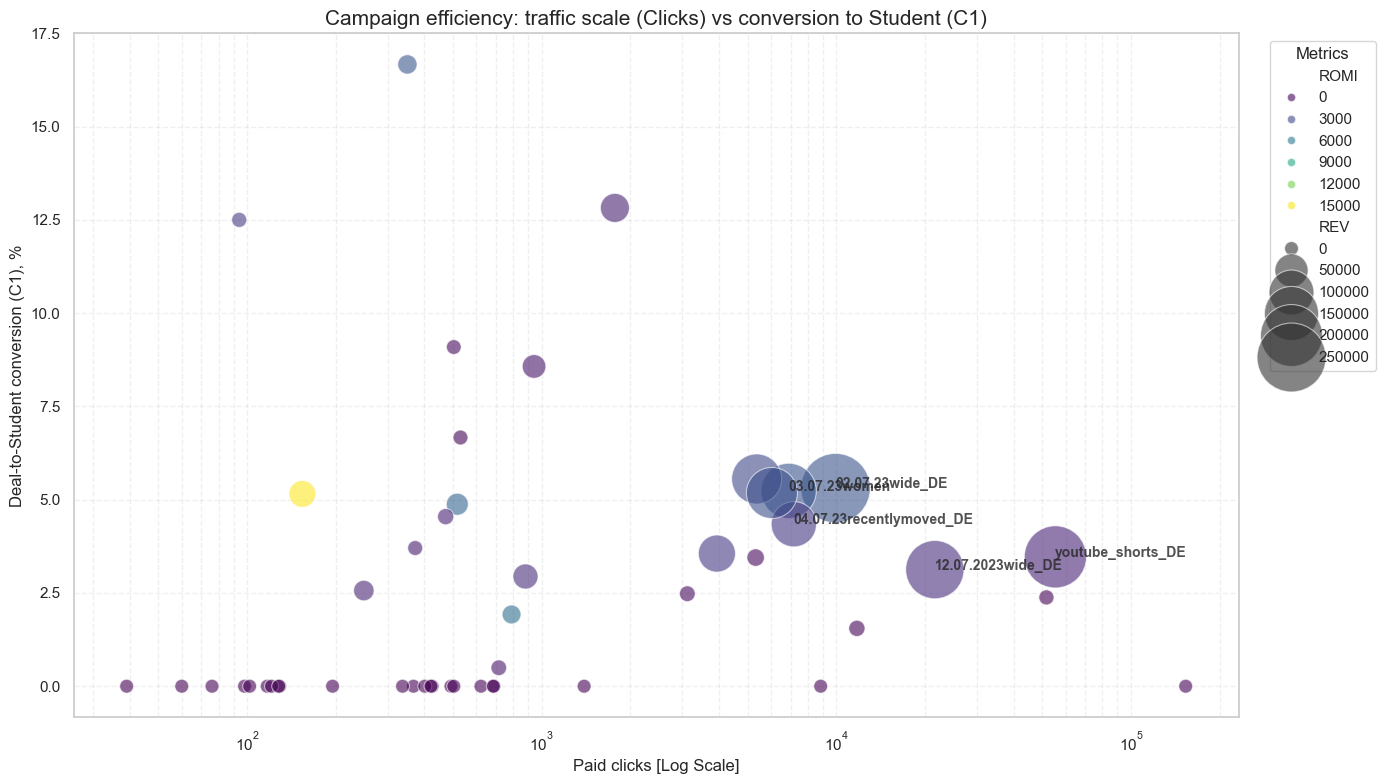

In [56]:
# --- 4.1.4 VISUALIZATION: TRAFFIC SCALE (Clicks) vs QUALITY (C1) ---

plt.figure(figsize=(14, 8))

# 1. Filter out noise and tiny campaigns
# Remove organic and campaigns with negligible traffic for a clean sample
plot_data = campaign_ue[
    (campaign_ue['campaign'] != '(no campaign)') & 
    (campaign_ue['Clicks'] > 10) 
].copy()

# 2. Build the chart
scatter = sns.scatterplot(
    data=plot_data,
    x='Clicks',                 # number of clicks
    y='C1',                 # deal-to-student conversion
    size='REV',             # bubble size - revenue Ri
    hue='ROMI',             # color - payback
    sizes=(100, 2500),      # bubble size range
    palette='viridis',
    alpha=0.6
)

# 3. Axis settings
plt.xscale('log') # log scale for Clicks, to spread out campaigns
plt.title("Campaign efficiency: traffic scale (Clicks) vs conversion to Student (C1)", fontsize=15)
plt.xlabel("Paid clicks [Log Scale]")
plt.ylabel("Deal-to-Student conversion (C1), %")

# 4. Legend and grid
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Metrics')
plt.grid(True, which="both", linestyle='--', alpha=0.3)

# 5. Labels for the top 5 campaigns by number of students (B)
# Using the 'B' column (Buyers/Students)
top_by_b = plot_data.sort_values('B', ascending=False).head(5)

for _, row in top_by_b.iterrows():
    plt.text(
        row['Clicks'], 
        row['C1'], 
        row['campaign'][:25], 
        fontsize=10, 
        fontweight='bold', 
        alpha=0.8
    )

plt.tight_layout()

# 6. Save
if 'campaign' in plt_to_save_png:
    # Use the project's save path if IMAGES is defined, otherwise just the filename
    save_path = "02_marketing_ua_to_c1_efficiency.png"
    plt.savefig(save_path, dpi=150, bbox_inches='tight')

plt.show()

In [57]:
plot_data.head()

,campaign,AC,Impressions,REV,B,CTR,CPC,CPL,CAC,Conv_Click_to_Lead,C1,ROMI,Clicks,Leads
1,01.02.24wide_webinar_DE,189.91,18047.00,0.00,0.00,1.08,0.97,0.00,0.00,0.00,0.00,-100.00,195.00,0.00
2,01.04.23women_PL,357.25,45956.00,0.00,0.00,0.80,0.97,11.52,0.00,8.45,0.00,-100.00,367.00,31.00
3,02.05.24test_DE,164.04,20047.00,9000.00,3.00,3.94,0.21,1.05,54.68,19.75,1.92,5386.47,790.00,156.00
4,02.07.23wide_DE,6528.06,564667.00,254217.27,49.00,1.76,0.66,7.07,133.23,9.28,5.31,3794.22,9947.00,923.00
5,02.08.23interests_DE,69.30,5990.00,0.00,0.00,1.27,0.91,8.66,0.00,10.53,0.00,-100.00,76.00,8.00


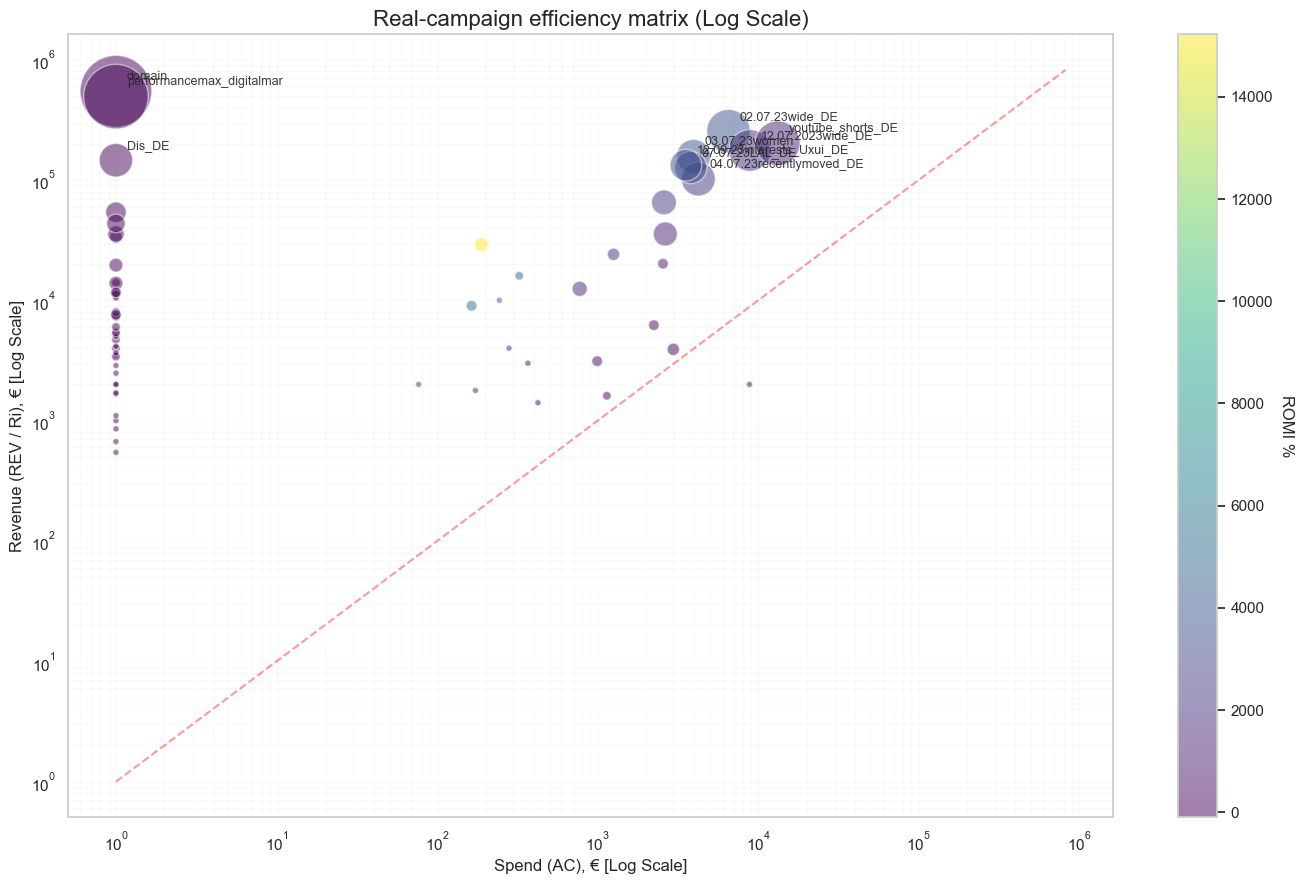

In [58]:
# --- 4.1.4 EFFICIENCY MATRIX (CLEANED) ---

# 1. Filter and prepare the data
# Remove "(no campaign)" and similar technical placeholders
filter_list = ['(no campaign)', 'nan', 'None', 'unknown']
plot_df = campaign_ue[~campaign_ue['campaign'].isin(filter_list)].copy()

# Prepare for the log scale (minimum 1 euro)
plot_df['AC_safe'] = plot_df['AC'].apply(lambda x: x if x > 1 else 1)
plot_df['REV_safe'] = plot_df['REV'].apply(lambda x: x if x > 1 else 1)

plt.figure(figsize=(14, 9))

# 2. Draw the bubbles
scatter = plt.scatter(
    plot_df['AC_safe'], 
    plot_df['REV_safe'], 
    s=plot_df['B'] * 20, 
    c=plot_df['ROMI'], 
    cmap='viridis', 
    alpha=0.5, 
    edgecolors="white", 
    linewidth=1
)

# 3. Log scale
plt.xscale('log')
plt.yscale('log')

# 4. Break-even line (ROMI = 0)
min_val = 1
max_val = max(plot_df['AC_safe'].max(), plot_df['REV_safe'].max()) * 1.5
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', alpha=0.4, label='ROMI = 0%')

# 5. Styling
plt.title('Real-campaign efficiency matrix (Log Scale)', fontsize=16)
plt.xlabel('Spend (AC), € [Log Scale]', fontsize=12)
plt.ylabel('Revenue (REV / Ri), € [Log Scale]', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.1)

# 6. Color scale
cbar = plt.colorbar(scatter)
cbar.set_label('ROMI %', rotation=270, labelpad=15)

# 7. Labels for the top 10 real campaigns
top_labels = plot_df.sort_values('REV', ascending=False).head(10)
for i, txt in enumerate(top_labels['campaign']):
    plt.annotate(
        txt[:25], 
        (top_labels['AC_safe'].iat[i], top_labels['REV_safe'].iat[i]),
        xytext=(8, 8), 
        textcoords='offset points', 
        fontsize=9, 
        alpha=0.9
    )

plt.tight_layout()
plt.show()

### 4.1.5 Analytical Conclusion

Based on the unit-economics analysis and efficiency visualizations, the main points are:

1) **Revenue concentration**
The 10 best campaigns generate about 50% of revenue (EUR 1.66M of EUR 3.35M). The unattributed bucket "(no campaign)" alone brings EUR 412K (12.3%).  
`Recommendation`: audit the settings of the top campaigns before scaling them.

2) **Cost efficiency (AC vs REV)**
The best returns come from small, targeted campaigns: 03.07.23women (ROMI 3,864%), 02.07.23wide_DE (3,794%) and 12.09.23interests_Uxui_DE (3,642%), each on EUR 3.5-6.5K of spend. youtube_shorts_DE spent EUR 13.2K for ROMI 1,425%.  
`Recommendation`: increase budget gradually on the high-ROMI segments and monitor C1 and CPL as spend grows.

3) **Funnel quality (Clicks -> Leads -> B)**
Among the top campaigns C1 ranges from 3.1% (12.07.2023wide_DE) to 5.6% (07.07.23LAL_DE). High volume does not guarantee quality: youtube_shorts_DE brings 55K clicks and 1,500 leads at C1 3.5%. brand_search_eng_DE converts best among the top 10 by revenue (C1 12.8%) but is small (117 leads) and costs more per lead (CPL EUR 22.6).  
`Recommendation`: review targeting for campaigns with below-average C1; treat brand search as a high-intent niche.

4) **Attribution gap (no campaign)**
14% of leads (2,575) and 12% of revenue are tagged "(no campaign)": organic traffic, direct visits or missing UTM tags.  
`Recommendation`: tighten UTM discipline to reduce unattributed revenue.

5) **Break-even check**
The matrix above shows the ROMI = 0 line in red. Campaigns below it should be reviewed individually: in a growth phase this can be acceptable only if the expected CLTV (about EUR 4.2K per student) outweighs the CAC for that campaign.

## 4.2 Source Efficiency

Evaluate the efficiency of different marketing sources (Source) at generating quality leads.

### 4.2.1 Quality Category Analysis

In [59]:
print("Lead distribution by quality:")
display(deals['quality'].value_counts())

Lead distribution by quality:


quality
E - Non Qualified    5843
D - Non Target       5614
C - Low              3293
B - Medium           1440
A - High              404
Unknown                 0
Name: count, dtype: int64

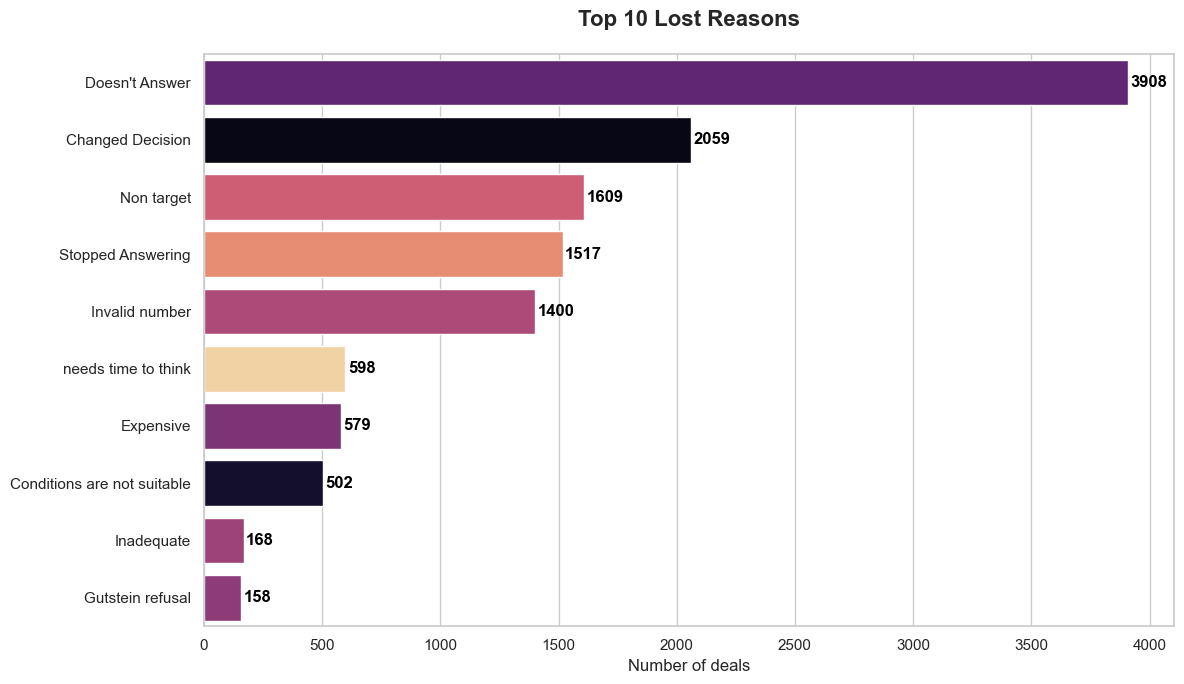

Chart sorted and saved successfully: 04_lost_reasons_sorted.png


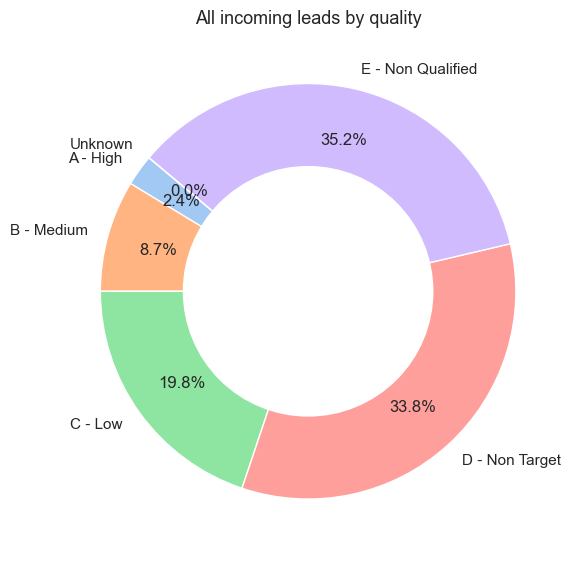

In [60]:
# 4.2.1. Source + lead-quality distribution analysis

# 1. Prepare and strictly sort the data
lost_counts = deals[deals['stage_simplified'] == 'Lost']['lost_reason'].value_counts()
lost_data = lost_counts.reset_index()
lost_data.columns = ['reason', 'count']

# Sort descending (most frequent reasons on top)
lost_data = lost_data.sort_values('count', ascending=False).head(10)

# 2. Build the chart
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid") 
# Explicit order + hue, legend & dodge=False
plot = sns.barplot(
    data=lost_data, 
    x='count', 
    y='reason', 
    hue='reason',
    palette='magma', 
    order=lost_data['reason'],
    legend=False,
    dodge=False  # Сохраняет полноразмерные столбцы
)

# Titles
plt.title('Top 10 Lost Reasons', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of deals', fontsize=12)
plt.ylabel('', fontsize=12)

# Add value labels directly on the bars
for i, v in enumerate(lost_data['count']):
    plot.text(v + 10, i, str(int(v)), color='black', va='center', fontweight='bold')

# 3. SAVE
save_path = "04_lost_reasons_sorted.png"
plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Chart sorted and saved successfully: {save_path}")

# --- 3. Donut Chart (quality distribution) ---
fig, ax = plt.subplots(figsize=(6, 6))

quality_dist = deals['quality'].value_counts().sort_index()

ax.pie(
    quality_dist, 
    labels=quality_dist.index, 
    autopct='%1.1f%%', 
    colors=sns.color_palette('pastel'), 
    startangle=140, 
    pctdistance=0.75
)

# Draw the "hole"
centre_circle = plt.Circle((0, 0), 0.60, fc='white')
ax.add_artist(centre_circle)

plt.title('All incoming leads by quality', fontsize=13)

save_path = "04_Donut_Chart.png"
plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

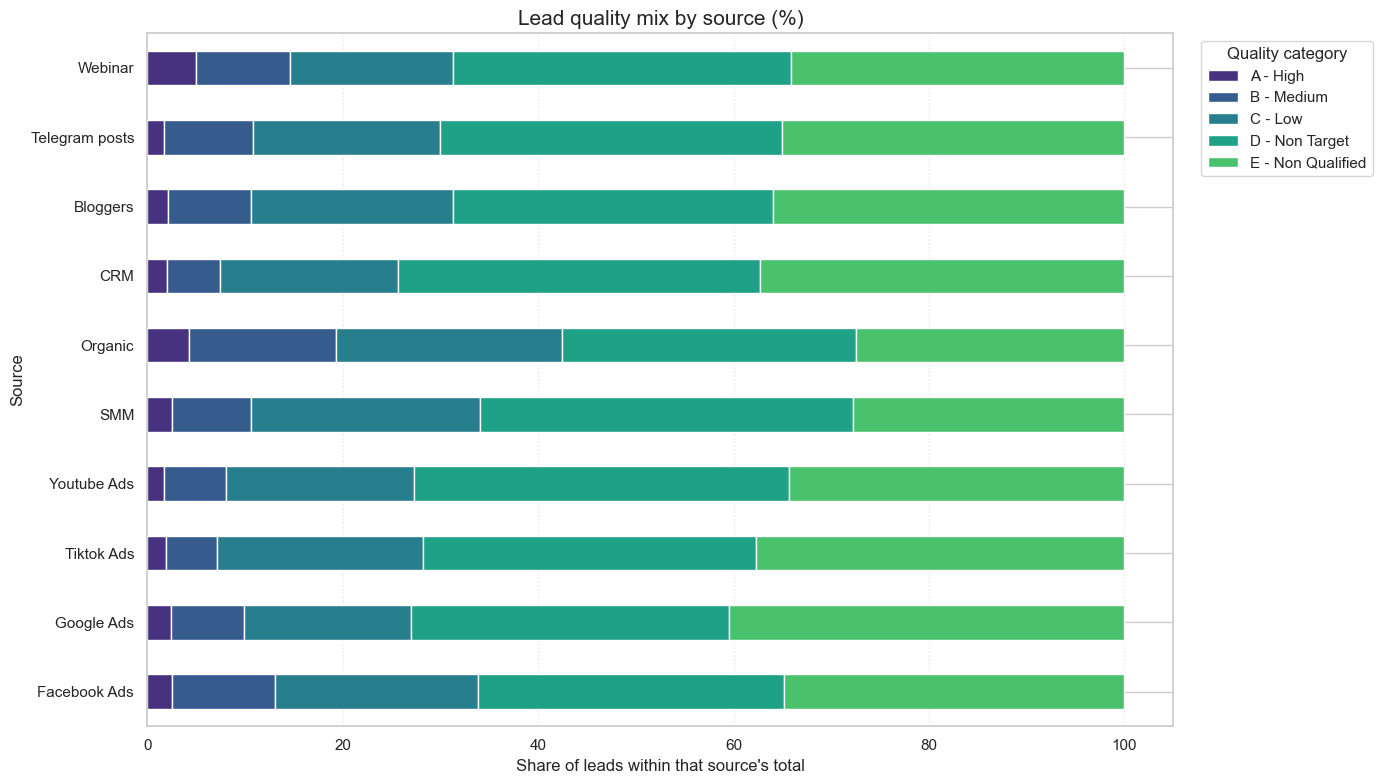

In [62]:
# --- QUALITY BREAKDOWN BY SOURCE  ---

# 1. Build the cross-tab
quality_source_pivot = pd.crosstab(deals['source'], deals['quality'], normalize='index') * 100

# 2. Limit to the TOP sources by lead volume, to keep the chart readable
top_sources_list = deals['source'].value_counts().head(10).index
quality_source_pivot = quality_source_pivot.loc[top_sources_list]

# 3. Visualization
quality_source_pivot.plot(kind='barh', stacked=True, figsize=(14, 8), 
                          color=sns.color_palette('viridis', n_colors=len(deals['quality'].unique())))

plt.title('Lead quality mix by source (%)', fontsize=15)
plt.xlabel("Share of leads within that source's total")
plt.ylabel('Source')
plt.legend(title='Quality category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='x', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

In [63]:
# --- 4.2.1 AGGREGATING DATA BY SOURCE ---

# 1. Marketing metrics from spend_fixed
source_marketing = spend_fixed.groupby('source').agg({
    'spend': 'sum',
    'clicks': 'sum',
    'impressions': 'sum'
}).reset_index()
source_marketing.columns = ['source', 'AC', 'Clicks', 'Impressions']

# 2. Sales funnel (Leads = CRM deals) from deals
source_leads = deals.groupby('source').size().reset_index(name='Leads')

# 3. Financial outcome: B = unique paying students, REV = accumulated Ri
source_buyers = actual_sales_clean.groupby('source').agg(
    REV=('Ri', 'sum'),
    B=('contact_id', 'nunique')
).reset_index()

# 4. Assemble the source unit-economics table
source_ue = pd.merge(source_marketing, source_leads, on='source', how='outer')
source_ue = pd.merge(source_ue, source_buyers, on='source', how='outer').fillna(0)

# 5. Derived metrics
source_ue['CPC'] = source_ue['AC'] / source_ue['Clicks']
source_ue['CPL'] = source_ue['AC'] / source_ue['Leads']     # cost per lead (channel-level CPA)
source_ue['CAC'] = source_ue['AC'] / source_ue['B']         # cost per paying student
source_ue['C1'] = (source_ue['B'] / source_ue['Leads'] * 100)
source_ue['ROMI'] = ((source_ue['REV'] - source_ue['AC']) / source_ue['AC'] * 100)

# Clean up infinities
source_ue = source_ue.replace([np.inf, -np.inf], 0).fillna(0)

# --- CHECK SOURCE TOTALS ---
print(f"=== TECHNICAL AUDIT (SOURCE UE) ===")
print(f"Total revenue: {source_ue['REV'].sum():_.2f} EUR")
print(f"Total students, unique overall: {actual_sales_clean['contact_id'].nunique():.0f}  (sum over sources: {source_ue['B'].sum():.0f})")
print(f"Total spend: {source_ue['AC'].sum():_.2f} EUR")

=== TECHNICAL AUDIT (SOURCE UE) ===
Total revenue: 3_347_317.73 EUR
Total students, unique overall: 802  (sum over sources: 803)
Total spend: 138_152.50 EUR


### 4.2.2 Source Efficiency by Quality Leads

In [64]:
# --- 4.2.2 LEAD QUALITY BY SOURCE ---

# 1. Define the "working" quality categories
quality_map = ['A - High', 'B - Medium', 'C - Low']

# 2. Group deals from the main deals dataset (which has all 17k+ applications)
source_quality = deals.groupby('source').agg(
    total_leads=('deals_id', 'count'),
    quality_leads=('quality', lambda x: x.isin(quality_map).sum())
).reset_index()

# 3. Merge with our source_ue table (built in 4.2.1), which already has AC
source_quality_report = pd.merge(source_ue, source_quality, on='source', how='left').fillna(0)

# 4. Calculate quality-specific metrics
# CPQL (Cost Per Quality Lead) - cost of one "good" lead
source_quality_report['CPQL'] = source_quality_report['AC'] / source_quality_report['quality_leads']

# Quality Rate (%) - share of A, B, C leads out of the total
source_quality_report['Quality_Rate'] = (source_quality_report['quality_leads'] / source_quality_report['total_leads'] * 100)

# Cleanup
source_quality_report = source_quality_report.replace([np.inf, -np.inf], 0).fillna(0)

print("=== SOURCE ANALYSIS: QUALITY vs COST ===")
display(source_quality_report.sort_values('quality_leads', ascending=False)[
    ['source', 'AC', 'total_leads', 'quality_leads', 'Quality_Rate', 'CPQL', 'ROMI']
].head(10))

=== SOURCE ANALYSIS: QUALITY vs COST ===


,source,AC,total_leads,quality_leads,Quality_Rate,CPQL,ROMI
2,Facebook Ads,31318.39,4409,1409,31.96,22.23,2765.97
3,Google Ads,53231.59,3879,1043,26.89,51.04,1226.80
5,Organic,0.00,1416,540,38.14,0.00,0.00
7,SMM,6414.52,1501,461,30.71,13.91,4347.21
10,Tiktok Ads,10988.89,1795,458,25.52,23.99,1685.39
12,Youtube Ads,13695.01,1514,412,27.21,33.24,1371.23
0,Bloggers,13309.00,1028,292,28.40,45.58,1122.98
8,Telegram posts,6266.16,950,283,29.79,22.14,2251.76
1,CRM,0.00,1120,114,10.18,0.00,0.00
11,Webinar,2320.73,281,88,31.32,26.37,4550.08


### 4.2.3 Summary Table: Campaign Efficiency (UE)

In [65]:
# --- 4.2.3 Summary table: campaign efficiency (UE) ---

# 1. Aggregate marketing data (by campaign only)
spend_pivot = spend_fixed.groupby('campaign').agg({
    'spend': 'sum',
    'clicks': 'sum'
}).reset_index()
spend_pivot.columns = ['campaign', 'AC', 'Clicks']

# 2. Aggregate funnel data (Leads and Quality Leads)
deals_pivot = deals.groupby('campaign').agg(
    Leads=('deals_id', 'count'),
    Q_Leads=('quality', lambda x: x.isin(quality_map).sum())
).reset_index()

# 3. Aggregate sales data (B and REV)
sales_pivot = actual_sales_clean.groupby('campaign').agg(REV=('Ri', 'sum'), B=('contact_id', 'nunique')).reset_index()

# 4. Assemble
full_report = pd.merge(spend_pivot, deals_pivot, on='campaign', how='left')
full_report = pd.merge(full_report, sales_pivot, on='campaign', how='left').fillna(0)

# 5. Calculate unit economics
full_report['CPL'] = full_report['AC'] / full_report['Leads']
full_report['CPQL'] = full_report['AC'] / full_report['Q_Leads']
full_report['C1'] = (full_report['B'] / full_report['Leads'] * 100)
full_report['ROMI'] = ((full_report['REV'] - full_report['AC']) / full_report['AC'] * 100)

full_report = full_report.replace([np.inf, -np.inf], 0).fillna(0)

# Sort by revenue and trim for display
final_view = full_report.sort_values('REV', ascending=False).head(10)

print("=== TOP-10 CAMPAIGNS BY REVENUE ===")
display(final_view)

=== TOP-10 CAMPAIGNS BY REVENUE ===


,campaign,AC,Clicks,Leads,Q_Leads,REV,B,CPL,CPQL,C1,ROMI
0,(no campaign),26006.55,102189,2575.00,651.00,412369.55,116.00,10.10,39.95,4.50,1485.64
4,02.07.23wide_DE,6528.06,9947,923.00,330.00,254217.27,49.00,7.07,19.78,5.31,3794.22
48,youtube_shorts_DE,13210.90,55437,1500.00,409.00,201484.85,52.00,8.81,32.30,3.47,1425.14
15,12.07.2023wide_DE,8871.72,21607,1440.00,403.00,175885.00,45.00,6.16,22.01,3.12,1882.54
6,03.07.23women,3954.64,6894,573.00,181.00,156768.18,30.00,6.90,21.85,5.24,3864.16
16,12.09.23interests_Uxui_DE,3544.84,6046,502.00,197.00,132627.27,26.00,7.06,17.99,5.18,3641.42
10,07.07.23LAL_DE,3802.56,5366,486.00,146.00,126785.00,27.00,7.82,26.04,5.56,3234.20
7,04.07.23recentlymoved_DE,4234.38,7177,691.00,208.00,101815.76,30.00,6.13,20.36,4.34,2304.50
35,24.09.23retargeting_DE,2588.08,3933,450.00,150.00,65120.00,16.00,5.75,17.25,3.56,2416.15
39,brand_search_eng_DE,2638.58,1772,117.00,52.00,35589.70,15.00,22.55,50.74,12.82,1248.82


### 4.2.4 Volume vs Lead Quality by Source

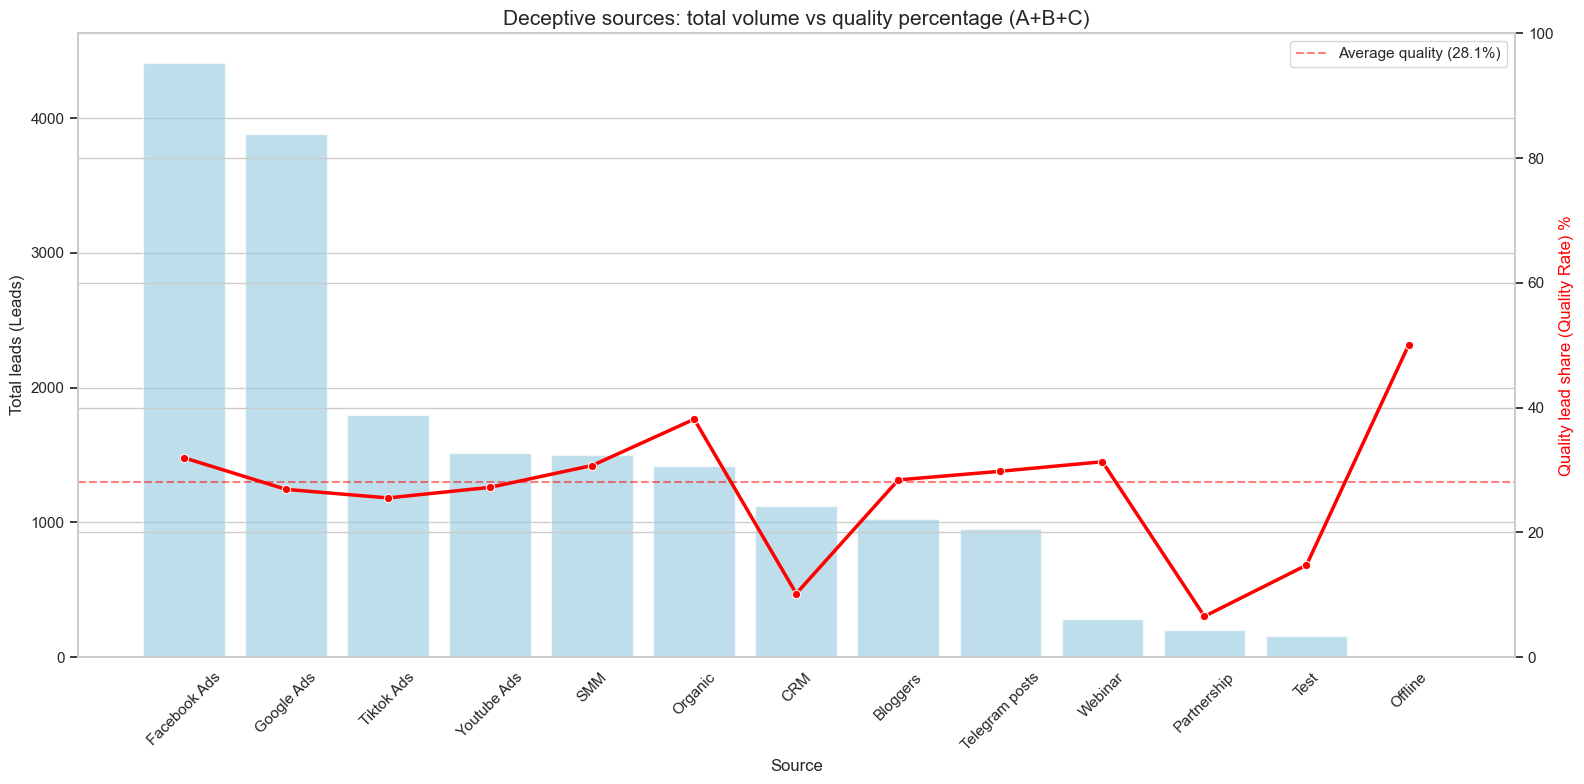

In [66]:
# --- 4.2.5 COMBINED ANALYSIS: VOLUME vs QUALITY % ---

# 1. Calculate metrics by source
quality_map = ['A - High', 'B - Medium', 'C - Low']

source_efficiency = deals.groupby('source').agg(
    total_leads=('deals_id', 'count'),
    quality_leads=('quality', lambda x: x.isin(quality_map).sum())
).reset_index()

# Calculate the quality %
source_efficiency['quality_rate'] = (source_efficiency['quality_leads'] / source_efficiency['total_leads']) * 100

# Filter to the TOP-15 sources by volume so the chart stays readable
source_efficiency = source_efficiency.sort_values('total_leads', ascending=False).head(15)

# 2. Build a two-axis chart
fig, ax1 = plt.subplots(figsize=(16, 8))

# Axis 1: Bars (total leads)
sns.barplot(data=source_efficiency, x='source', y='total_leads', alpha=0.6, color='skyblue', ax=ax1)
ax1.set_ylabel('Total leads (Leads)', fontsize=12)
ax1.set_xlabel('Source', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# Axis 2: Line (share of quality leads A+B+C)
ax2 = ax1.twinx()
sns.lineplot(data=source_efficiency, x='source', y='quality_rate', color='red', marker='o', linewidth=2.5, ax=ax2)
ax2.set_ylabel('Quality lead share (Quality Rate) %', color='red', fontsize=12)
ax2.set_ylim(0, 100) # 0 to 100 percent

# Add the project-wide average quality line
avg_quality = (deals['quality'].isin(quality_map).sum() / len(deals) * 100)
ax2.axhline(avg_quality, color='red', linestyle='--', alpha=0.5, label=f'Average quality ({avg_quality:.1f}%)')

plt.title('Deceptive sources: total volume vs quality percentage (A+B+C)', fontsize=15)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

Average quality across all sources (28.1%).
1. **Volume leaders with mediocre quality (Facebook Ads and Google Ads)**
These channels are the absolute leaders by volume (8,288 leads, 45% of the flow), but their quality is close to the average (Facebook 32.0%, Google 26.9%).

`Facebook Ads`: Huge volume (4,409 leads), but only slightly above-average quality. This means the sales team spends enormous effort sifting this volume to find the ~30% of genuine applications.

`Google Ads`: Below-average quality. Likely a lot of "cold" or off-target traffic that just burns managers' time.

2. **CRM anomaly**
The red line drops off a cliff for `CRM`. Quality there is critically low (about 10%).

**Insight**: Either this is a "dead" contact base used for mailings, or it's picking up technical junk. Spending sales time on this source, as-is, isn't worthwhile.

3. **"Gold mine" (Organic)**
`Organic` has noticeably above-average quality (almost 40%).

**Insight**: People who find you on their own are the most loyal. This confirms the value of content marketing and SEO.

4. **Small-channel efficiency (Webinar and Offline)**
Webinar: Generates few leads, but above-average quality. A great warm-up tool.

`Offline`: Quality spikes here (the highest point on the line), but the sample is tiny (a negligible bar). Likely manual, one-off contacts.

### 4.2.5 SLA vs QUALITY: CORRELATION

Chart saved as: 03_sla_vs_quality_correlation.png


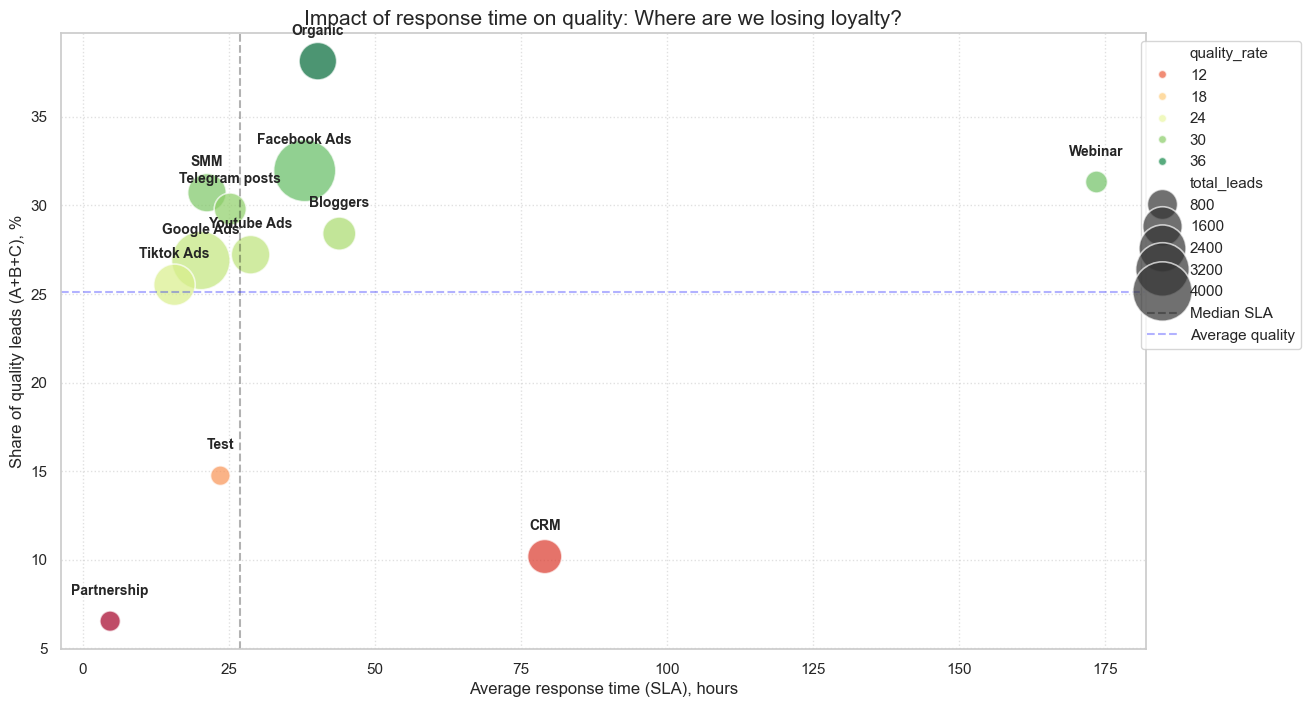

In [67]:
# --- 4.2.5 SLA vs QUALITY: CORRELATION ---

# 1. Convert timedelta to hours (float) so we can average it
# .dt.total_seconds() / 3600 gives a fractional number of hours
deals['SLA_hours'] = deals['sla'].dt.total_seconds() / 3600

# 2. Aggregate by source
quality_map = ['A - High', 'B - Medium', 'C - Low']

sla_analysis = deals.groupby('source').agg(
    avg_sla_h=('SLA_hours', 'mean'),
    quality_rate=('quality', lambda x: (x.isin(quality_map).sum() / len(x) * 100)),
    total_leads=('deals_id', 'count')
).reset_index()

# Filter to sources with >100 leads for statistical significance
sla_analysis = sla_analysis[sla_analysis['total_leads'] > 100]

# 3. Visualization
plt.figure(figsize=(14, 8))

# Bubble chart
scatter = sns.scatterplot(
    data=sla_analysis,
    x='avg_sla_h',
    y='quality_rate',
    size='total_leads',
    hue='quality_rate',
    palette='RdYlGn', # from red (bad) to green (good)
    sizes=(200, 2000),
    alpha=0.7
)

# Source name labels
for i in range(sla_analysis.shape[0]):
    plt.text(
        sla_analysis.avg_sla_h.iloc[i], 
        sla_analysis.quality_rate.iloc[i] + 1.5, 
        sla_analysis.source.iloc[i], 
        fontsize=10, weight='bold', ha='center'
    )

# Overall average lines (based on the filtered data)
plt.axvline(sla_analysis['avg_sla_h'].median(), color='black', linestyle='--', alpha=0.3, label='Median SLA')
plt.axhline(sla_analysis['quality_rate'].mean(), color='blue', linestyle='--', alpha=0.3, label='Average quality')

plt.title('Impact of response time on quality: Where are we losing loyalty?', fontsize=15)
plt.xlabel('Average response time (SLA), hours')
plt.ylabel('Share of quality leads (A+B+C), %')
plt.legend(bbox_to_anchor=(1.15, 1), loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

# --- SAVE BLOCK ---
# 1. Save the chart
plot_filename = "03_sla_vs_quality_correlation.png"
plt.savefig(plot_filename, dpi=150, bbox_inches='tight')
print(f"Chart saved as: {plot_filename}")

plt.show()

In [68]:
# Check the 'SLA' values
sla_analysis.sort_values(by='avg_sla_h', ascending=False)

,source,avg_sla_h,quality_rate,total_leads
11,Webinar,173.59,31.32,281
1,CRM,79.10,10.18,1120
0,Bloggers,43.92,28.40,1028
5,Organic,40.25,38.14,1416
2,Facebook Ads,38.00,31.96,4409
12,Youtube Ads,28.73,27.21,1514
8,Telegram posts,25.25,29.79,950
9,Test,23.55,14.74,156
7,SMM,21.27,30.71,1501
3,Google Ads,20.21,26.89,3879


### 4.2.6 Source Unit-Economics Summary Table

In [69]:
# --- 4.2.7 SOURCE UE SUMMARY TABLE ---

# 1. Aggregate everything into a single report
source_final = source_quality_report.copy()

# Add CPQL (quality-lead cost) and quality-lead share calculations
# Already computed in 4.2.2, make sure they're in the table
source_final = source_final[['source', 'AC', 'Clicks', 'Leads', 'quality_leads', 'B', 'REV', 'ROMI', 'C1', 'CAC']]

# 2. Extra metrics for the full picture
source_final['CPL'] = source_final['AC'] / source_final['Leads']
source_final['CPQL'] = source_final['AC'] / source_final['quality_leads']
source_final['Quality_Rate'] = (source_final['quality_leads'] / source_final['Leads'] * 100)

# Clean up NaN and Inf
source_final = source_final.replace([np.inf, -np.inf], 0).fillna(0)

# 3. Sort by revenue (REV)
source_final = source_final.sort_values('REV', ascending=False)

# 4. Apply styling for visual analysis
styled_report = source_final.style.background_gradient(subset=['ROMI'], cmap='RdYlGn') \
    .background_gradient(subset=['Quality_Rate'], cmap='YlGn') \
    .format({
        'AC': '{:,.0f} €',
        'B': '{:,.0f}',
        'REV': '{:,.0f} €',
        'ROMI': '{:.1f}%',
        'C1': '{:.2f}%',
        'Quality_Rate': '{:.1f}%',
        'CPL': '{:.2f} €',
        'CAC': '{:.2f} €',
        'CPQL': '{:.2f} €'
    })

# Save to CSV for Excel reporting
source_final.to_csv("05_final_source_ue_report.csv", index=False, sep=';', encoding='utf-8-sig')

print("=== FINAL SOURCE UNIT-ECONOMICS TABLE ===")
display(styled_report)

=== FINAL SOURCE UNIT-ECONOMICS TABLE ===


,source,AC,Clicks,Leads,quality_leads,B,REV,ROMI,C1,CAC,CPL,CPQL,Quality_Rate
2,Facebook Ads,"31,318 €",45709,4409,1409,191,"897,577 €",2766.0%,4.33%,163.97 €,7.10 €,22.23 €,32.0%
3,Google Ads,"53,232 €",233873,3879,1043,163,"706,275 €",1226.8%,4.20%,326.57 €,13.72 €,51.04 €,26.9%
5,Organic,0 €,54220,1416,540,133,"546,140 €",0.0%,9.39%,0.00 €,0.00 €,0.00 €,38.1%
7,SMM,"6,415 €",10472,1501,461,85,"285,267 €",4347.2%,5.66%,75.46 €,4.27 €,13.91 €,30.7%
12,Youtube Ads,"13,695 €",56625,1514,412,52,"201,485 €",1371.2%,3.43%,263.37 €,9.05 €,33.24 €,27.2%
10,Tiktok Ads,"10,989 €",26425,1795,458,52,"196,195 €",1685.4%,2.90%,211.32 €,6.12 €,23.99 €,25.5%
0,Bloggers,"13,309 €",13928,1028,292,39,"162,767 €",1123.0%,3.79%,341.26 €,12.95 €,45.58 €,28.4%
8,Telegram posts,"6,266 €",16165,950,283,38,"147,365 €",2251.8%,4.00%,164.90 €,6.60 €,22.14 €,29.8%
11,Webinar,"2,321 €",2544,281,88,26,"107,916 €",4550.1%,9.25%,89.26 €,8.26 €,26.37 €,31.3%
1,CRM,0 €,6998,1120,114,19,"73,180 €",0.0%,1.70%,0.00 €,0.00 €,0.00 €,10.2%


**Channel efficiency**

`Facebook & Google Ads`: take 61% of the marketing budget (EUR 84.6K of EUR 138.2K) and produce about 48% of revenue (EUR 1.60M) from 45% of all leads. Quality is 27-32% (A-C share) and first response is slow (average SLA up to 38 hours for Facebook). Google costs about twice as much per lead as Facebook (CPL EUR 13.72 vs 7.10).
    - Hypothesis: a fast-call process for Facebook (SLA < 15 min) grows revenue without extra budget.

`Webinar`: the most underrated channel. ROMI 4,550% and high conversion (C1 9.25%), but only 281 leads and leads wait about a week for the first call.
    - Automate lead handoff into the CRM.

`Organic & SMM`: the quality benchmark. Organic converts best (C1 9.39%, quality 38%), SMM has C1 5.73% and ROMI 4,347%.
    - Use as a benchmark for manager training and ad-offer refinement.

`Partner networks & CRM base`: worst efficiency. Quality 6.5-10%, C1 about 2%.
    - Move to auto-funnels (chatbots); manual calling of these leads costs more in manager time than it returns.

### 4.2.7 Analytical Conclusions

| Source |	Problem	| Solution (Action)	| Expected effect (hypothesis to test) |
|--------------|-----------|----------|-------------|
|Facebook Ads	| SLA 38h. Leads go cold.	| Priority calling within the first 15-30 min.	| Higher C1 on the same budget.
|Webinar	| SLA 7 days. Complete loss of loyalty.	| Automate CRM handoff (API).	| Faster first contact for warm leads.
|CRM/Base	| 10% quality. Clogs the sales floor.	| Move to chatbots and auto-funnels.	| Fewer manual calls on 10%-quality leads.
|Google/TikTok	|25% quality. "Noisy" traffic.	| Add extra form questions.	| Lower CPL and fewer fast rejections (43.6% today).
|Partnership	| 6.5% quality. Empty calls.	| Stop payouts or pay per Target Lead.	| Direct savings on payroll and budget.

**Analytical recommendation:**
The core issue is visible in the giants - Facebook and Google. Together they generate about 8,300 leads, of which ~5,800 are rated outside A-C (D, E or unrated) by managers' own assessment.
Looking closer, we see:

1. "Missed windfall" group (`Facebook Ads`)
SLA: 38 hours | Quality: 32% | Leads: 4409
This is the single biggest insight. Facebook generates 24% of all project leads, but managers call them, on average, a day and a half later.

Conclusion: Social-media leads cool off the fastest. Hypothesis: cutting Facebook's response time to 2-4 hours should raise the share of quality leads, because people still remember what they signed up for. This is what the A/B test in notebook 03 checks.

2. "Process for its own sake" group (`Webinar`)
SLA: 173.6 hours (~7 days) | Quality: 31.3%
A week-long wait is a disaster for a webinar funnel.

Why does this happen? Most likely, leads are exported from the webinar room manually, once a week.

Recommendation: Set up automatic lead handoff into the CRM right after registration or during the live session. 31% quality despite a week-long delay suggests this is a super-loyal audience - with a fast response, they would be "golden."

3. "Organic benchmark" group (`Organic & SMM`)
SLA: 21–40 hours | Quality: 31–38%
Organic shows the best balance. Even with a 40-hour wait, people remain on-target. This is a forgiving foundation, but it's hard to scale quickly.

4. "Toxic volume" group (`Google Ads & TikTok`)
SLA: 15–20 hours | Quality: 25–27%
Here it's the opposite: response is fairly fast (faster than Facebook), but quality is still low.

Diagnosis: The problem is in the ad targeting (traffic is "dirty"). A fast response doesn't help here - leads need to be filtered at the form stage (add qualifying questions).

5. "Dead zone" (`CRM & Partnership`)
CRM (SLA 79h, Quality 10%): Either the base is burned out, or sales only works it as a last resort.   

Partnership (`SLA` 4h, `Quality` 6%): We respond instantly, but the leads are empty. This is the least efficient channel: managers spend time on fast calls to people who need nothing.

---
# 5. Sales Team Efficiency

Tasks:   
`Sales team efficiency analysis:`
1. Evaluate the efficiency of individual deal owners and ad campaigns
in terms of deals handled, conversion rate, and
total sales value.

### 5.1 Manager Unit Economics


In [70]:
# --- 5.1 Manager efficiency: unit economics per deal owner ---
# Definitions (see glossary): UA = leads handled (CRM deals), B = unique paying students,
# T = paid months (transactions), AOV = Rev / T, APC = T / B, CLTV = Rev / B (COGS = 0)

# 1. Workload: all deals handled by each manager
ua_stats = deals.groupby('deal_owner_name', observed=False).agg(
    UA=('deals_id', 'count')
).reset_index()

# 2. Real money only, from the verified sales table
sales_stats = actual_sales_clean.groupby('deal_owner_name', observed=False).agg(
    B=('contact_id', 'nunique'),     # unique paying students
    T=('months_of_study', 'sum'),    # transactions = paid months
    Rev=('Ri', 'sum')                # real revenue
).reset_index()

# 3. Merge tables by owner
manager_ue = pd.merge(ua_stats, sales_stats, on='deal_owner_name', how='left').fillna(0)

# 4. Unit economics per manager
manager_ue['C1']   = (manager_ue['B'] / manager_ue['UA'] * 100)
manager_ue['AOV']  = (manager_ue['Rev'] / manager_ue['T'])    # revenue per paid month
manager_ue['APC']  = (manager_ue['T'] / manager_ue['B'])      # paid months per student
manager_ue['CLTV'] = (manager_ue['Rev'] / manager_ue['B'])    # revenue per student

# Clean up and fix names
manager_ue['deal_owner_name'] = manager_ue['deal_owner_name'].replace('0', 'No Manager').fillna('No Manager')
manager_ue = manager_ue.replace([np.inf, -np.inf], 0).fillna(0)

# --- 5. VERIFICATION (checking against portfolio totals) ---
total_rev_check = manager_ue['Rev'].sum()
total_t_check   = manager_ue['T'].sum()
print("=== VERIFYING REAL SALES ===")
print(f"Total revenue in this report: {total_rev_check:,.2f} EUR")
print(f"Expected amount: 3,347,317.73 EUR")
print(f"Status: {'MATCH!' if abs(total_rev_check - 3347317.73) < 1 else 'STILL OFF'}")
print(f"Total T (paid months): {total_t_check:,.0f}  |  AOV = Rev / T: {total_rev_check / total_t_check:,.2f} EUR (expected 4,540 and 737.29)")
print(string_delimiter)

# --- 6. FINAL REPORT ---
styled_report = manager_ue.sort_values('Rev', ascending=False).style \
    .background_gradient(subset=['Rev'], cmap='Oranges') \
    .background_gradient(subset=['C1'], cmap='YlGn') \
    .format({
        'Rev': '{:,.2f} €',
        'AOV': '{:,.2f} €',
        'CLTV': '{:,.2f} €',
        'APC': '{:.2f}',
        'C1': '{:.2f}%',
        'UA': '{:,.0f}',
        'B': '{:,.0f}',
        'T': '{:,.0f}'
    })
display(styled_report)

=== VERIFYING REAL SALES ===
Total revenue in this report: 3,347,317.73 EUR
Expected amount: 3,347,317.73 EUR
Status: MATCH!
Total T (paid months): 4,540  |  AOV = Rev / T: 737.29 EUR (expected 4,540 and 737.29)
-------------------------------------------------------------------------------


,deal_owner_name,UA,B,T,Rev,C1,AOV,APC,CLTV
22,Ulysses Adams,"1,931",142,836,"591,316.06 €",7.35%,707.32 €,5.89,"4,164.20 €"
5,Charlie Davis,"2,287",132,806,"545,338.48 €",5.77%,676.60 €,6.11,"4,131.35 €"
12,Julia Nelson,"1,963",99,605,"486,654.55 €",5.04%,804.39 €,6.11,"4,915.70 €"
17,Paula Underwood,"1,454",95,433,"341,133.79 €",6.53%,787.84 €,4.56,"3,590.88 €"
10,Jane Smith,788,38,332,"238,223.18 €",4.82%,717.54 €,8.74,"6,269.03 €"
15,Nina Scott,"1,231",49,293,"224,975.76 €",3.98%,767.84 €,5.98,"4,591.34 €"
18,Quincy Vincent,"1,391",57,268,"201,509.39 €",4.10%,751.90 €,4.70,"3,535.25 €"
13,Kevin Parker,434,26,243,"172,354.09 €",5.99%,709.28 €,9.35,"6,629.00 €"
23,Victor Barnes,"1,039",43,216,"163,784.55 €",4.14%,758.26 €,5.02,"3,808.94 €"
16,Oliver Taylor,70,20,158,"148,865.00 €",28.57%,942.18 €,7.90,"7,443.25 €"


### 5.2 Manager Performance Breakdown


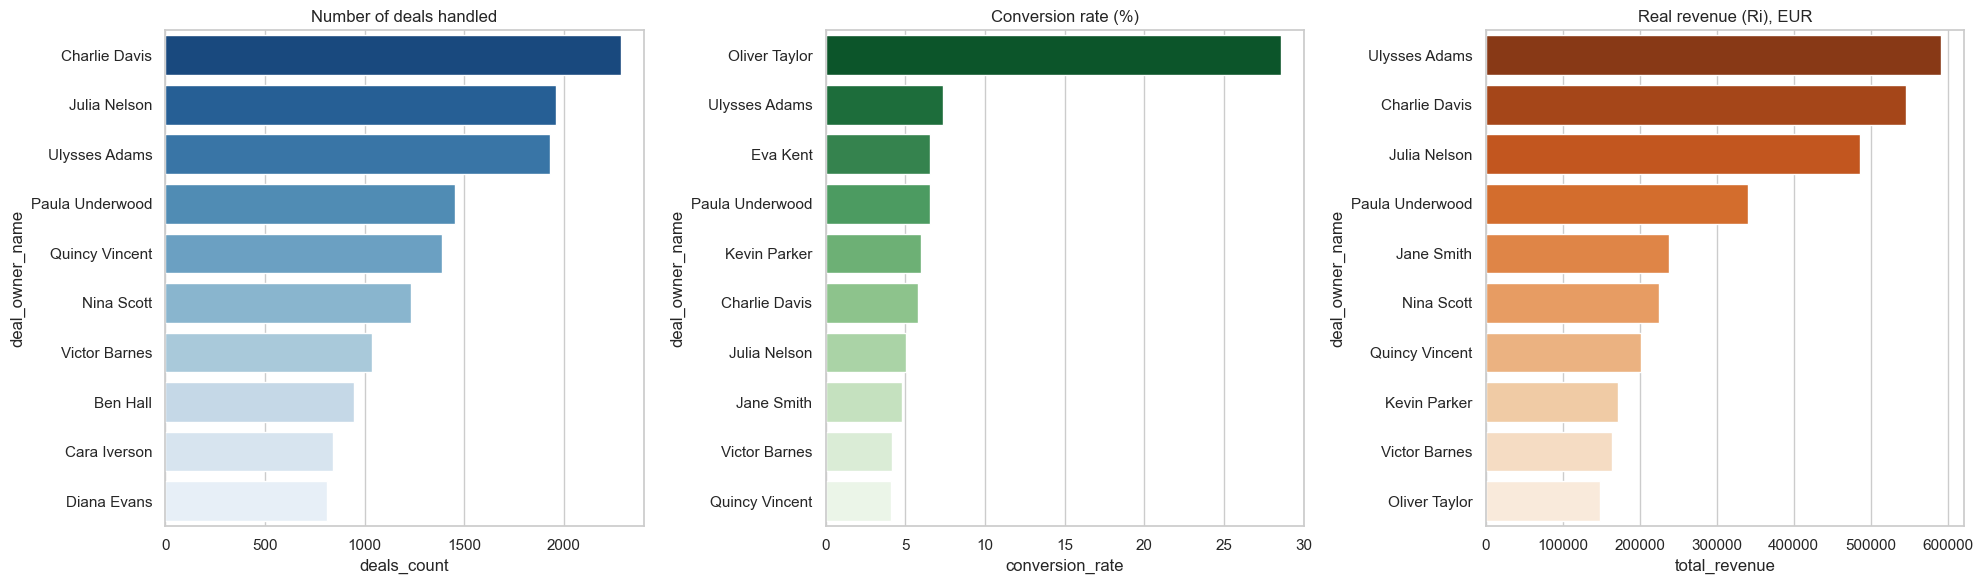

,deal_owner_name,deals_count,success_deals,total_revenue,conversion_rate
22,Ulysses Adams,1931,142.00,591316.06,7.35
5,Charlie Davis,2287,132.00,545338.48,5.77
12,Julia Nelson,1963,99.00,486654.55,5.04
17,Paula Underwood,1454,95.00,341133.79,6.53
18,Quincy Vincent,1391,57.00,201509.39,4.10
15,Nina Scott,1231,49.00,224975.76,3.98
23,Victor Barnes,1039,43.00,163784.55,4.14
10,Jane Smith,788,38.00,238223.18,4.82
2,Ben Hall,948,38.00,81924.55,4.01
4,Cara Iverson,839,26.00,48520.00,3.10


In [71]:
# 1. Per-manager metrics, taken from the unit-economics table above (same definitions, same totals)
manager_stats = manager_ue.rename(columns={
    'UA': 'deals_count',          # leads handled
    'B': 'success_deals',         # unique paying students
    'Rev': 'total_revenue',       # real revenue (Ri)
    'C1': 'conversion_rate'       # B / leads, %
})[['deal_owner_name', 'deals_count', 'success_deals', 'total_revenue', 'conversion_rate']].copy()

# Force to string so the charts don't complain about types
manager_stats['deal_owner_name'] = manager_stats['deal_owner_name'].astype(str)

# 2. Visualization (3 metrics)
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

# Top by number of deals
sns.barplot(data=manager_stats.sort_values('deals_count', ascending=False).head(10), 
            x='deals_count', y='deal_owner_name', hue='deal_owner_name', palette='Blues_r', ax=ax[0], legend=False)
ax[0].set_title('Number of deals handled')

# Top by conversion
sns.barplot(data=manager_stats.sort_values('conversion_rate', ascending=False).head(10), 
            x='conversion_rate', y='deal_owner_name', hue='deal_owner_name', palette='Greens_r', ax=ax[1], legend=False)
ax[1].set_title('Conversion rate (%)')

# Top by revenue
sns.barplot(data=manager_stats.sort_values('total_revenue', ascending=False).head(10), 
            x='total_revenue', y='deal_owner_name', hue='deal_owner_name', palette='Oranges_r', ax=ax[2], legend=False)
ax[2].set_title('Real revenue (Ri), EUR')

plt.tight_layout()
plt.show()

display(manager_stats.sort_values('success_deals', ascending=False).head(10))

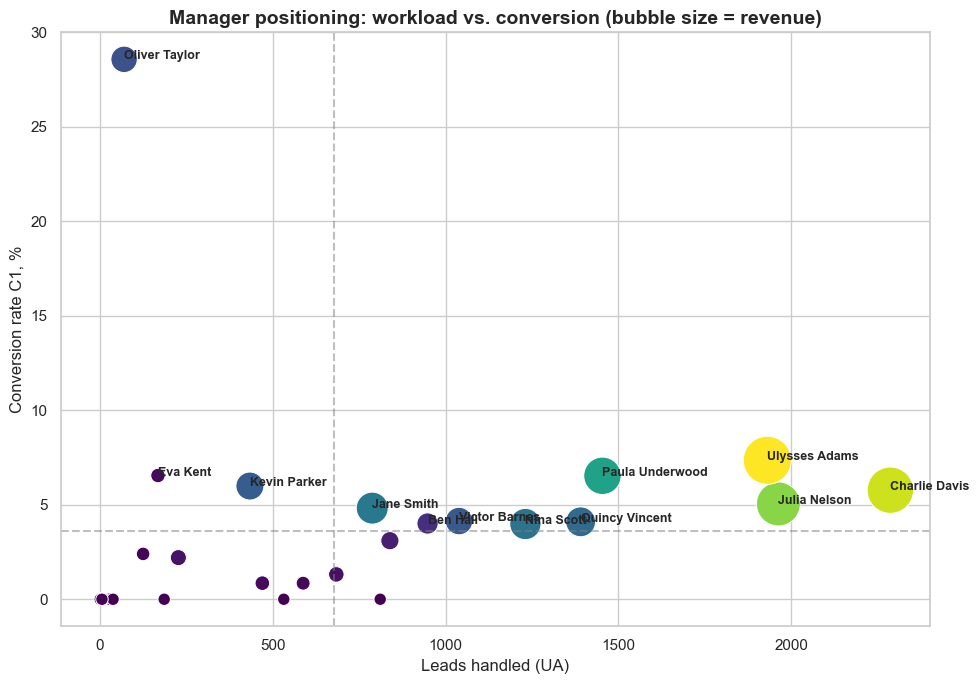

In [72]:
# --- 5.2b Manager positioning: workload vs conversion (bubble = revenue) ---
plot_df = manager_ue[manager_ue['UA'] > 0].copy()

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=plot_df, x='UA', y='C1', size='Rev', hue='Rev',
    sizes=(80, 1200), palette='viridis', legend=False
)

avg_c1 = plot_df['C1'].mean()
avg_ua = plot_df['UA'].mean()
plt.axhline(avg_c1, color='grey', linestyle='--', alpha=0.5)
plt.axvline(avg_ua, color='grey', linestyle='--', alpha=0.5)

# Label managers worth calling out: above-average conversion, or top-quintile revenue
rev_q80 = plot_df['Rev'].quantile(0.8)
for _, row in plot_df.iterrows():
    if row['C1'] > avg_c1 or row['Rev'] > rev_q80:
        plt.text(row['UA'], row['C1'], row['deal_owner_name'], fontsize=9, fontweight='bold')

plt.xlabel('Leads handled (UA)')
plt.ylabel('Conversion rate C1, %')
plt.title('Manager positioning: workload vs. conversion (bubble size = revenue)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 5.3 Analytical Conclusion


Volume trap: Leaders by deal count (Chart 1) are often not the leaders by revenue. This means they're overloaded and don't spend time carefully closing high-value tickets.

Hidden stars: Managers with high conversion (Chart 2) but low volume are a scaling opportunity - they should get more Facebook Ads leads.

Anomalies: A manager with high revenue but low conversion is likely good at selling only expensive products, while losing the mass-market segment.

**Manager efficiency** (real revenue Ri; unique paying students)

* There is a large efficiency gap between managers. The top 4 (Ulysses Adams, Charlie Davis, Julia Nelson, Paula Underwood) generate 59% of revenue (EUR 1.96M); the top 3 generate 48%.
* Best conversion at scale: Ulysses Adams, C1 about 7.4% on 1,931 leads (EUR 591K revenue); Paula Underwood, about 6.5% on 1,454 leads.
* Large flow, lower conversion: Charlie Davis about 6.0% on 2,287 leads; Quincy Vincent about 4.2% on 1,391; Nina Scott about 4.0% on 1,231.
* Anomaly to investigate: Oliver Taylor, 70 leads, 20 students, C1 28.6%, EUR 149K revenue. A small, probably hand-picked flow (referral or partnership?).
* Nine managers closed no sales, yet received 8.8% of all leads (about 1,600).

`Revenue`
* Revenue concentration is high: a small group of managers drives most of the money.
* Revenue per student and paid months per student are now available per manager (columns CLTV and APC), so the source of a manager's revenue can be separated into volume, ticket (AOV) and duration (APC).

`Limitations`
* Lead difficulty is not controlled: managers receive different campaigns and qualities.
* The incoming-flow distribution (who gets which leads) can explain part of the gap.

3. What happens if nothing changes?
About 1,600 leads (9% of the flow) keep going to managers who closed none, and top performers keep working at capacity.

4. What to do (priority, as hypotheses to test)
Today:
* Route a larger share of high-quality leads to the top 4 managers (Ulysses, Charlie, Julia, Paula)
* Investigate Oliver Taylor's lead source

Week 1:
* Re-route or auto-close low-quality leads handled by zero-sales managers
* CRM queue: prioritize top managers with SLA < 12h
* Success is measured in the experiment in notebook 03, not assumed here

---
# 6. Payment and Product Analysis

Tasks:   
`Payment and product analysis:`  
1. Study the distribution of payment types and their effect on deal success.   
2. Analyze the popularity and success of different products and education types.

### 6.1 Product & Education-Type Performance

*Analyze the popularity and success of different products and education types.*


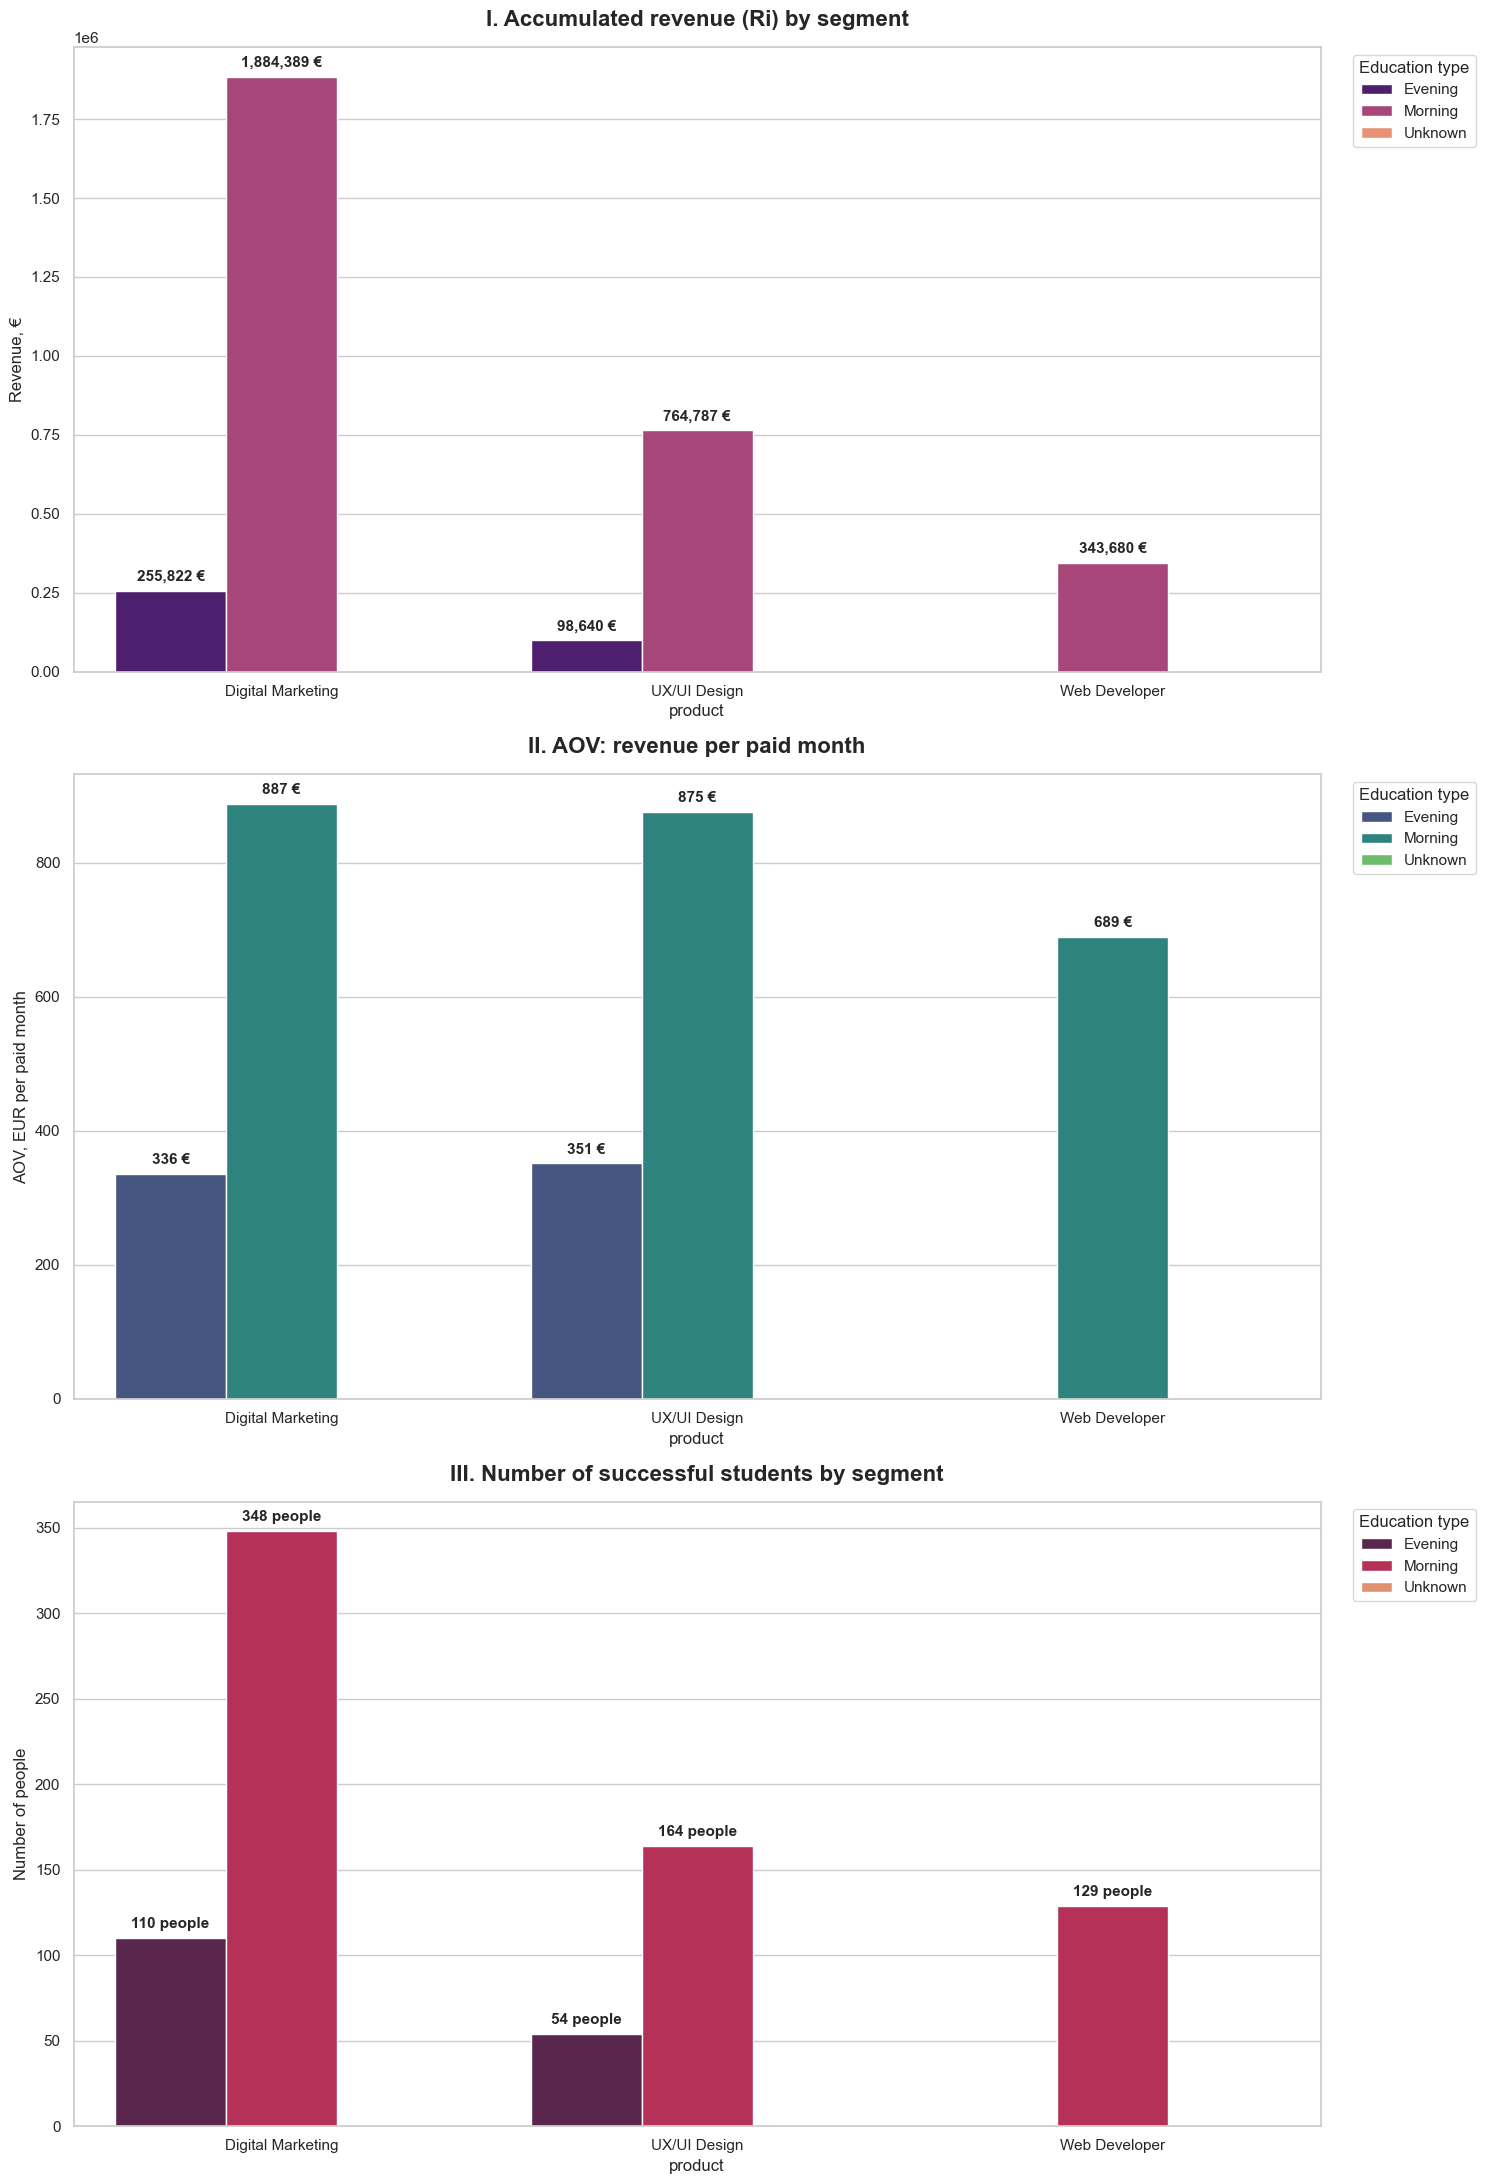

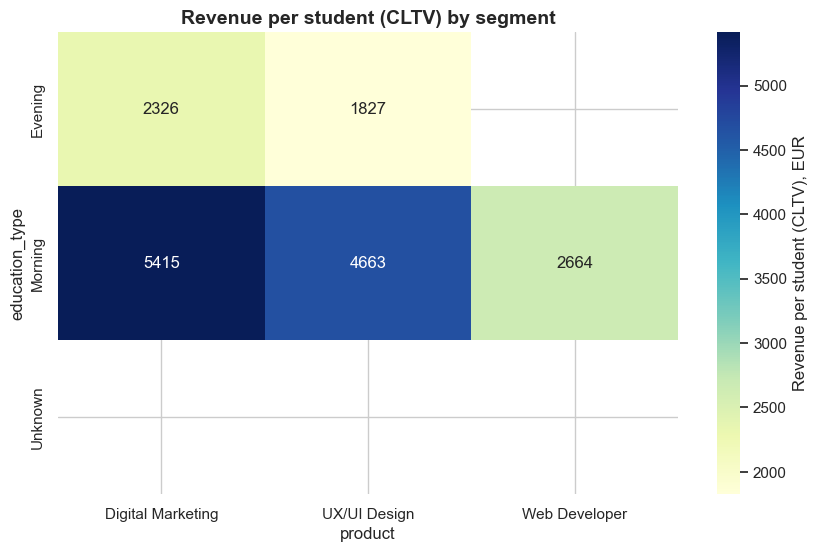

,product,education_type,Students_Count,Total_Ri,T,AOV,APC,CLTV
1,Digital Marketing,Morning,348,"1,884,389.09 €","2,124",887.19 €,6.10,"5,415 €"
0,Digital Marketing,Evening,110,"255,821.82 €",762,335.72 €,6.93,"2,326 €"
2,Digital Marketing,Unknown,0,0.00 €,0,nan €,nan,nan €
4,UX/UI Design,Morning,164,"764,787.27 €",874,875.04 €,5.33,"4,663 €"
3,UX/UI Design,Evening,54,"98,639.55 €",281,351.03 €,5.20,"1,827 €"
5,UX/UI Design,Unknown,0,0.00 €,0,nan €,nan,nan €
7,Web Developer,Morning,129,"343,680.00 €",499,688.74 €,3.87,"2,664 €"
6,Web Developer,Evening,0,0.00 €,0,nan €,nan,nan €
8,Web Developer,Unknown,0,0.00 €,0,nan €,nan,nan €


In [73]:
# --- 0. SETUP: paying students in the three target products ---
deals['is_real_student'] = deals['is_real_student'].fillna(False).astype(bool)

target_products = ['Digital Marketing', 'UX/UI Design', 'Web Developer']
students_final = deals[
    (deals['is_real_student'] == True) &
    (deals['product'].isin(target_products))
].copy()
students_final['education_type'] = students_final['education_type'].fillna('Unknown')
students_final['product'] = students_final['product'].str.strip()

# --- 1. FINAL AGGREGATION ---
# Use the already-cleaned students_final data
stats = students_final.groupby(['product', 'education_type'], observed=False).agg(
    Students_Count=('contact_id', 'nunique'),   # unique paying students
    Total_Ri=('Ri', 'sum'),
    T=('months_of_study', 'sum')              # paid months (transactions)
).reset_index().sort_values(['product', 'Total_Ri'], ascending=[True, False])

# Unit-economics columns (revenue-weighted, see glossary)
stats['AOV']  = (stats['Total_Ri'] / stats['T']).replace([np.inf, -np.inf], np.nan)               # revenue per paid month
stats['APC']  = (stats['T'] / stats['Students_Count']).replace([np.inf, -np.inf], np.nan)         # paid months per student
stats['CLTV'] = (stats['Total_Ri'] / stats['Students_Count']).replace([np.inf, -np.inf], np.nan)  # revenue per student

# --- 2. VISUALIZATION: THREE ANALYTICAL VIEWS ---
fig, ax = plt.subplots(3, 1, figsize=(15, 22))

# CHART 1: GROSS REVENUE (money volume in the system)
sns.barplot(data=stats, x='product', y='Total_Ri', hue='education_type', palette='magma', ax=ax[0])
ax[0].set_title('I. Accumulated revenue (Ri) by segment', fontsize=16, fontweight='bold', pad=15)
ax[0].set_ylabel('Revenue, €')

for p in ax[0].patches:
    if p.get_height() > 0:
        ax[0].annotate(f'{p.get_height():,.0f} €', 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), textcoords='offset points')

# CHART 2: HONEST TICKET (quality and margin per iteration)
sns.barplot(data=stats, x='product', y='AOV', hue='education_type', palette='viridis', ax=ax[1])
ax[1].set_title('II. AOV: revenue per paid month', fontsize=16, fontweight='bold', pad=15)
ax[1].set_ylabel('AOV, EUR per paid month')

for p in ax[1].patches:
    if p.get_height() > 0:
        ax[1].annotate(f'{p.get_height():,.0f} €', 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), textcoords='offset points')

# CHART 3: NUMBER OF STUDENTS (scale of operations)
sns.barplot(data=stats, x='product', y='Students_Count', hue='education_type', palette='rocket', ax=ax[2])
ax[2].set_title('III. Number of successful students by segment', fontsize=16, fontweight='bold', pad=15)
ax[2].set_ylabel('Number of people')

for p in ax[2].patches:
    if p.get_height() > 0:
        ax[2].annotate(f'{int(p.get_height())} people', 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), textcoords='offset points')

# Remove redundant legends, keep one shared legend
for axes in ax:
    axes.legend(title='Education type', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig(IMAGES / 'deep_segment_analysis_3_levels.png', bbox_inches='tight')
plt.show()

# --- 3. HEATMAP: REVENUE PER STUDENT (CLTV) BY SEGMENT ---
# A second lens on the same data: not just how much revenue a segment brings,
# but how valuable one student in that segment is.
pivot_cltv = stats.pivot(index='education_type', columns='product', values='CLTV')
pivot_cltv = pivot_cltv.astype(float)
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_cltv, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Revenue per student (CLTV), EUR'})
plt.title('Revenue per student (CLTV) by segment', fontsize=14, fontweight='bold')
plt.savefig(IMAGES / 'heatmap_cltv_segments.png', bbox_inches='tight')
plt.show()

# --- 4. FINAL TABLE (STYLED) ---
display(stats.style.background_gradient(subset=['Total_Ri'], cmap='Oranges') \
                  .background_gradient(subset=['AOV'], cmap='YlGn') \
                  .format({'Total_Ri': '{:,.2f} €', 'AOV': '{:,.2f} €', 'Students_Count': '{:,.0f}', 'T': '{:,.0f}', 'APC': '{:.2f}', 'CLTV': '{:,.0f} €'}))

### 6.2 Payment Type Distribution (Successful Deals Only)

*Study the distribution of payment types and their effect on deal success.*


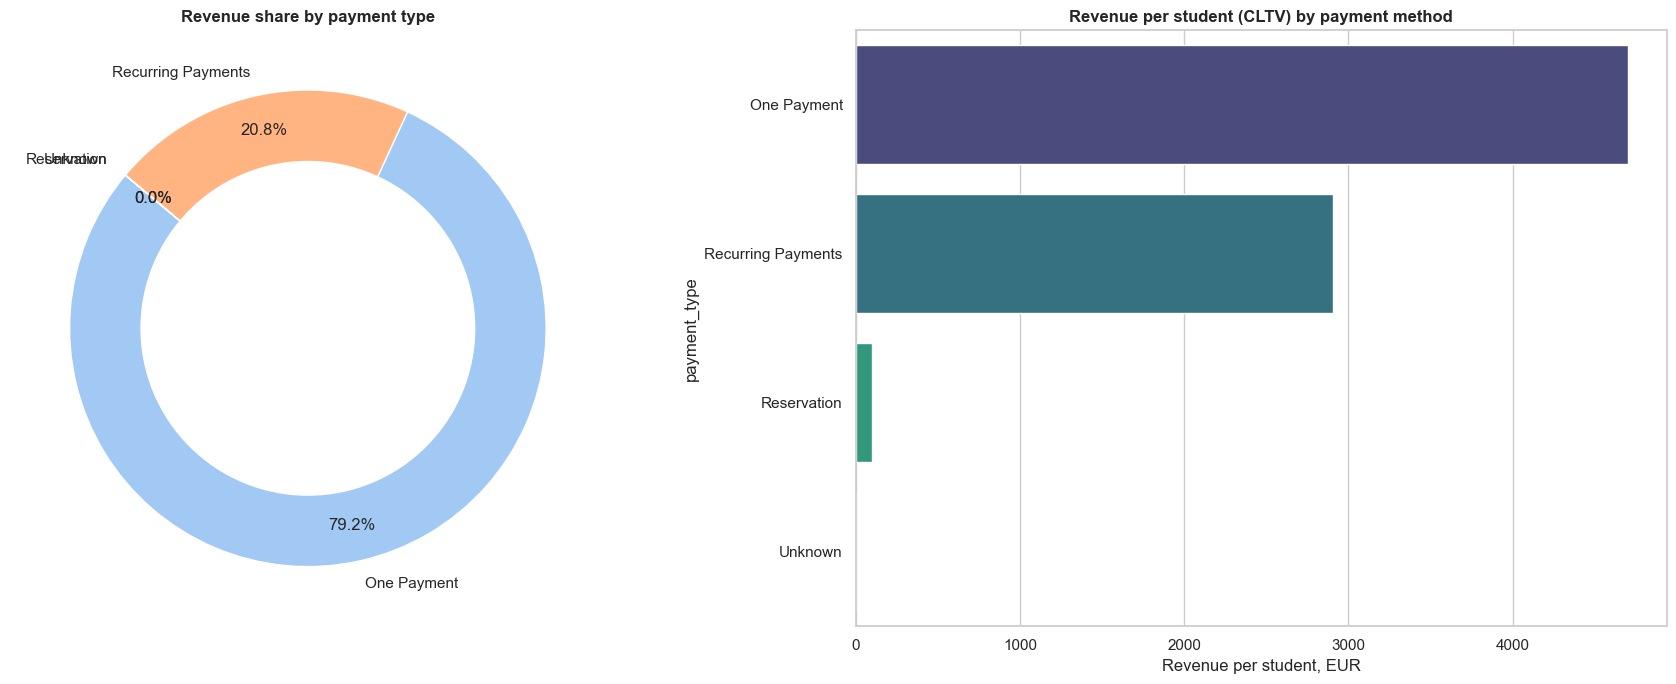

,payment_type,Students,T,REV,AOV,APC,CLTV,REV_Share %
0,One Payment,564,"3,005","2,652,575.91 €",882.72 €,5.33,"4,703.15 €",79.2%
1,Recurring Payments,239,"1,523","694,641.82 €",456.10 €,6.37,"2,906.45 €",20.8%
2,Reservation,1,1,100.00 €,100.00 €,1.00,100.00 €,0.0%
3,Unknown,1,11,0.00 €,0.00 €,11.00,0.00 €,0.0%


In [74]:
# --- 1. AGGREGATION BY PAYMENT TYPE ---
# Use real sales data (actual_sales_clean)
payment_analysis = actual_sales_clean.groupby('payment_type', observed=False).agg(
    Students=('contact_id', 'nunique'),   # unique paying students
    T=('months_of_study', 'sum'),         # paid months (transactions)
    REV=('Ri', 'sum')
).reset_index()

payment_analysis['AOV']  = payment_analysis['REV'] / payment_analysis['T']          # revenue per paid month
payment_analysis['APC']  = payment_analysis['T'] / payment_analysis['Students']     # paid months per student
payment_analysis['CLTV'] = payment_analysis['REV'] / payment_analysis['Students']   # revenue per student
payment_analysis = payment_analysis.replace([np.inf, -np.inf], np.nan)

# Calculate each method's share of total revenue
total_rev = payment_analysis['REV'].sum()
payment_analysis['REV_Share %'] = (payment_analysis['REV'] / total_rev) * 100

# --- 2. VISUALIZATION: PAYMENT STRUCTURE ---
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# Pie: revenue share by payment type
colors = sns.color_palette('pastel')[0:len(payment_analysis)]
ax[0].pie(payment_analysis['REV'], labels=payment_analysis['payment_type'], 
        autopct='%1.1f%%', startangle=140, colors=colors, pctdistance=0.85)
ax[0].set_title('Revenue share by payment type', fontweight='bold')
# Draw the center circle (donut chart)
centre_circle = plt.Circle((0,0),0.70,fc='white')
ax[0].add_artist(centre_circle)

# Bar chart: revenue per student (CLTV) by payment type
sns.barplot(data=payment_analysis.sort_values('CLTV', ascending=False), 
            x='CLTV', y='payment_type', hue='payment_type', palette='viridis', legend=False, ax=ax[1])
ax[1].set_title('Revenue per student (CLTV) by payment method', fontweight='bold')
ax[1].set_xlabel('Revenue per student, EUR')

plt.tight_layout()
plt.show()

# --- 3. FINAL TABLE ---
styled_payments = payment_analysis.sort_values('REV', ascending=False).style \
    .background_gradient(subset=['REV'], cmap='Oranges') \
    .background_gradient(subset=['AOV'], cmap='YlGn') \
    .format({
        'REV': '{:,.2f} €',
        'AOV': '{:,.2f} €',
        'APC': '{:.2f}',
        'CLTV': '{:,.2f} €',
        'T': '{:,.0f}',
        'REV_Share %': '{:.1f}%'
    })

display(styled_payments)

### 6.3 Analytical Conclusion


**Payment Types and Products**

1. What happened?
* Payment type: one-time payment covers about 70% of students and 79% of revenue (EUR 2.65M); recurring payers are about 30% of students and 21% of revenue (EUR 0.69M). A one-time payer brings about EUR 4.7K, a recurring payer about EUR 2.9K so far (instalments are still being paid, so this figure is a lower bound).
* Products: Digital Marketing brings 64% of revenue (EUR 2.14M, about 460 students), UX/UI Design 26% (EUR 0.86M, about 220), Web Developer 10% (EUR 0.34M, about 130).
* Format: the morning format brings about 89% of revenue (EUR 2.99M). An evening student brings less than half of a morning student (Digital Marketing about EUR 2.3K vs 5.4K, UX/UI about EUR 1.8K vs 4.6K); Web Developer is sold only in the morning format.
* German level: the level is filled in for only 8% of leads (1,424 of 18,250). Among them B1 dominates (960 leads, 296 paid deals). The 2.5% conversion of the "Unclear" group cannot be compared with the 20-50% of known levels: the level is usually recorded during qualification, i.e. after contact, which inflates conversion for leads with a known level.

2. Why?
* One-time payment signals higher commitment; instalments lower the entry barrier but spread revenue over time.
* Evening students pay less per student and per month, which points to a cheaper or shorter programme rather than a lower price per month alone.

3. What happens if nothing changes?
Revenue stays concentrated in one product (Digital Marketing) and one format (morning), and the German level stays unknown for 92% of leads, so lead quality cannot be assessed early.

4. What to do? (hypotheses to test)
* Make German level a mandatory field in the lead form, then re-run the level-conversion analysis without the selection bias
* Test full-payment incentives for leads that qualify for them
* Check whether evening students are capacity-limited or offer-limited before scaling the format

---
# 7. Geographic Analysis *(optional)*

Tasks:   
`Geographic analysis:`
1. Analyze the geographic distribution of deals by city.
2. Study the impact of German-language proficiency on deal success across
different cities.

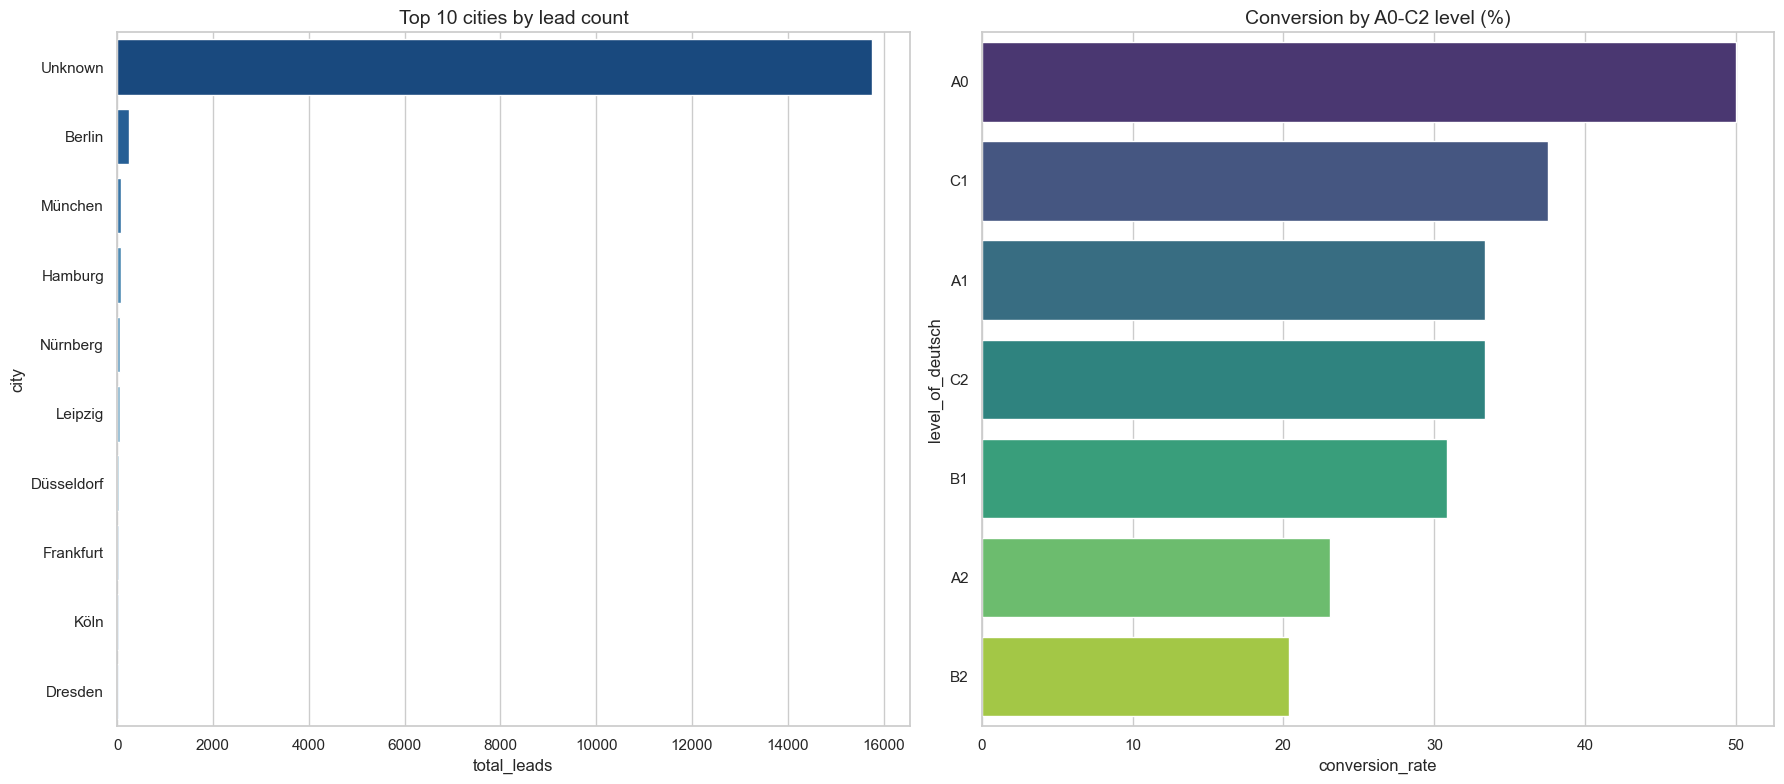

Full statistics (including Unclear):


,level_of_deutsch,total_leads,paid_deals,conversion_rate
0,A0,6,3,50.00
5,C1,32,12,37.50
6,C2,3,1,33.33
1,A1,27,9,33.33
3,B1,960,296,30.83
2,A2,195,45,23.08
4,B2,201,41,20.40
7,Unclear,16826,425,2.53


In [75]:
# # 1. Prepare city data
df = deals
city_stats = df.groupby('city', observed=True).agg(
    total_leads=('deals_id', 'count'),
    paid_deals=('is_paid', 'sum')
).reset_index()

city_top = city_stats.sort_values('total_leads', ascending=False).head(10).copy()
city_top['city'] = city_top['city'].astype(str)

# 2. Prepare language-level data (filter out the anomalous "Unclear" for the charts)
lang_stats = df.groupby('level_of_deutsch', observed=True).agg(
    total_leads=('deals_id', 'count'),
    paid_deals=('is_paid', 'sum')
).reset_index()

lang_stats['conversion_rate'] = (lang_stats['paid_deals'] / lang_stats['total_leads']) * 100
lang_stats['level_of_deutsch'] = lang_stats['level_of_deutsch'].astype(str)

# Filter for the visualization (drop Unclear to see the scale of the rest)
lang_plot_data = lang_stats[lang_stats['level_of_deutsch'] != 'Unclear'].copy()

# 3. Visualization
fig, ax = plt.subplots(1, 2, figsize=(18, 8))

# City chart (unchanged)
sns.barplot(data=city_top, x='total_leads', y='city', hue='city', palette='Blues_r', ax=ax[0], legend=False)
ax[0].set_title('Top 10 cities by lead count', fontsize=14)

# Language-level chart (A0-C2 levels only)
sns.barplot(data=lang_plot_data.sort_values('conversion_rate', ascending=False), 
            x='conversion_rate', y='level_of_deutsch', hue='level_of_deutsch', palette='viridis', ax=ax[1], legend=False)
ax[1].set_title('Conversion by A0-C2 level (%)', fontsize=14)

plt.tight_layout()
plt.show()

print("Full statistics (including Unclear):")
display(lang_stats.sort_values('conversion_rate', ascending=False))

---
# 8. Saving Results

Save results to `data/processed/`

In [76]:
# Save the updated DATASET to pkl
df = deals
dataset_path = PROCESSED / f"{'deals'}_final_ue.pkl"    
df.to_pickle(dataset_path)

print(f"Dataset saved: {dataset_path.relative_to(PROJECT_ROOT)}")
print(f"Size: {df.shape[0]:_} × {df.shape[1]}")
print(f"{'─'*60}")

print("Data successfully saved as .pkl and ready to import into Notebook 03.")

Dataset saved: data\processed\deals_final_ue.pkl
Size: 18_250 × 30
────────────────────────────────────────────────────────────
Data successfully saved as .pkl and ready to import into Notebook 03.


### Analysis Summary (Notebook 02):
1. **Marketing:** the most efficient channels (ROMI) and the acquisition cost (CPL, CAC) were identified. About 72% of leads are rated outside quality grades A-C.
2. **Sales:** the median time to payment is 17.5 days (rejections close in a median of 4.0 days). Conversion leaders among managers were identified.
3. **Quality:** about 72% of leads are off-target or unrated, which calls for revisiting ad-campaign settings.
4. **Data capture:** German level is known for only 8% of leads; 12% of revenue has no campaign attribution.

---
# 9. Conclusions

### Conclusions for the Presentation

## Key findings

**Portfolio unit economics (Jul 2023 - May 2024)**
* EUR 3.35M revenue on a EUR 138K marketing budget (ROMI about 2,320%). 17,250 potential clients become 802 paying students (C1 4.65%) at a CPA of EUR 8.01 and a CAC of EUR 172.
* A student pays for 5.7 months on average at EUR 737 per paid month: CLTV is EUR 4,174, which is 24x CAC. COGS is not available in the data, so these are revenue-based upper bounds.
* Revenue structure: Digital Marketing 64%, UX/UI Design 26%, Web Developer 10%. One-time payment is 70% of students and 79% of revenue.

**Where the funnel leaks**
1. **Lead quality.** Only 28% of leads are rated A-C. Google Ads takes 38.5% of the budget (EUR 53K) at twice Facebook's cost per lead and loses 43.6% of its deals within 3 days.
2. **Speed.** Median first response is 5.5 hours, and only 19% of closed deals were contacted within an hour. Facebook, the largest lead source, waits on average up to 38 hours.
3. **Sales team.** The top 4 managers generate 59% of revenue; 9 managers closed nothing but received 8.8% of leads.
4. **Data capture.** German level is known for only 8% of leads; 12% of revenue has no campaign attribution.

**Growth lever and next step**
C1 is the lever with the best cost-benefit: channel C1 ranges from 1.8% (CRM base) to 9.7% (Organic), and 2.9% for TikTok and improving it needs process changes rather than more ad spend. A 15% relative C1 uplift means about 120 extra students and about EUR 0.5M extra revenue at constant spend (calculation in notebook 03). Because the median payment takes 17.5 days, a 2-week test must be read on leading indicators; the design is described in notebook 03, Section 5.